# Setup

In [1]:
WANDB_PROJECT_NAME = "quantization-conv2d"

import wandb
wandb.login()

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# prompt: I want to import functions from models.py folder so that I can use them inside this notebook suggest, how should I add/modify __init__.py files, and how should I import them. I did what you suggest but I'm still unable to import them

import os
import sys


# Define the path to the root of your cloned repository in Google Drive
# IMPORTANT: Make sure this path is correct based on where you cloned the repo
repo_root = '/home/coder/project/quantization_techniques'

# Add the repository root to the Python path
if repo_root not in sys.path:
    sys.path.append(repo_root)
    print(f"Added {repo_root} to sys.path")
else:
    print(f"{repo_root} is already in sys.path")


# Now you should be able to import modules from within the 'quantization_techniques' directory
# For example, to import resnet18_cifar from the models directory within ADC:
try:
    from ADC.models import resnet18_cifar, resnet18_cifar_adc
    from ADC.quantizers import AffineQuantizerPerTensor, SymmetricQuantizerPerTensor, ADCQuantizer
    print("Successfully imported modules from ADC")
except ImportError as e:
    print(f"Import failed: {e}")
    print("Please double check the path and the structure of your repository.")
    print("Current sys.path:", sys.path)

Added /home/coder/project/quantization_techniques to sys.path


/opt/conda/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Successfully imported modules from ADC


In [4]:
from ADC.conv_experiments.conv_experiment_setup import get_config, get_exp_config, setup_dataloaders
from ADC.conv_experiments.conv_experiment import run_single_experiment
from ADC.models import resnet18_cifar, resnet18_cifar_adc
from ADC.train_utils import calibrate_model, train_model, calibrate_model3, finetune_model
from matplotlib import pyplot as plt


import torch
from tqdm import tqdm
from copy import deepcopy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [5]:
from ADC.conv_experiments.conv_experiment_setup import get_config, get_exp_config, setup_dataloaders, get_small_dataloaders
from ADC.conv_experiments.conv_experiment import run_single_experiment
from ADC.models import resnet18_cifar, resnet18_cifar_adc
from ADC.train_utils import calibrate_model, train_model, finetune_model, calibrate_model3, evaluate_model
from ADC.quantized_layers import Conv2dADC, TiledConv2dADC, LinearADC, BlockedConv2dADC
from ADC.logger import LayerwiseStatsLogger
from ADC.utils import draw_layer_stats, draw_layer_stats_y, draw_layer_stats_qat, get_stats, enable_adc, disable_adc

In [6]:
train_loader, test_loader = setup_dataloaders(256, 256)

Files already downloaded and verified
Files already downloaded and verified


In [7]:
train_loaders, test_loaders = get_small_dataloaders(256, 1024)

Files already downloaded and verified
Files already downloaded and verified


In [8]:
model = resnet18_cifar(10)
model.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'))
model = model.to(device)

In [9]:
model = torch.load('/home/coder/project/resnte18-wreshape5e-4.pth')
model = model.to(device)

In [14]:
model = resnet18_cifar(10).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1,
                      momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

#### FP train

In [7]:
wandb.init(project=WANDB_PROJECT_NAME)

In [ ]:
# results = train_model(model, optimizer, scheduler, train_loader, test_loader, criterion, device, num_epochs=200, model_name="resnte18-wreshape5e-4", calib_loader=None, lambda_kurtosis=5e-4)

No dedicated calibration loader. Calibrating on initial training batches...
Calibrating quantizers...


Calibrating:   0%|          | 0/19 [00:00<?, ?it/s]

Calibration done. Quantizer observers are now disabled.

--- Training resnte18-wreshape5e-4 ---


Validation epoch 1 / 200: 100%|██████████| 40/40 [00:02<00:00, 16.28it/s]


Epoch 1/200 => Train Loss: 1.6285, Train Acc: 41.08% | Test Loss: 1.5189, Test Acc: 44.89%


...

Validation epoch 66 / 200: 100%|██████████| 40/40 [00:02<00:00, 16.50it/s]


Epoch 66/200 => Train Loss: 0.1851, Train Acc: 94.83% | Test Loss: 0.3542, Test Acc: 88.74%


Validation epoch 67 / 200: 100%|██████████| 40/40 [00:02<00:00, 15.65it/s]


Epoch 67/200 => Train Loss: 0.1967, Train Acc: 94.38% | Test Loss: 0.3702, Test Acc: 88.51%


Training epoch 68/200:  72%|███████▏  | 141/196 [00:20<00:07,  7.14it/s]

In [16]:
torch.save(model.state_dict(), "resnet18-wreshape-5e-4-st.pth")

# Experiments 01.10

## Impl of BlockedConv2dADC

In [ ]:
batch, data = next(iter(train_loader))
batch.shape

torch.Size([256, 3, 32, 32])

## Experiments with new layer type

In [ ]:
# from ADC.ste import ste_floor, ste_round
# ste_func_global = ste_floor
# from torch import nn
# from ADC.ste import ste_floor, ste_round
# from ADC.quantizers import ADCQuantizer, LearnableQuantizerPerTensor

# class BlockedConv2dADC(nn.Conv2d):
#     def __init__(self,
#                  in_channels, 
#                  out_channels, 
#                  kernel_size, 
#                  stride=1, 
#                  padding=0, 
#                  dilation=1, 
#                  groups=1, 
#                  bias=None, 
#                  padding_mode='zeros', 
#                  device=None, 
#                  dtype=None,
#                  bx=8,
#                  bw=8,
#                  ba=8,
#                  k=4,
#                  ashift=False,
#                  logger=None,
#                  name=None,
#                  max_block=512):
#         super(BlockedConv2dADC, self).__init__(in_channels, out_channels, kernel_size, stride, padding, dilation, groups, bias, padding_mode, device, dtype)
#         if name:
#             self.name = name
#         else:
#             self.name = f"Conv2d" + str(random.randint(10 ** 5, 10**6 - 1))
#         self.bx = bx
#         self.bw = bw
#         self.ba = ba
#         self.k = k
#         #self.x_quantizer = AffineQuantizerPerTensor(bx, "histogram")
#         #self.w_quantizer = SymmetricQuantizerPerTensor(bw, "histogram")
#         self.x_quantizer = LearnableQuantizerPerTensor(self.bx, "histogram", symmetric=False)
#         self.w_quantizer = LearnableQuantizerPerTensor(self.bw, "histogram", symmetric=True)
#         self.ashift=ashift
#         self.C = 2 ** (bx - 1)
#         self.logger = logger
#         # if type(kernel_size) == int:
#         #     Mv = in_channels*(kernel_size**2)
#         # else:
#         #     Mv = in_channels*kernel_size[0]*kernel_size[1]
#         self.adc_quantizer = ADCQuantizer(M=max_block, bx=bx, bw=bw, ba=ba, k=k, info=self.name, logger=self.logger, ste_func=ste_func_global)
#         self.adc_enabled = True
#         self.max_block = max_block
    
#     def enable_adc(self):
#         self.adc_enabled = True
#     def disable_adc(self):
#         self.adc_enabled = False
    
#     def _set_quantizer_state(self, enabled: bool):
#         self.x_quantizer.enabled = enabled
#         self.w_quantizer.enabled = enabled

#     def _batched_matmul(self, x, w, w_orig):
#         # x (N, L, K*K*C)
#         # w (K*K*C, O)
#         # Split x, w into several matrices along dimension L
#         Lmax = x.shape[-1]
#         while (Lmax > self.max_block):
#             assert Lmax % 2 == 0
#             Lmax //= 2
#         if (self.ashift):
#             x = x - self.C
#         x_splits = torch.split(x, Lmax, dim=-1)
#         w_splits = torch.split(w, Lmax, dim=0)
#         w_orig_splits = torch.split(w_orig, Lmax, dim=0)
#         assert len(x_splits) == len(w_splits)
#         y_for_adc = [x_splits[i] @ w_splits[i] for i in range(len(x_splits))]
#         # ADC quantizers are different
#         yq_adc = [self.adc_quantizer(y) for y in y_for_adc]
#         if (self.logger and self.logger.enabled):
#             self.logger.log_data(self, [y_for_adc, yq_adc], ["y_for_adc", "yq_adc"])
#         out = [self.dequantize(yq_adc[i], w_splits[i], w_orig_splits[i]) for i in range(len(yq_adc))] # (N, O)_i
#         return sum(out)

#     def _unfold_conv(self, w, input):
#         H_in = input.shape[-2]
#         W_in = input.shape[-1]

#         inp_unf = torch.nn.functional.unfold(input, kernel_size = self.kernel_size, stride = self.stride, dilation=self.dilation, padding=self.padding) # N, K * K, L
#         inp_unf = inp_unf.transpose(1, 2) # N, L, K * K * IN
#         w = w.view(w.size(0), -1).t() # K * K * IN, O
#         w_orig = self.weight.view(self.weight.size(0), -1).t()
        
#         #out_unf = inp_unf @ w # N, L, O
#         #print("Internal dims:", inp_unf.shape, w.shape)
#         out_unf = self._batched_matmul(inp_unf, w, w_orig)
        
#         out_unf = out_unf.transpose(1, 2) # N, O, L
#         H_out = ((H_in + 2*self.padding[0] - self.dilation[0] * (self.kernel_size[0] - 1) - 1) // self.stride[0]) + 1
#         W_out = ((W_in + 2*self.padding[1] - self.dilation[1] * (self.kernel_size[1] - 1) - 1) // self.stride[1]) + 1 
#         out = out_unf.view(out_unf.shape[0], out_unf.shape[1], H_out, W_out)
    
#         return out 

#     def dequantize(self, yq, wq, w_orig):
#         # yq: out x H_out x W_out
#         # self.weight: out x in x H_out x W_out
        
#         # Important!!!!!!!
#         y = yq * self.adc_quantizer.delta
#         if (self.ashift):
#             y = y + self.C * wq.sum(0)
#             #y = y + self.C * self.x_quantizer.scale * self.w_quantizer.scale * wq.sum(axis=0)
#         #print(y.shape, w_orig.shape)
#         #print(w_orig.sum(axis=-1).shape)
#         #out = y - self.x_quantizer.zero_point / self.w_quantizer.scale * w_orig.sum(axis=0)
#         out = y - self.x_quantizer.zero_point * wq.sum(axis=0)
#         out = out * self.x_quantizer.scale * self.w_quantizer.scale
#         return out
    
#     def train(self, mode=True):
#         super().train(mode)
#         #if (mode == True):
#         #    self.x_quantizer.enable()
#         #    self.w_quantizer.enable()
#         #else:
#         #    self.x_quantizer.disable()
#         #    self.w_quantizer.disable()
#         return self
#     def eval(self, mode=True):
#         super().eval(mode)
#         self.train(not mode)
#         return self
#     def forward(self, x):
#         #print("Layer input sizes:", x.shape, self.weight.shape)
#         # print(self.adc_enabled)
#         if (not self.adc_enabled):
#             xq = self.x_quantizer.fake_quantize(x)
#             wq = self.w_quantizer.fake_quantize(self.weight)
#             out = torch.nn.functional.conv2d(xq, 
#                                                wq, 
#                                                bias=self.bias, 
#                                                stride=self.stride, 
#                                                padding=self.padding, 
#                                                dilation=self.dilation, 
#                                                groups=self.groups)
#             if (self.logger and self.logger.enabled):
#                 with torch.no_grad():
#                     out_gth = torch.nn.functional.conv2d(x, 
#                                                 self.weight, 
#                                                 bias=self.bias, 
#                                                 stride=self.stride, 
#                                                 padding=self.padding, 
#                                                 dilation=self.dilation, 
#                                                 groups=self.groups)
#                 self.logger.log_data(self, [x, self.weight, xq, wq, out, out_gth], ["x", "w", "xq", "wq", "out", "out_gth"])
#             return out
        
#         xq = self.x_quantizer(x)
#         #if (self.ashift):
#         #    xq = xq - self.C
#         wq = self.w_quantizer(self.weight)

#         out = self._unfold_conv(wq, xq)

#         if self.bias is not None:
#             out += self.bias

#         if self.logger and self.logger.enabled:
#             with torch.no_grad():
#                 out_gth = torch.nn.functional.conv2d(x, 
#                                                self.weight, 
#                                                bias=self.bias, 
#                                                stride=self.stride, 
#                                                padding=self.padding, 
#                                                dilation=self.dilation, 
#                                                groups=self.groups)
#             self.logger.log_data(self, [x, self.weight, xq, wq, out, out_gth], ["x", "w", "xq", "wq", "out", "out_gth"])
#             self.logger.log_string(self.name, 'delta', self.adc_quantizer.delta)
           

#         return out

In [10]:
def evaluate_blocked_model(k_range, ashift=False, calib_portion=0.2, wreshape = False):
    scores = []
    for k in k_range:
        model_adc = resnet18_cifar_adc(10, 4, 4, 8, k, ashift=ashift, logger=None, conv_type=BlockedConv2dADC)
        if (wreshape):
            model_adc.load_state_dict(torch.load('/home/coder/project/resnet18-wreshape-5e-4-st.pth'), strict=False)
        else:
            model_adc.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'), strict=False)
        model_adc = model_adc.to(device)
        calibrate_model(model_adc, train_loader, device, calib_portion)
        score = evaluate_model(model_adc, test_loader)
        scores.append((k, score[0], score[1]))
        print(k, score)
    return scores

In [11]:
def evaluate_blocked_model_wreshape(k_range, ashift=False, calib_portion=0.2):
    scores = []
    for k in k_range:
        model_adc = resnet18_cifar_adc(10, 4, 4, 8, k, ashift=ashift, logger=None, conv_type=BlockedConv2dADC)
        model_adc.load_state_dict(torch.load('/home/coder/project/resnet18-wreshape-5e-4-st.pth'), strict=False)
        model_adc = model_adc.to(device)
        calibrate_model(model_adc, train_loader, device, calib_portion)
        score = evaluate_model(model_adc, test_loader)
        scores.append((k, score[0], score[1]))
        print(k, score)
    return scores

In [12]:
def collect_all_results(k_range, calib_portion=0.2):
    results_all = dict()
    
    ste_funcs = [ste_floor, ste_round]
    names = ["floor", "round"]
    for i in range(2):
        ste_func_global = ste_funcs[i]
        for wreshape in [False, True]:
            for ashift in [False, True]:
                res = evaluate_blocked_model(k_range, ashift=ashift, calib_portion=calib_portion, wreshape = wreshape)
                results_all["histogram_" + names[i] + "_" + str(ashift).lower() + "_" + str(wreshape).lower()] = res

    ste_func_global = ste_floor
    return results_all


### Results with MinMaxObserver

In [ ]:
# observer_stefunc_ashift
results_minmax_floor_false = evaluate_blocked_model([4, 8, 16, 32, 64, 128], False, 0.1)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.45it/s]


4 (37.32, 2.167902501678467)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.46it/s]


64 (88.98, 0.37278770866394045)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.48it/s]

128 (90.78, 0.33621842727661133)


In [ ]:
print(results_minmax_floor_false)
results["minmax_floor_false"] = results_minmax_floor_false
#[(4, 37.32, 2.167902501678467), (8, 46.02, 1.7911141597747802), (16, 57.91, 1.4236373888015748), (32, 79.6, 0.6726628245353699), (64, 88.98, 0.37278770866394045), (128, 90.78, 0.33621842727661133)]

[(4, 37.32, 2.167902501678467), (8, 46.02, 1.7911141597747802), (16, 57.91, 1.4236373888015748), (32, 79.6, 0.6726628245353699), (64, 88.98, 0.37278770866394045), (128, 90.78, 0.33621842727661133)]


In [ ]:
results_minmax_floor_true = evaluate_blocked_model([4, 8, 16, 32, 64, 128], True, 0.1)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.10it/s]


4 (10.0, 4.1695250885009765)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.96it/s]


64 (14.09, 2.3171035011291505)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.12it/s]

128 (10.0, 3.976786346435547)


In [ ]:
print(results_minmax_floor_true)
results["minmax_floor_true"] = results_minmax_floor_true
[(4, 10.0, 4.1695250885009765), (8, 10.02, 2.30267131652832), (16, 10.82, 2.3832887901306155), (32, 26.62, 2.193432038497925), (64, 14.09, 2.3171035011291505), (128, 10.0, 3.976786346435547)]

[(4, 10.0, 4.1695250885009765), (8, 10.02, 2.30267131652832), (16, 10.82, 2.3832887901306155), (32, 26.62, 2.193432038497925), (64, 14.09, 2.3171035011291505), (128, 10.0, 3.976786346435547)]


[(4, 10.0, 4.1695250885009765),
 (8, 10.02, 2.30267131652832),
 (16, 10.82, 2.3832887901306155),
 (32, 26.62, 2.193432038497925),
 (64, 14.09, 2.3171035011291505),
 (128, 10.0, 3.976786346435547)]

In [ ]:
results_minmax_round_false = evaluate_blocked_model([4, 8, 16, 32, 64, 128], False, 0.1)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.56it/s]


4 (10.0, 2.314766011428833)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.51it/s]


64 (91.73, 0.27317153768539426)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.54it/s]

128 (92.86, 0.2560570334911346)


In [ ]:
print(results_minmax_round_false)
results["minmax_round_false"] = results_minmax_round_false
#[(4, 10.0, 2.314766011428833), (8, 10.0, 2.3147063262939453), (16, 10.0, 2.31634475402832), (32, 59.72, 1.4846537620544433), (64, 91.73, 0.27317153768539426), (128, 92.86, 0.2560570334911346)]

[(4, 10.0, 2.314766011428833), (8, 10.0, 2.3147063262939453), (16, 10.0, 2.31634475402832), (32, 59.72, 1.4846537620544433), (64, 91.73, 0.27317153768539426), (128, 92.86, 0.2560570334911346)]


In [ ]:
results_minmax_round_true = evaluate_blocked_model([4, 8, 16, 32, 64, 128], True, 0.1)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.18it/s]


4 (10.26, 9.39694319152832)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.11it/s]


64 (13.82, 2.5046611103057863)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.07it/s]

128 (10.0, 4.944145703125)


In [ ]:
print(results_minmax_round_true)
results["minmax_round_true"] = results_minmax_round_true
#[(4, 10.26, 9.39694319152832), (8, 10.24, 9.14949779815674), (16, 10.18, 4.042020587921143), (32, 88.79, 0.3611047799348831), (64, 13.82, 2.5046611103057863), (128, 10.0, 4.944145703125)]

[(4, 10.26, 9.39694319152832), (8, 10.24, 9.14949779815674), (16, 10.18, 4.042020587921143), (32, 88.79, 0.3611047799348831), (64, 13.82, 2.5046611103057863), (128, 10.0, 4.944145703125)]


### Results with AvgMinMaxObserver

In [ ]:
results_avgminmax_floor_false = evaluate_blocked_model([4, 8, 16, 32, 64, 128], False, 0.1)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.61it/s]


4 (42.55, 1.9407045392990112)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.61it/s]


64 (92.09, 0.2836606650352478)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.59it/s]

128 (93.62, 0.23574767117500306)


In [ ]:
print(results_avgminmax_floor_false)
results["avgminmax_floor_false"] = results_avgminmax_floor_false
# [(4, 42.55, 1.9407045392990112), (8, 59.23, 1.3392830827713014), (16, 75.51, 0.8215977746963501), (32, 86.57, 0.4523509640693665), (64, 92.09, 0.2836606650352478), (128, 93.62, 0.23574767117500306)]

[(4, 42.55, 1.9407045392990112), (8, 59.23, 1.3392830827713014), (16, 75.51, 0.8215977746963501), (32, 86.57, 0.4523509640693665), (64, 92.09, 0.2836606650352478), (128, 93.62, 0.23574767117500306)]


In [ ]:
results = dict()

In [ ]:
results["avgminmax_floor_true"] = evaluate_blocked_model([4, 8, 16, 32, 64, 128], True, 0.1)
print(results["avgminmax_floor_true"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.10it/s]


4 (10.0, 2.302666500854492)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.14it/s]


64 (19.43, 2.244039645385742)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.03it/s]

128 (10.0, 3.6551679885864257)
[(4, 10.0, 2.302666500854492), (8, 10.0, 2.305329191207886), (16, 21.04, 2.275770207977295), (32, 80.88, 0.5968161175727844), (64, 19.43, 2.244039645385742), (128, 10.0, 3.6551679885864257)]


In [ ]:
results["avgminmax_round_false"] = evaluate_blocked_model([4, 8, 16, 32, 64, 128], False, 0.1)
print(results["avgminmax_round_false"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.58it/s]


4 (10.0, 2.671269595336914)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.47it/s]


64 (93.26, 0.23033660068511963)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.56it/s]

128 (93.48, 0.23168373885154725)
[(4, 10.0, 2.671269595336914), (8, 10.0, 2.3158478214263916), (16, 10.12, 2.3051366283416748), (32, 90.98, 0.318992915725708), (64, 93.26, 0.23033660068511963), (128, 93.48, 0.23168373885154725)]


In [ ]:
results["avgminmax_round_true"] = evaluate_blocked_model([4, 8, 16, 32, 64, 128], True, 0.1)
print(results["avgminmax_round_true"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.03it/s]


4 (9.87, 5.549743700408936)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.08it/s]


64 (38.83, 1.7602697618484497)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.01it/s]

128 (10.0, 3.6474452072143553)
[(4, 9.87, 5.549743700408936), (8, 10.28, 2.934787877655029), (16, 83.06, 0.5430991883277894), (32, 92.19, 0.2643424764633179), (64, 38.83, 1.7602697618484497), (128, 10.0, 3.6474452072143553)]


### Results with HistogramObserver

In [29]:
results = dict()

In [ ]:
results["histogram_floor_false"] = evaluate_blocked_model([4, 8, 16, 32, 64, 128], False, 0.1)
print(results["histogram_floor_false"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.59it/s]


4 (47.51, 1.8646093971252442)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.55it/s]


64 (94.08, 0.22352155470848084)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.55it/s]

128 (94.53, 0.20911898589134217)
[(4, 47.51, 1.8646093971252442), (8, 71.77, 0.9703622127532959), (16, 87.02, 0.44334708919525145), (32, 93.16, 0.25486400203704834), (64, 94.08, 0.22352155470848084), (128, 94.53, 0.20911898589134217)]


In [30]:
results["histogram_floor_false"] = [(4, 47.51, 1.8646093971252442), (8, 71.77, 0.9703622127532959), (16, 87.02, 0.44334708919525145), (32, 93.16, 0.25486400203704834), (64, 94.08, 0.22352155470848084), (128, 94.53, 0.20911898589134217)]


In [ ]:
results["histogram_floor_true"] = evaluate_blocked_model([4, 8, 16, 32, 64, 128], True, 0.1)
print(results["histogram_floor_true"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.08it/s]


4 (10.0, 4.648111366271973)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.99it/s]


64 (18.97, 2.483256558227539)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.04it/s]

128 (10.0, 3.626587253570557)
[(4, 10.0, 4.648111366271973), (8, 10.0, 5.694905455780029), (16, 72.69, 0.8561849130630493), (32, 91.56, 0.28086743302345274), (64, 18.97, 2.483256558227539), (128, 10.0, 3.626587253570557)]


In [31]:
results["histogram_floor_true"] = [(4, 10.0, 4.648111366271973), (8, 10.0, 5.694905455780029), (16, 72.69, 0.8561849130630493), (32, 91.56, 0.28086743302345274), (64, 18.97, 2.483256558227539), (128, 10.0, 3.626587253570557)]

In [ ]:
results["histogram_round_false"] = evaluate_blocked_model([4, 8, 16, 32, 64, 128], False, 0.1)
print(results["histogram_round_false"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.50it/s]


4 (10.0, 2.316229627609253)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.61it/s]


64 (94.08, 0.22577042264938355)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.60it/s]

128 (94.15, 0.2112402346134186)
[(4, 10.0, 2.316229627609253), (8, 9.91, 2.32699284362793), (16, 90.49, 0.31337875862121584), (32, 93.83, 0.23497552132606506), (64, 94.08, 0.22577042264938355), (128, 94.15, 0.2112402346134186)]


In [32]:
results["histogram_round_false"] = [(4, 10.0, 2.316229627609253), (8, 9.91, 2.32699284362793), (16, 90.49, 0.31337875862121584), (32, 93.83, 0.23497552132606506), (64, 94.08, 0.22577042264938355), (128, 94.15, 0.2112402346134186)]


In [ ]:
results["histogram_round_true"] = evaluate_blocked_model([4, 8, 16, 32, 64, 128], True, 0.1)
print(results["histogram_round_true"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.07it/s]


4 (10.1, 3.812465043258667)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.11it/s]


64 (23.92, 2.996702857208252)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.13it/s]

128 (10.0, 3.3536945152282716)
[(4, 10.1, 3.812465043258667), (8, 34.77, 2.2465785572052), (16, 91.23, 0.3008088404655457), (32, 93.91, 0.22792188287973403), (64, 23.92, 2.996702857208252), (128, 10.0, 3.3536945152282716)]


In [33]:
results["histogram_round_true"] = [(4, 10.1, 3.812465043258667), (8, 34.77, 2.2465785572052), (16, 91.23, 0.3008088404655457), (32, 93.91, 0.22792188287973403), (64, 23.92, 2.996702857208252), (128, 10.0, 3.3536945152282716)]


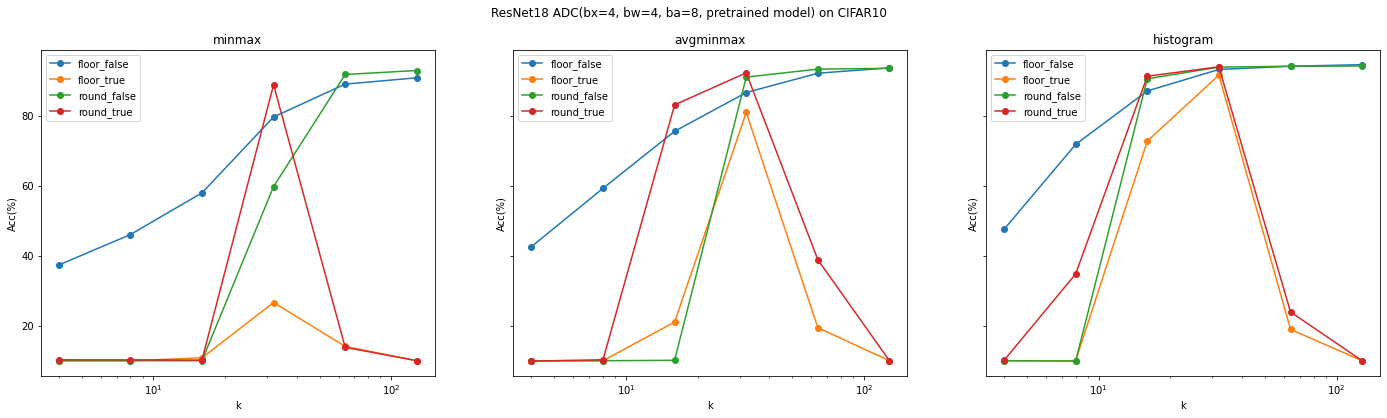

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
k_range = [4, 8, 16, 32, 64, 128]


observers = ["minmax", "avgminmax", "histogram"]
ste_op = ["floor", "round"]
ashift = ["false", "true"]

for i in range(3):
    for j in range(2):
        for ij in range(2):
            suf = f"{ste_op[j]}_{ashift[ij]}"
            name = f"{observers[i]}_" + suf

            ax[i].plot(k_range, [t[1] for t in results[name]], label=suf, marker='o')
    ax[i].legend()
    ax[i].set_xscale('log')
    ax[i].set_title(observers[i])
    ax[i].set_xlabel('k')
    ax[i].set_ylabel('Acc(%)')
fig.suptitle('ResNet18 ADC(bx=4, bw=4, ba=8, pretrained model) on CIFAR10')
plt.show()

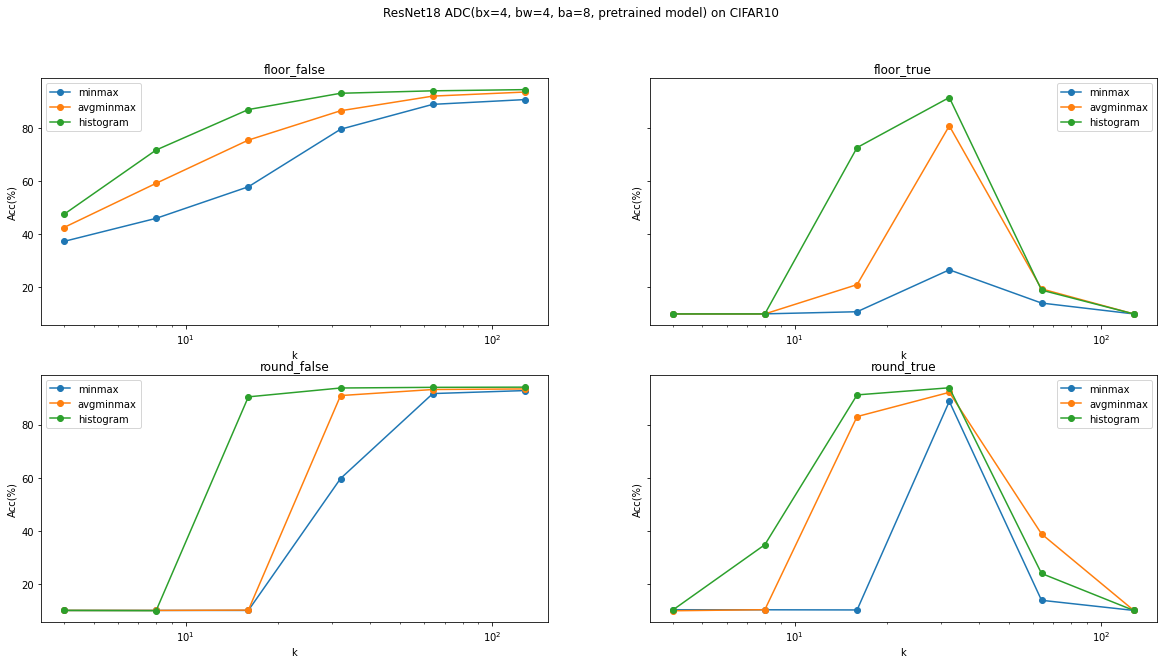

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(20, 10), sharey=True)
k_range = [4, 8, 16, 32, 64, 128]


observers = ["minmax", "avgminmax", "histogram"]
ste_op = ["floor", "round"]
ashift = ["false", "true"]

for j in range(2):
    for ij in range(2):
        suf = f"{ste_op[j]}_{ashift[ij]}"
        for i in range(3):
            name = f"{observers[i]}_" + suf

            ax[j][ij].plot(k_range, [t[1] for t in results[name]], label=observers[i], marker='o')
        ax[j][ij].legend()
        ax[j][ij].set_xscale('log')
        ax[j][ij].set_title(suf)
        ax[j][ij].set_xlabel('k')
        ax[j][ij].set_ylabel('Acc(%)')
fig.suptitle('ResNet18 ADC(bx=4, bw=4, ba=8, pretrained model) on CIFAR10')
plt.show()

In [ ]:
import pickle
with open("results_cifar10_ptq_adc_101025.pkl", "wb") as f:  # 'wb' = write binary
    pickle.dump(results, f)

In [ ]:
from ADC.logger import LayerwiseStatsLogger
logger = LayerwiseStatsLogger()
logger.enabled = False
model_adc1 = resnet18_cifar_adc(10, 4, 4, 8, 128, True, logger, BlockedConv2dADC)
#load_tiled_model_weights(model_adc1, model)
model_adc1.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'), strict=False)
model_adc1 = model_adc1.to(device)
#model_adc1.enable_adc()
calibrate_model(model_adc1, train_loader, device, 0.1)
evaluate_model(model_adc1, test_loader)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:09<00:00,  4.29it/s]


(10.0, 3.3527067462921143)

In [ ]:
def calibrate_model2(model, calib_loader, device, portion=0.1, reset=True):
    model.train()  # Enable train mode so observers collect stats
    print("Calibrating quantizers...")

    # Enable all relevant quantizers for calibration
    for _, module in model.named_modules():
        if hasattr(module, '_set_quantizer_state'):  # For LinearADC, LinearQuant
            module.x_quantizer.observer.reset()
            module.w_quantizer.observer.reset()
            module._set_quantizer_state(enabled=True)
        elif hasattr(module, 'enable'):  # Standalone quantizers
            module.enable()

    # Determine how many batches to use based on portion
    total_batches = len(calib_loader)
    num_batches = max(1, int(total_batches * portion))

    with torch.no_grad():  # No gradients needed
        for i, (inputs, _) in tqdm(
            enumerate(calib_loader), 
            total=num_batches, 
            desc="Calibrating", 
            leave=False
        ):
            inputs = inputs.to(device)
            model(inputs)  # Forward pass to update observers
            if i + 1 >= num_batches:
                break

    # After calibration, freeze quantizer parameters
    for _, module in model.named_modules():
        if hasattr(module, '_set_quantizer_state'):
            module._set_quantizer_state(enabled=False)
        elif hasattr(module, 'disable'):
            module.disable()

    print("Calibration done. Quantizer observers are now disabled.")
    model.eval()

### Technical plots

In [ ]:
batch, data = next(iter(train_loader))
batch = batch.to(device)

In [54]:
from torch import nn
def load_tiled_model_weights(custom_model, pretrained_model):
    """
    Loads weights from a pretrained model with nn.Conv2d layers into
    a custom model with TiledConv2dADC layers.
    """
    pretrained_modules = dict(pretrained_model.named_modules())
    custom_modules = dict(custom_model.named_modules())

    for name, custom_module in custom_modules.items():
        if name in pretrained_modules:
            pretrained_module = pretrained_modules[name]

            # Case 1: Custom has TiledConv2dADC and pretrained has Conv2d
            if isinstance(custom_module, TiledConv2dADC) and isinstance(pretrained_module, nn.Conv2d):
                #print(f"[TILED] Loading Conv2d → TiledConv2dADC for layer: {name}")
                custom_module.load_weights(pretrained_module)

            # Case 2: They are of the same type → copy state_dict directly
            elif type(custom_module) == type(pretrained_module) or isinstance(custom_module, Conv2dADC) or isinstance(custom_module, LinearADC):
                try:
                    custom_module.load_state_dict(pretrained_module.state_dict(), strict=False)
                    #print(f"[DEFAULT] Loaded state_dict for: {name}")
                except RuntimeError as e:
                    print(f"[WARNING] Skipped {name} due to mismatch: {e}")

In [ ]:
from ADC.logger import LayerwiseStatsLogger

model_adc2 = resnet18_cifar_adc(10, 4, 4, 8, 4, True, None, TiledConv2dADC)
load_tiled_model_weights(model_adc2, model)
model_adc2 = model_adc2.to(device)
#model_adc2.enable_adc()
calibrate_model(model_adc2, train_loader, device, 0.4)
evaluate_model(model_adc2, test_loader)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:16<00:00,  2.50it/s]


(52.9, 1.4239948600769043)

In [ ]:
model_qat = resnet18_cifar_adc(10, 4, 4, 8, k=8, ashift=False, logger=None, conv_type=BlockedConv2dADC)
model_qat.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'), strict=False)
model_qat = model_qat.to(device)
#model_qat.disable_adc()
calibrate_model(model_qat, train_loader, device, 0.1)
evaluate_model(model_qat, test_loader)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.56it/s]


(71.97, 0.9544408885002136)

In [ ]:
def get_stats(model):
    model.logger.enabled = True
    batch, labels = next(iter(test_loader))
    batch = batch.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        res = model(batch)
    model.logger.enabled = True
    return model.logger.get_stats()

In [ ]:
stats2 = get_stats(model_adc1)

In [ ]:
stats = get_stats(model_adc1)

In [ ]:
def draw_layer_stats(stats, layer_name, batch_size=1):
    fig, ax = plt.subplots(2, 4, figsize=(20, 10))
    
    data = stats[layer_name]

    #names = [["w", "x", "y_for_adc", "out_gth"], ["wq", "xq", "yq_adc", "out"]]
    names = [["w", "x", "y_for_adc", "out_gth"], ["wq", "xq", 'yq_adc', "out"]]
    delta = data['delta'][0]
    delta2 = delta * (2 ** 7 - 1)
    for i in range(2):
        for j in range(4):
            #print(names[i][j])
            samples = data[names[i][j]][0]
            if names[i][j][0] != 'w':
                samples = samples[:batch_size]
            samples = samples.flatten()
            height = ax[i][j].hist(samples, bins=50)[0].max()
            ax[i][j].set_title(names[i][j] + (" (for one block)" if names[i][j][0] == 'y' else ""))
            if (names[i][j] == 'y_for_adc'):
                ax[i][j].plot([-delta, -delta], [0, height], color='r', linestyle='--')
                ax[i][j].plot([delta, delta], [0, height], color='r', linestyle='--')
                ax[i][j].plot([-delta2, -delta2], [0, height], color='g', linestyle='--')
                ax[i][j].plot([delta2, delta2], [0, height], color='g', linestyle='--')
    fig.suptitle(layer_name)

def draw_layer_stats_y(stats, layer_name, batch_size=1):
    
    data = stats[layer_name]

    num_blocks = len(data['y_for_adc'])
    fig, ax = plt.subplots(2, max(2, num_blocks), figsize=(5 * max(2, num_blocks), 10))

    names = ['y_for_adc', 'yq_adc']
    for i in range(2):
        for j in range(num_blocks):
            #print(names[i][j])
            samples = data[names[i]][j][:batch_size]
            samples = samples.flatten()
            ax[i][j].hist(samples, bins=50)
            ax[i][j].set_title(names[i] + f' block {j + 1}/{num_blocks}')
    fig.suptitle(layer_name)

In [ ]:
for name in stats:
    print(name, torch.norm(stats[name]['out'][0] - stats[name]['out_gth'][0]) / torch.norm(stats[name]['out_gth'][0]))

layer1_block0_conv1 tensor(6.9193)
layer1_block0_conv2 tensor(4.3555)
layer1_block1_conv1 tensor(3.2280)
layer1_block1_conv2 tensor(4.3217)
layer2_block0_conv1 tensor(2.2018)
layer2_block0_conv2 tensor(3.8434)
layer2_downsample_conv tensor(9.4116)
layer2_block1_conv1 tensor(6.2389)
layer2_block1_conv2 tensor(4.4510)
layer3_block0_conv1 tensor(8.9115)
layer3_block0_conv2 tensor(5.9692)
layer3_downsample_conv tensor(14.0893)
layer3_block1_conv1 tensor(7.6999)
layer3_block1_conv2 tensor(13.2054)
layer4_block0_conv1 tensor(12.7840)
layer4_block0_conv2 tensor(11.6756)
layer4_downsample_conv tensor(6.9414)
layer4_block1_conv1 tensor(14.6425)
layer4_block1_conv2 tensor(7.7098)


In [ ]:
model_adc1.layer1[0].conv1.w_quantizer.observer.calculate_qparams()

(tensor([0.0418], device='cuda:0'), tensor([0], device='cuda:0'))

In [ ]:
stats2['layer2_block1_conv1']['delta'][0]

3.28125

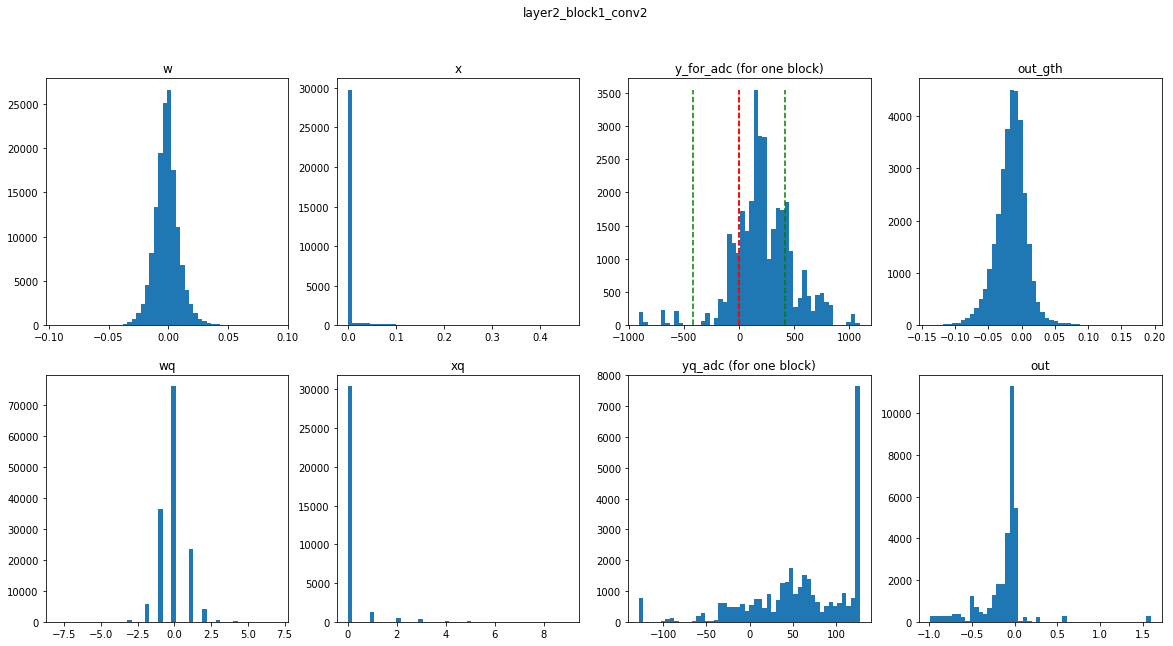

In [ ]:
draw_layer_stats(stats2, 'layer2_block1_conv2', batch_size=1)

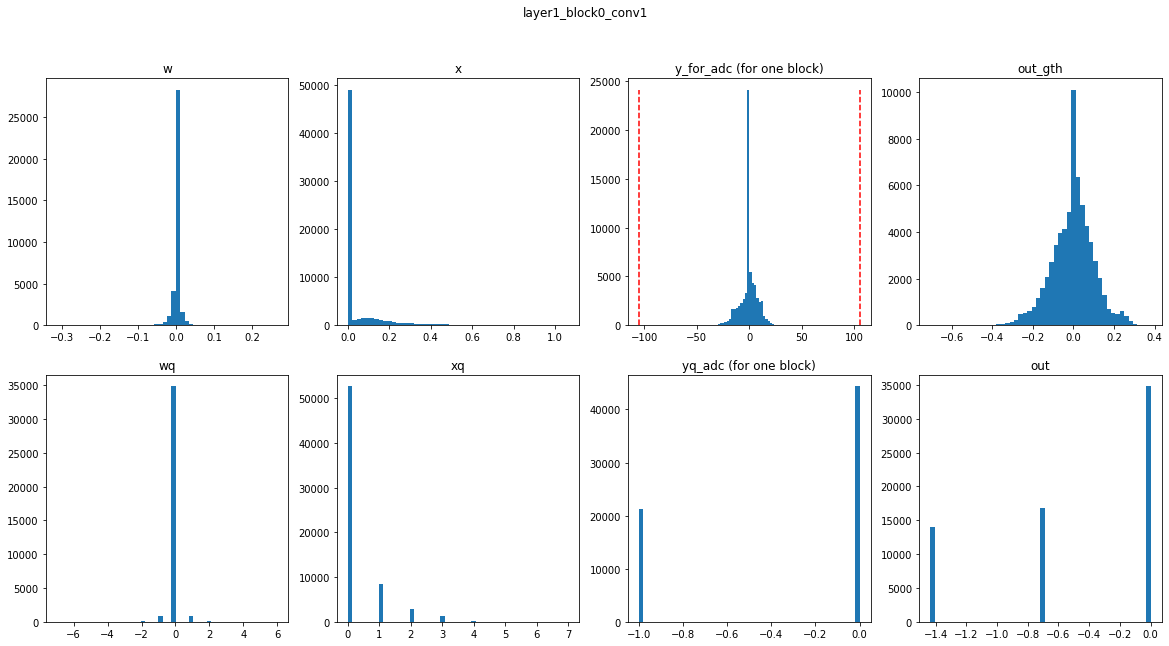

In [ ]:
draw_layer_stats(stats, 'layer1_block0_conv1', batch_size=1)

In [ ]:
0.04 * 7

0.28

In [ ]:
(stats['layer1_block0_conv1']['w'][0] != 0).sum() / stats['layer1_block0_conv1']['w'][0].numel()

tensor(1.)

(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 2.0000e+00, 2.0000e+00,
        8.0000e+00, 9.0000e+00, 7.0000e+00, 1.6000e+01, 2.4000e+01,
        3.7000e+01, 5.7000e+01, 9.7000e+01, 1.7100e+02, 3.9100e+02,
        1.1280e+03, 4.0970e+03, 2.8248e+04, 1.6510e+03, 5.3400e+02,
        1.7700e+02, 7.7000e+01, 2.7000e+01, 3.2000e+01, 1.2000e+01,
        2.1000e+01, 9.0000e+00, 8.0000e+00, 6.0000e+00, 4.0000e+00,
        3.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-0.31377774, -0.3021994 , -0.290621  , -0.27904266, -0.26746428,
        -0.25588593, -0.24430755, -0.23272918, -0.22115082, -0.20957245,
        -0.19799408, -0.18641572, -0.17483735, -0.163259  , -0.15168063,
        -0.14010227, -0.1285239 , -0.11694553, -0.10536716, -0.0937888 ,
        -0.08221044, -0.07

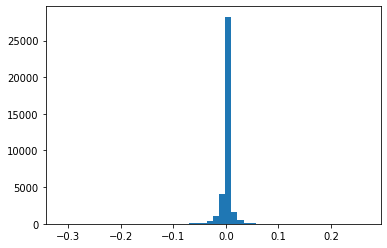

In [ ]:
plt.hist(stats['layer1_block0_conv1']['w'][0].flatten(), bins=50)

def _batched_matmul(self, x, w, w_orig):
        # x (N, L, K*K*C)
        # w (K*K*C, O)
        # Split x, w into several matrices along dimension L
        Lmax = x.shape[-1]
        while (Lmax > self.max_block):
            assert Lmax % 2 == 0
            Lmax //= 2
        if (self.ashift):
            x = x - self.C
        x_splits = torch.split(x, Lmax, dim=-1)
        w_splits = torch.split(w, Lmax, dim=0)
        w_orig_splits = torch.split(w_orig, Lmax, dim=0)
        assert len(x_splits) == len(w_splits)
        y_for_adc = [x_splits[i] @ w_splits[i] for i in range(len(x_splits))]
        # ADC quantizers are different
        yq_adc = [self.adc_quantizer(y) for y in y_for_adc]
        out = [self.dequantize(yq_adc[i], w_splits[i], w_orig_splits[i]) for i in range(len(yq_adc))] # (N, O)_i
        if (self.logger and self.logger.enabled):
            self.logger.log_data(self, [y_for_adc, yq_adc], ["y_for_adc", "yq_adc"])
        return sum(out)

    def _unfold_conv(self, w, input):
        H_in = input.shape[-2]
        W_in = input.shape[-1]

        inp_unf = torch.nn.functional.unfold(input, kernel_size = self.kernel_size, stride = self.stride, dilation=self.dilation, padding=self.padding) # N, K * K, L
        inp_unf = inp_unf.transpose(1, 2) # N, L, K * K * IN
        w = w.view(w.size(0), -1).t() # K * K * IN, O
        w_orig = self.weight.view(self.weight.size(0), -1).t()
        
        #out_unf = inp_unf @ w # N, L, O
        #print("Internal dims:", inp_unf.shape, w.shape)
        out_unf = self._batched_matmul(inp_unf, w, w_orig)
        
        out_unf = out_unf.transpose(1, 2) # N, O, L
        H_out = ((H_in + 2*self.padding[0] - self.dilation[0] * (self.kernel_size[0] - 1) - 1) // self.stride[0]) + 1
        W_out = ((W_in + 2*self.padding[1] - self.dilation[1] * (self.kernel_size[1] - 1) - 1) // self.stride[1]) + 1 
        out = out_unf.view(out_unf.shape[0], out_unf.shape[1], H_out, W_out)
    
        return out 

    def dequantize(self, yq, wq, w_orig):
        # yq: out x H_out x W_out
        # self.weight: out x in x H_out x W_out
        
        # Important!!!!!!!
        y = yq * self.adc_quantizer.delta
        if (self.ashift):
            y = y + self.C * wq.sum(0)
            #y = y + self.C * self.x_quantizer.scale * self.w_quantizer.scale * wq.sum(axis=0)
        #print(y.shape, w_orig.shape)
        #print(w_orig.sum(axis=-1).shape)
        #out = y - self.x_quantizer.zero_point / self.w_quantizer.scale * w_orig.sum(axis=0)
        out = y - self.x_quantizer.zero_point * wq.sum(axis=0)
        out = out * self.x_quantizer.scale * self.w_quantizer.scale
        return out

In [ ]:
xq0 = stats['layer1_block0_conv2']['xq'][0]
layer = model_adc1.layer1[0].conv2
xq0 = torch.nn.functional.unfold(xq0, kernel_size = layer.kernel_size, stride = layer.stride, dilation=layer.dilation, padding=layer.padding)
xq0 = xq0.transpose(1, 2)

wq0 = stats['layer1_block0_conv2']['wq'][0]
wq0 = wq0.view(wq0.size(0), -1).t()
w_splits0 = torch.split(wq0, lmax, dim=0)

In [ ]:
y1 = (xq0 - layer.C) @ wq0
y1 = layer.adc_quantizer(y1)
y1_out = y1 * layer.adc_quantizer.delta + layer.C * wq0.sum(0)

In [ ]:
from ADC.ste import ste_floor

In [ ]:
#y4 = torch.round(y3 / layer.adc_quantizer.delta) * layer.adc_quantizer.delta

In [ ]:
y0 = xq0 @ wq0
y0 = layer.adc_quantizer(y0)
y0_out = y0 * layer.adc_quantizer.delta

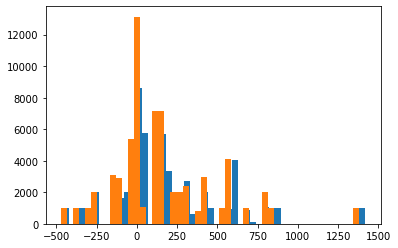

In [ ]:
y3 = ((xq0 - layer.C) @ wq0)
y4 = layer.adc_quantizer(y3) *  layer.adc_quantizer.delta
plt.hist(y3[0].flatten(), bins=50)
plt.hist(y4[0].flatten(), bins=50)
plt.show()

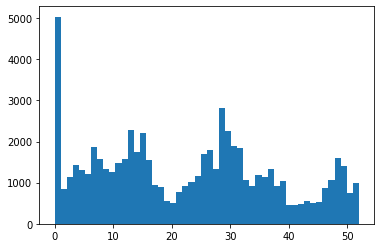

In [ ]:
plt.hist((y3 - y4)[0].flatten(), bins=50)
plt.show()

In [ ]:
y3.shape, y4.shape

(torch.Size([256, 1024, 64]), torch.Size([256, 1024, 64]))

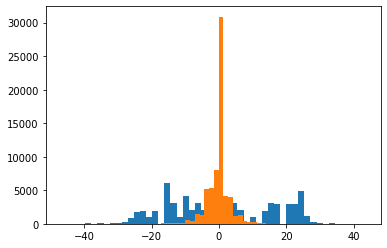

In [ ]:
y5 = y4 + layer.C * wq0.sum(0)
y6 = y3 + layer.C * wq0.sum(0)
plt.hist(y5[0].flatten(), bins=50)
plt.hist(y6[0].flatten(), bins=50)
plt.show()

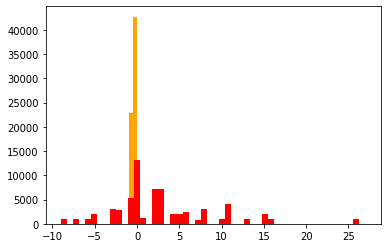

In [ ]:
plt.hist(y0[0].flatten(), bins=2, color='orange')
plt.hist(y1[0].flatten(), bins=50, color='red')
plt.show()

(array([1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 3.0000e+00, 1.0000e+00, 0.0000e+00, 7.0000e+00,
        8.0000e+00, 3.1000e+01, 2.0000e+01, 3.0000e+01, 7.3000e+01,
        4.7000e+01, 1.7400e+02, 1.1400e+02, 1.5700e+02, 5.2300e+02,
        4.1800e+02, 1.5210e+03, 1.3220e+03, 5.1240e+03, 5.2880e+03,
        7.9900e+03, 3.0878e+04, 4.1990e+03, 4.0670e+03, 1.0940e+03,
        1.2590e+03, 3.4900e+02, 2.4200e+02, 2.8400e+02, 8.7000e+01,
        1.1900e+02, 3.2000e+01, 2.0000e+01, 2.0000e+01, 5.0000e+00,
        1.4000e+01, 4.0000e+00, 4.0000e+00, 3.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-37.  , -35.58, -34.16, -32.74, -31.32, -29.9 , -28.48, -27.06,
        -25.64, -24.22, -22.8 , -21.38, -19.96, -18.54, -17.12, -15.7 ,
        -14.28, -12.86, -11.44, -10.02,  -8.6 ,  -7.18,  -5.76,  -4.34,
         -2.92,  -1.5 ,  -0.08,   1.34,   2.76,   4.18,   5.6 ,   7.02,
          8.44,   9.86,  11.28

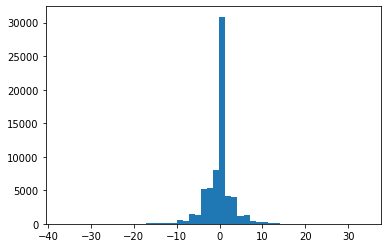

In [ ]:
plt.hist(((xq0 - layer.C) @ wq0 + layer.C * wq0.sum(0))[0].flatten(), bins=50)

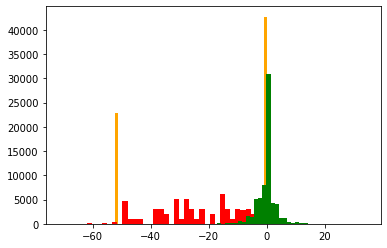

In [ ]:
plt.hist(y0_out[0].flatten(), bins=50, color='orange')
plt.hist(y1_out[0].flatten(), bins=50, color='red')

plt.hist((xq0 @ wq0)[0].flatten(), bins=50, color='green')
plt.show()

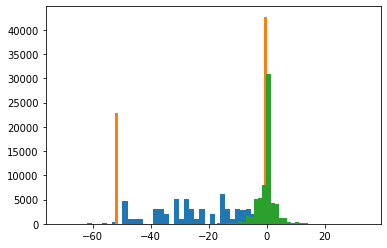

In [ ]:
plt.hist(y1_out[0].flatten(), bins=50)
plt.hist(y0_out[0].flatten(), bins=50)
plt.hist((xq0 @ wq0)[0].flatten(), bins=50)
plt.show()

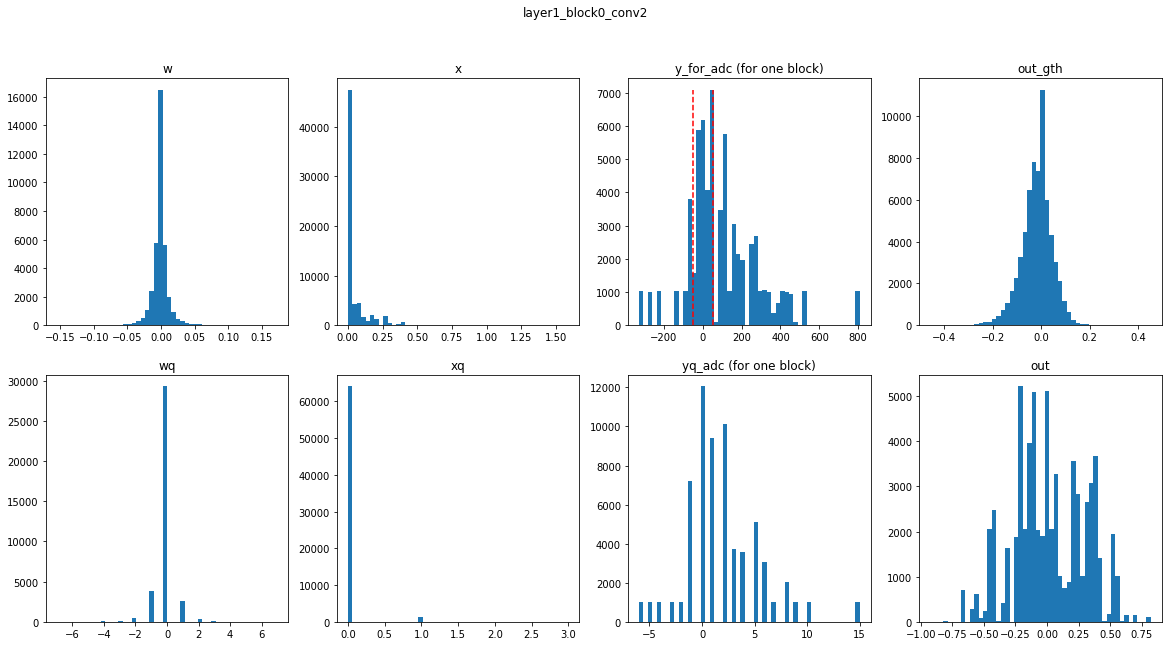

In [ ]:
draw_layer_stats(stats2, 'layer1_block0_conv2', batch_size=1)

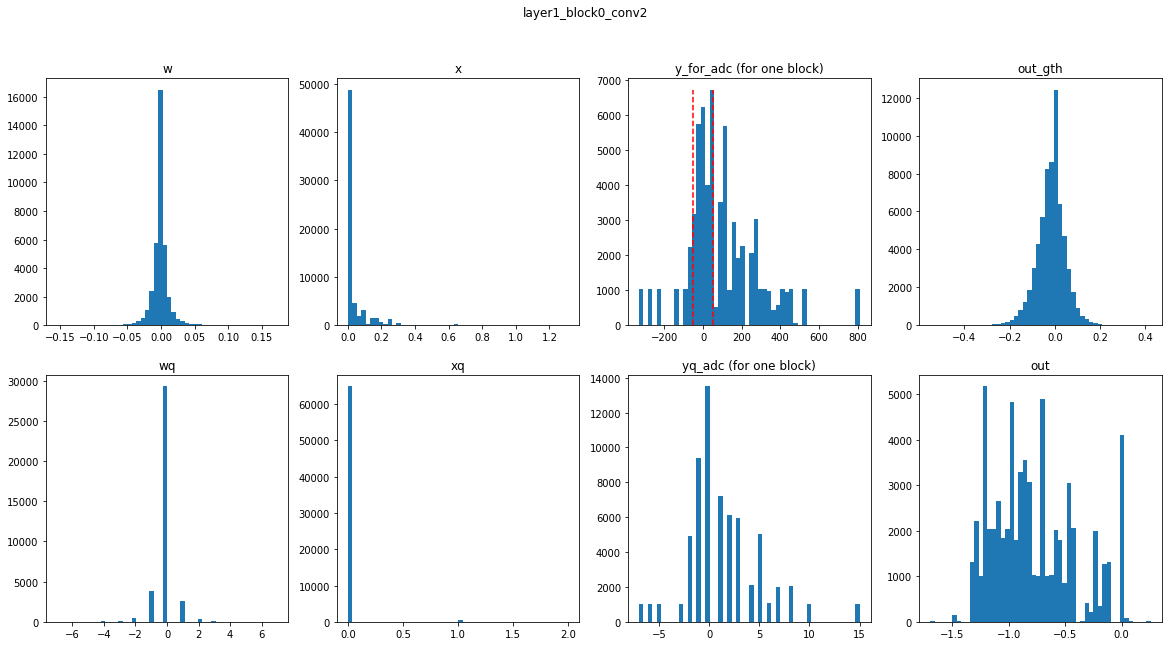

In [ ]:
draw_layer_stats(stats, 'layer1_block0_conv2', batch_size=1)

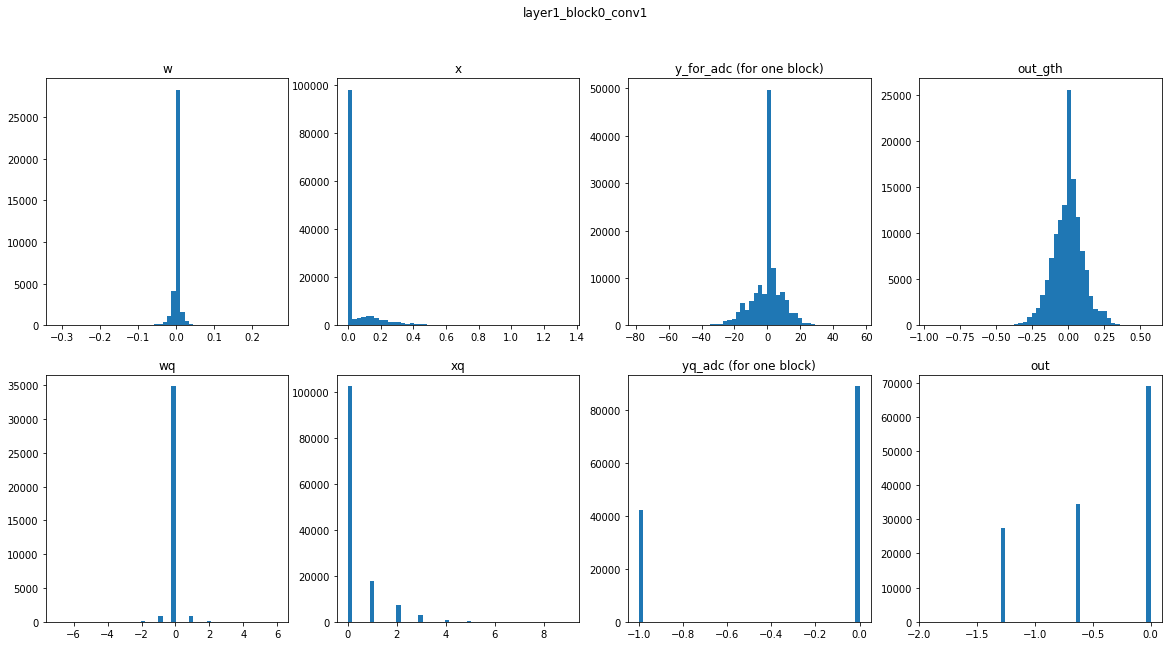

In [ ]:
draw_layer_stats(stats, 'layer1_block0_conv1', batch_size=2)

In [ ]:
layer_gth.padding

(1, 1)

In [ ]:
out_gth.shape, out_blocked.shape

(torch.Size([256, 512, 4, 4]), torch.Size([256, 512, 8, 8]))

In [ ]:
input0 = stats['layer2_block0_conv2']['x'][0].to(device)
layer_gth = deepcopy(model.layer2[0].conv2).to(device)
layer_blocked = BlockedConv2dADC(layer_gth.in_channels, layer_gth.out_channels, kernel_size=layer_gth.kernel_size, padding=layer_gth.padding, bias=layer_gth.bias, max_block=512, k=128).to(device)
layer_blocked.weight = deepcopy(layer_gth.weight)
out_gth = layer_gth(input0)
out_blocked = layer_blocked(input0)
print(input0.shape, out_gth.shape, torch.norm(out_gth - out_blocked) / torch.norm(out_gth))

torch.Size([256, 128, 16, 16]) torch.Size([256, 128, 16, 16]) tensor(0.0900, device='cuda:0', grad_fn=<DivBackward0>)


(array([1.00000e+00, 0.00000e+00, 2.00000e+00, 3.00000e+00, 2.00000e+00,
        0.00000e+00, 5.00000e+00, 1.00000e+01, 4.00000e+00, 1.60000e+01,
        1.70000e+01, 2.30000e+01, 4.50000e+01, 4.90000e+01, 7.40000e+01,
        1.26000e+02, 2.12000e+02, 3.30000e+02, 5.77000e+02, 1.13300e+03,
        2.35900e+03, 5.12600e+03, 1.06770e+04, 1.74510e+04, 2.82030e+04,
        4.63710e+04, 7.35940e+04, 9.84250e+04, 1.12057e+05, 2.09126e+05,
        1.57286e+05, 1.09223e+05, 6.84410e+04, 4.64230e+04, 2.14970e+04,
        1.18640e+04, 1.41020e+04, 9.78700e+03, 2.52700e+03, 8.62000e+02,
        4.18000e+02, 9.30000e+01, 1.70000e+01, 5.00000e+00, 4.00000e+00,
        7.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([-1.029809  , -0.99503964, -0.9602702 , -0.92550087, -0.8907315 ,
        -0.8559621 , -0.82119274, -0.7864233 , -0.75165397, -0.7168846 ,
        -0.6821152 , -0.64734584, -0.6125765 , -0.57780707, -0.5430377 ,
        -0.50826836, -0.47349894, -0.43872958, -0

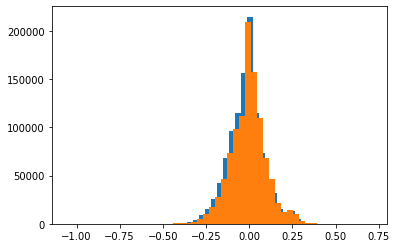

In [ ]:
plt.hist(out_blocked.cpu().detach().numpy()[:16].flatten(), bins=50)
plt.hist(out_gth.cpu().detach().numpy()[:16].flatten(), bins=50)

In [ ]:
layer_blocked

BlockedConv2dADC(
  512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
  (x_quantizer): AffineQuantizerPerTensor(
    (observer): MinMaxObserver(min_val=0.0, max_val=1.829124927520752)
  )
  (w_quantizer): SymmetricQuantizerPerTensor(
    (observer): MinMaxObserver(min_val=-0.31377774477005005, max_val=0.2651405334472656)
  )
  (adc_quantizer): ADCQuantizer()
)

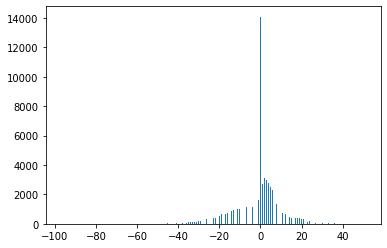

In [ ]:
plt.hist(sum(stats['layer1_block0_conv1']['y_for_adc'])[0].flatten(), bins=500)
plt.show()

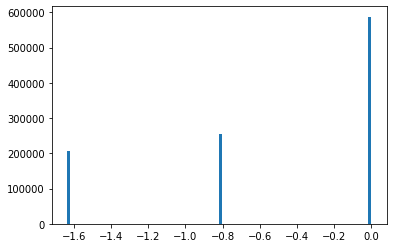

In [ ]:
plt.hist(stats['layer1_block0_conv1']['out'][0][:16].flatten(), bins=100)
plt.show()

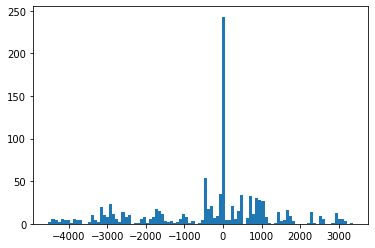

In [ ]:
plt.hist(sum(stats['layer1_block0_conv1']['y_for_adc'])[:16].flatten(), bins=100)
plt.show()

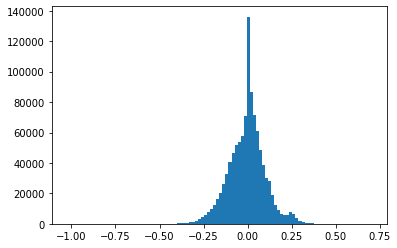

In [ ]:
plt.hist(stats['layer1_block0_conv1']['out_gth'][0][:16].flatten(), bins=100)
plt.show()

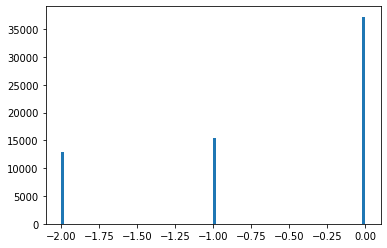

In [ ]:
plt.hist(sum(stats['layer1_block0_conv1']['yq_adc'])[0].flatten(), bins=100)
plt.show()

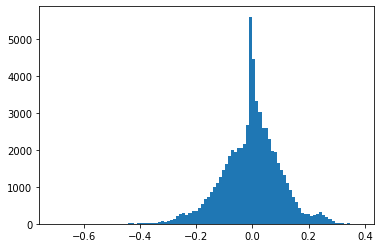

In [ ]:
plt.hist(stats['layer1_block0_conv1']['out_gth'][0][0].flatten(), bins=100)
plt.show()

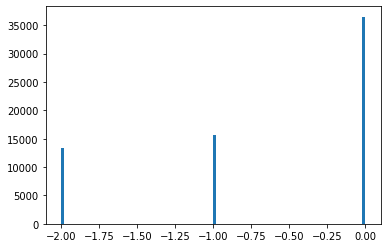

In [ ]:
plt.hist(sum(stats['layer1_block0_conv1']['yq_adc'])[1].flatten(), bins=100)
plt.show()

In [ ]:
model_adc1.layer1[0].conv1.adc_quantizer.delta

105.0

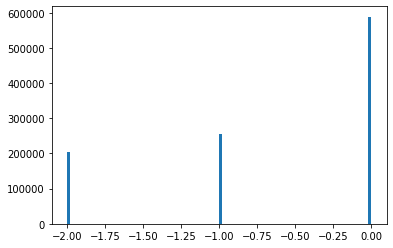

In [ ]:
plt.hist(sum(stats['layer1_block0_conv1']['yq_adc'])[:16].flatten(), bins=100)
plt.show()

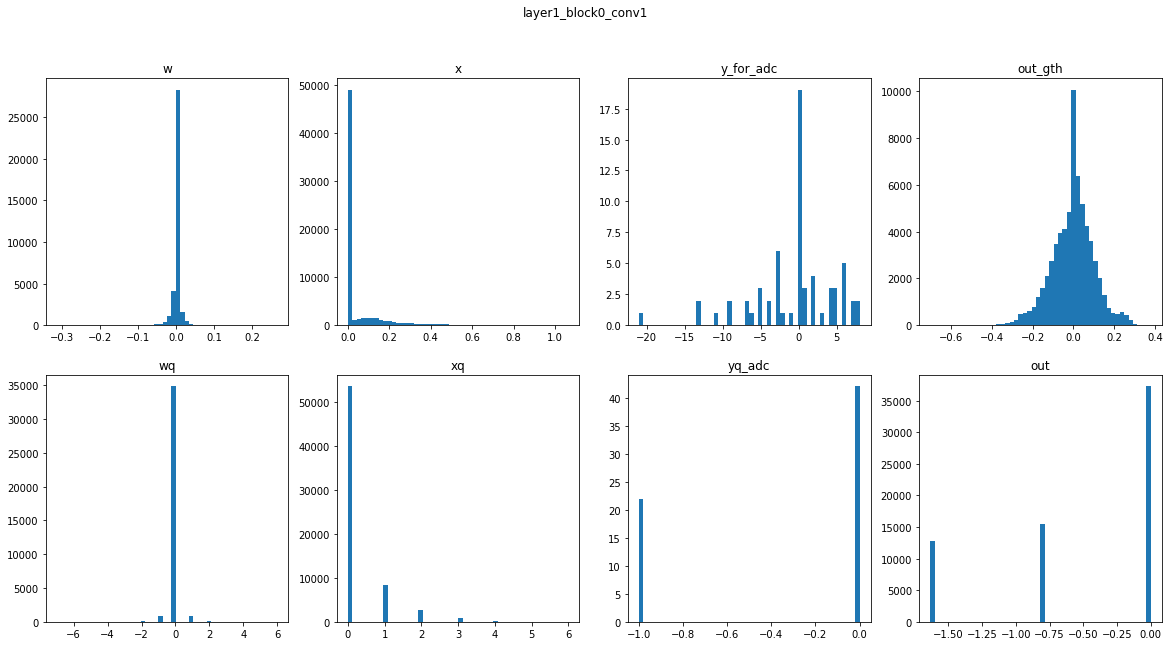

In [ ]:
draw_layer_stats(stats, 'layer1_block0_conv1')

# Finetuning 04.11

In [ ]:
# def disable_adc(model):
#     for nm, m in model.named_modules():
#         #print(nm, print(type(m)))
#         # or isinstance(m, BlockedConv2dADC)
#         if isinstance(m, BlockedConv2dADC) or isinstance(m, LinearADC):
#             #print("here")
#             m.disable_adc()
# def enable_adc(model):
#     for nm, m in model.named_modules():
#         if (nm == 'conv1' or nm == 'fc'):
#             continue
#         #print(nm, print(type(m)))
#         # or isinstance(m, BlockedConv2dADC)
#         if isinstance(m, BlockedConv2dADC) or isinstance(m, LinearADC):
#             #print("here")
#             m.enable_adc()

### Full-precision

In [17]:
print("Full Precision Accuracy")
model_fp = resnet18_cifar(10)
model_fp.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'))
model_fp = model_fp.to(device)
evaluate_model(model_fp, test_loader)

Full Precision Accuracy


Calculating accuracy: 100%|██████████| 40/40 [00:02<00:00, 16.09it/s]


(95.3, 0.17702371735572814)

In [18]:
print("Full Precision Accuracy (W-reshape)")
model_fp_w = resnet18_cifar(10)
model_fp_w.load_state_dict(torch.load('/home/coder/project/resnet18-wreshape-5e-4-st.pth'))
model_fp_w = model_fp_w.to(device)
evaluate_model(model_fp_w, test_loader)

Full Precision Accuracy (W-reshape)


Calculating accuracy:  75%|███████▌  | 30/40 [00:01<00:00, 13.08it/s]

Calculating accuracy: 100%|██████████| 40/40 [00:02<00:00, 15.82it/s]


(95.11, 0.185300745344162)

### No ADC

In [23]:
print("No ADC")

model_qat = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=False, logger=None, conv_type=BlockedConv2dADC)
model_qat.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'), strict=False)
model_qat = model_qat.to(device)

disable_adc(model_qat)
calibrate_model3(model_qat, train_loader, device, 0.2)
evaluate_model(model_qat, test_loader)

No ADC
Calibrating quantizers...
Calibrating weight quantizers...
Calibrating activation quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:02<00:00, 14.57it/s]


(94.38, 0.2160264162540436)

In [24]:
print("No ADC (w-reshape, pretrained)")

model_qat = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=False, logger=None, conv_type=BlockedConv2dADC)
model_qat.load_state_dict(torch.load('/home/coder/project/resnet18-wreshape-5e-4-st.pth'), strict=False)
model_qat = model_qat.to(device)

disable_adc(model_qat)
calibrate_model3(model_qat, train_loader, device, 0.2)
evaluate_model(model_qat, test_loader)

No ADC (w-reshape, pretrained)
Calibrating quantizers...
Calibrating weight quantizers...
Calibrating activation quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:02<00:00, 14.34it/s]


(94.86, 0.2079351490020752)

### ADC, no finetuning

#### Baseline

In [25]:
print("ADC, baseline")

model_adc = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=False, logger=None, conv_type=BlockedConv2dADC)
model_adc.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'), strict=False)
model_adc = model_adc.to(device)

calibrate_model3(model_adc, train_loader, device, 0.2)
evaluate_model(model_adc, test_loader)

ADC, baseline
Calibrating quantizers...
Calibrating weight quantizers...
Calibrating activation quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.69it/s]


(59.78, 1.4212476800918579)

In [27]:
print("ADC, baseline")

model_adc = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=False, logger=None, conv_type=BlockedConv2dADC)
model_adc.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'), strict=False)
model_adc = model_adc.to(device)

calibrate_model3(model_adc, train_loader, device, 0.2)
evaluate_model(model_adc, test_loader)

ADC, baseline
Calibrating quantizers...
Calibrating weight quantizers...
Calibrating activation quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.51it/s]


(59.78, 1.4665920724868775)

In [28]:
optimizer = torch.optim.AdamW(model_adc.parameters(), lr=1e-6, weight_decay=0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = torch.nn.CrossEntropyLoss()
resb = finetune_model(model_adc, optimizer, scheduler, train_loader, test_loader, criterion, device, num_epochs=10, model_name="model4484-wreshape-adc-ft-v1", calib_loader=None, lambda_kurtosis=0.0)


--- Finetuning model4484-wreshape-adc-ft-v1 ---


Validation epoch 1 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.43it/s]


Epoch 1/10 => Train Loss: 1.2378, Train Acc: 63.04% | Test Loss: 1.1639, Test Acc: 65.46%


Validation epoch 2 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.49it/s]


Epoch 2/10 => Train Loss: 1.0518, Train Acc: 67.15% | Test Loss: 0.9979, Test Acc: 69.40%


...

Epoch 8/10 => Train Loss: 0.6095, Train Acc: 79.52% | Test Loss: 0.6486, Test Acc: 78.62%


Validation epoch 9 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.30it/s]


Epoch 9/10 => Train Loss: 0.5554, Train Acc: 81.39% | Test Loss: 0.6144, Test Acc: 79.78%


Validation epoch 10 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.36it/s]


Epoch 10/10 => Train Loss: 0.5191, Train Acc: 82.45% | Test Loss: 0.5697, Test Acc: 81.42%
Training model4484-wreshape-adc-ft-v1 finished in 997.75 seconds.
Final Test Accuracy for model4484-wreshape-adc-ft-v1: 81.42%


In [29]:
resb = finetune_model(model_adc, optimizer, scheduler, train_loader, test_loader, criterion, device, num_epochs=20, model_name="model4484-adc-ft-v1", calib_loader=None, lambda_kurtosis=0.0)


--- Finetuning model4484-adc-ft-v1 ---


Validation epoch 1 / 20: 100%|██████████| 40/40 [00:07<00:00,  5.47it/s]


Epoch 1/20 => Train Loss: 0.4651, Train Acc: 84.28% | Test Loss: 0.5439, Test Acc: 82.39%


Validation epoch 2 / 20: 100%|██████████| 40/40 [00:07<00:00,  5.46it/s]


Epoch 2/20 => Train Loss: 0.4345, Train Acc: 85.34% | Test Loss: 0.5148, Test Acc: 83.05%


...

Epoch 18/20 => Train Loss: 0.1554, Train Acc: 94.74% | Test Loss: 0.3269, Test Acc: 89.55%


Validation epoch 19 / 20: 100%|██████████| 40/40 [00:07<00:00,  5.53it/s]


Epoch 19/20 => Train Loss: 0.1495, Train Acc: 94.94% | Test Loss: 0.3068, Test Acc: 90.32%


Validation epoch 20 / 20: 100%|██████████| 40/40 [00:07<00:00,  5.53it/s]


Epoch 20/20 => Train Loss: 0.1439, Train Acc: 95.14% | Test Loss: 0.3075, Test Acc: 90.34%
Training model4484-adc-ft-v1 finished in 1993.19 seconds.
Final Test Accuracy for model4484-adc-ft-v1: 90.34%


#### W-reshape

In [25]:
print("ADC, W-reshape")

model_adc_w = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=False, logger=None, conv_type=BlockedConv2dADC)
model_adc_w.load_state_dict(torch.load('/home/coder/project/resnet18-wreshape-5e-4-st.pth'), strict=False)
model_adc_w = model_adc_w.to(device)

calibrate_model3(model_adc_w, train_loader, device, 0.2)
evaluate_model(model_adc_w, test_loader)

ADC, W-reshape
Calibrating quantizers...
Calibrating weight quantizers...
Calibrating activation quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.34it/s]


(91.83, 0.29274109582901003)

In [26]:
optimizer = torch.optim.AdamW(model_adc_w.parameters(), lr=1e-6, weight_decay=0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = torch.nn.CrossEntropyLoss()
resaw = finetune_model(model_adc_w, optimizer, scheduler, train_loader, test_loader, criterion, device, num_epochs=10, model_name="model4484-wreshape-adc-ft-v1", calib_loader=None, lambda_kurtosis=0.0)


--- Finetuning model4484-wreshape-adc-ft-v1 ---


Validation epoch 1 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.42it/s]


Epoch 1/10 => Train Loss: 0.0381, Train Acc: 98.90% | Test Loss: 0.2614, Test Acc: 92.43%


Validation epoch 2 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.49it/s]


Epoch 2/10 => Train Loss: 0.0283, Train Acc: 99.23% | Test Loss: 0.2507, Test Acc: 92.94%


...

Epoch 8/10 => Train Loss: 0.0109, Train Acc: 99.75% | Test Loss: 0.2395, Test Acc: 93.71%


Validation epoch 9 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.33it/s]


Epoch 9/10 => Train Loss: 0.0105, Train Acc: 99.76% | Test Loss: 0.2300, Test Acc: 93.78%


Validation epoch 10 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.43it/s]


Epoch 10/10 => Train Loss: 0.0097, Train Acc: 99.80% | Test Loss: 0.2409, Test Acc: 93.55%
Training model4484-wreshape-adc-ft-v1 finished in 995.33 seconds.
Final Test Accuracy for model4484-wreshape-adc-ft-v1: 93.55%


#### A-shift

In [27]:
print("ADC, baseline + Ashift")

model_adc = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=True, logger=None, conv_type=BlockedConv2dADC)
model_adc.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'), strict=False)
model_adc = model_adc.to(device)

calibrate_model3(model_adc, train_loader, device, 0.2)
evaluate_model(model_adc, test_loader)

ADC, baseline + Ashift
Calibrating quantizers...
Calibrating weight quantizers...
Calibrating activation quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.27it/s]


(9.93, 4.05479068069458)

#### W-reshape + A-shift

In [23]:
print("ADC, W-reshape + Ashift")

model_adc_aw = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=True, logger=None, conv_type=BlockedConv2dADC)
model_adc_aw.load_state_dict(torch.load('/home/coder/project/resnet18-wreshape-5e-4-st.pth'), strict=False)
model_adc_aw = model_adc_aw.to(device)

calibrate_model3(model_adc_aw, train_loader, device, 0.2)
evaluate_model(model_adc_aw, test_loader)

ADC, W-reshape + Ashift
Calibrating quantizers...
Calibrating weight quantizers...
Calibrating activation quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.07it/s]


(91.12, 0.2971052930355072)

In [21]:
wandb.init(project=WANDB_PROJECT_NAME)

In [24]:
optimizer = torch.optim.AdamW(model_adc_aw.parameters(), lr=1e-6, weight_decay=0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = torch.nn.CrossEntropyLoss()
resaw = finetune_model(model_adc_aw, optimizer, scheduler, train_loader, test_loader, criterion, device, num_epochs=10, model_name="model4484-wreshape-ashift-adc-ft-v2", calib_loader=None, lambda_kurtosis=0.0)


--- Finetuning model4484-wreshape-ashift-adc-ft-v2 ---


Training epoch 1/10:   0%|          | 0/196 [00:00<?, ?it/s]

Validation epoch 1 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.06it/s]


Epoch 1/10 => Train Loss: 0.0419, Train Acc: 98.77% | Test Loss: 0.2666, Test Acc: 92.62%


Validation epoch 2 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.09it/s]


...

Epoch 8/10 => Train Loss: 0.0132, Train Acc: 99.65% | Test Loss: 0.2263, Test Acc: 94.10%


Validation epoch 9 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.00it/s]


Epoch 9/10 => Train Loss: 0.0113, Train Acc: 99.77% | Test Loss: 0.2405, Test Acc: 93.80%


Validation epoch 10 / 10: 100%|██████████| 40/40 [00:07<00:00,  5.01it/s]


Epoch 10/10 => Train Loss: 0.0112, Train Acc: 99.72% | Test Loss: 0.2338, Test Acc: 93.73%
Training model4484-wreshape-ashift-adc-ft-v2 finished in 1043.21 seconds.
Final Test Accuracy for model4484-wreshape-ashift-adc-ft-v2: 93.73%


### Stats plots

In [33]:
logger0 = LayerwiseStatsLogger()
logger0.enabled = False


model_adc2 = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=False, logger=logger0, conv_type=BlockedConv2dADC)
model_adc2.load_state_dict(torch.load('/home/coder/project/model4484-wreshape-adc-ft-v1-st.pth'))
model_adc2 = model_adc2.to(device)

In [34]:
for mname, module in model_adc2.named_modules():
    #print(mname)
    if hasattr(module, '_set_quantizer_state'):
        module.w_quantizer.update_state(2)
        module.x_quantizer.update_state(2)

In [39]:
for mname, module in model_adc.named_modules():
    #print(mname)
    if hasattr(module, '_set_quantizer_state'):
        module.w_quantizer.update_state(2)
        module.x_quantizer.update_state(2)

In [40]:
evaluate_model(model_adc, test_loader)

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.46it/s]


(90.34, 0.30753022446632383)

In [41]:
model_adc2.load_state_dict(model_adc.state_dict())

<All keys matched successfully>

In [42]:
evaluate_model(model_adc2, test_loader)

Calculating accuracy:   0%|          | 0/40 [00:00<?, ?it/s]

Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.52it/s]


(90.34, 0.30753022446632383)

In [43]:
model_adc2.eval()

ResNetCIFAR_ADC(
  (conv1): BlockedConv2dADC(
    3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
    (x_quantizer): LearnableQuantizerPerTensor(
      (observer): HistogramObserver()
    )
    (w_quantizer): LearnableQuantizerPerTensor(
      (observer): HistogramObserver()
    )
    (adc_quantizer): ADCQuantizer()
  )
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlockADC(
      (conv1): BlockedConv2dADC(
        64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
        (x_quantizer): LearnableQuantizerPerTensor(
          (observer): HistogramObserver()
        )
        (w_quantizer): LearnableQuantizerPerTensor(
          (observer): HistogramObserver()
        )
        (adc_quantizer): ADCQuantizer()
      )
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): BlockedConv2dADC

In [45]:
torch.save(model_adc.state_dict(), 'tmp-0411.pt')

In [46]:
stats = get_stats(model_adc2)

In [47]:
stats.keys()

dict_keys(['layer1_block0_conv1', 'layer1_block0_conv2', 'layer1_block1_conv1', 'layer1_block1_conv2', 'layer2_block0_conv1', 'layer2_block0_conv2', 'layer2_downsample_conv', 'layer2_block1_conv1', 'layer2_block1_conv2', 'layer3_block0_conv1', 'layer3_block0_conv2', 'layer3_downsample_conv', 'layer3_block1_conv1', 'layer3_block1_conv2', 'layer4_block0_conv1', 'layer4_block0_conv2', 'layer4_downsample_conv', 'layer4_block1_conv1', 'layer4_block1_conv2', 'conv1'])

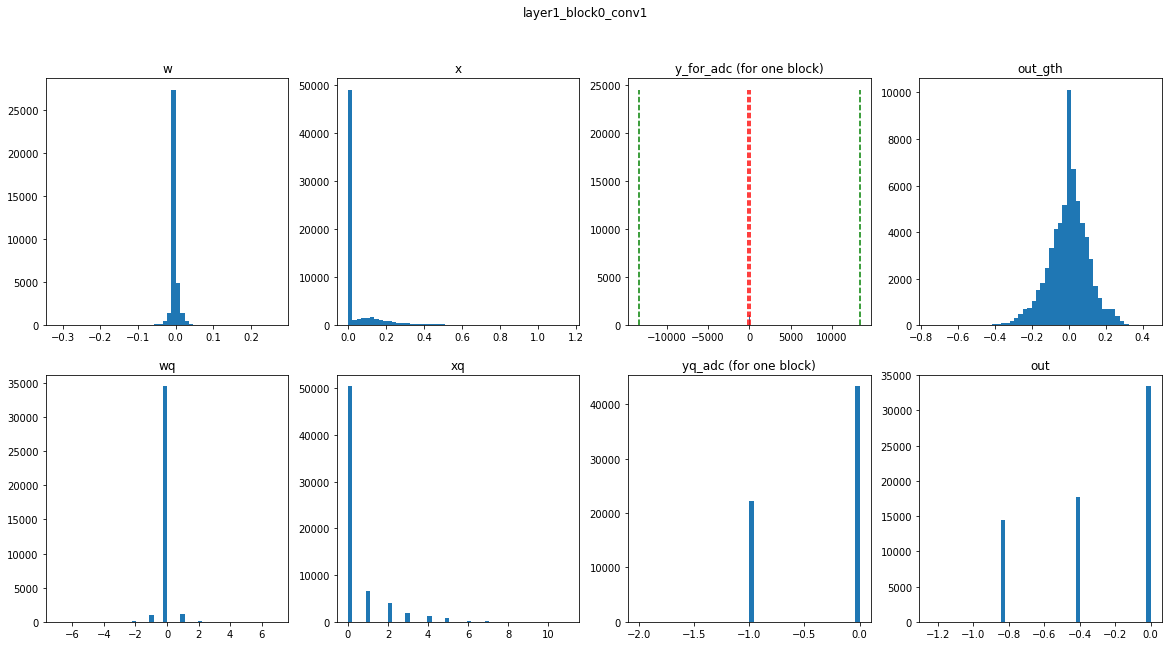

In [49]:
draw_layer_stats(stats, 'layer1_block0_conv1')

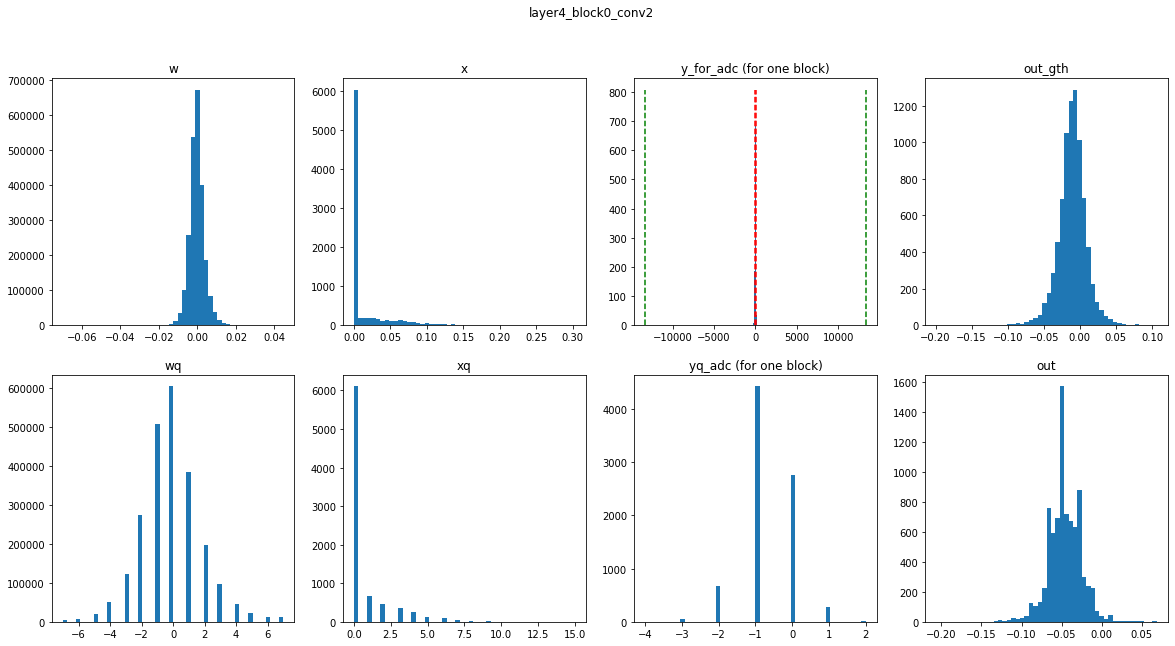

In [51]:
draw_layer_stats(stats, 'layer4_block0_conv2')

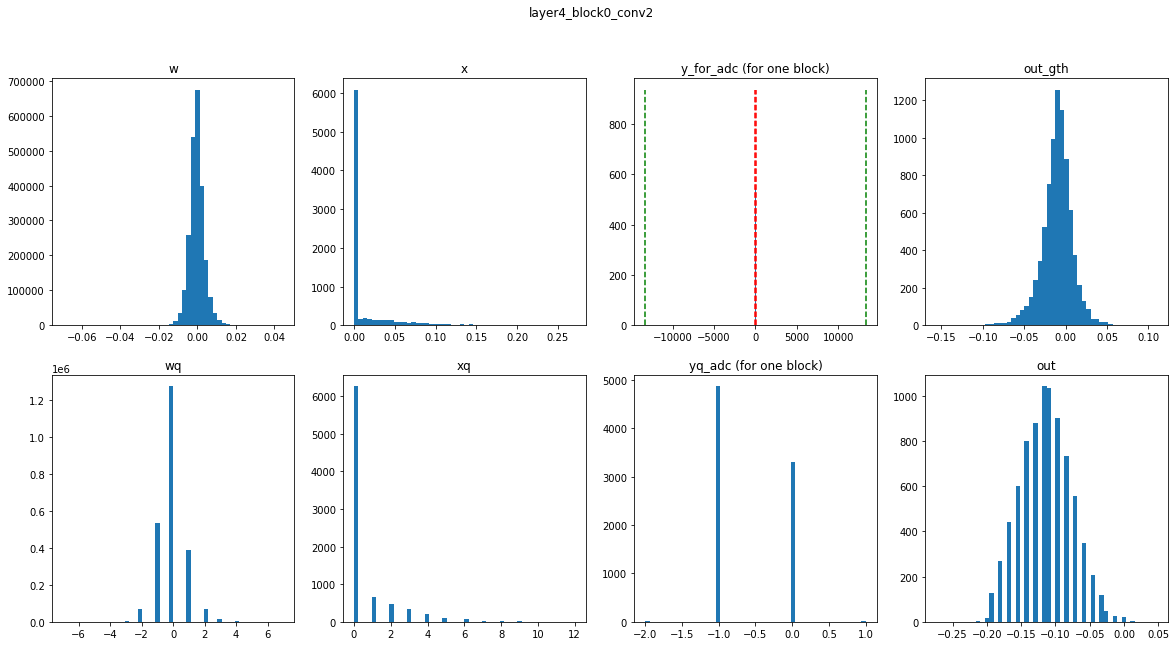

In [61]:
draw_layer_stats(stats_bad, 'layer4_block0_conv2')

In [57]:
logger2 = LayerwiseStatsLogger()
logger2.enabled = False


model_adc0 = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=False, logger=logger2, conv_type=BlockedConv2dADC)
model_adc0.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'), strict=False)
model_adc0 = model_adc0.to(device)

In [58]:
calibrate_model3(model_adc0, train_loader, device, 0.2)

Calibrating quantizers...
Calibrating weight quantizers...
Calibrating activation quantizers...


Calibrating:   0%|          | 0/39 [00:00<?, ?it/s]

Calibration done. Quantizer observers are now disabled.


In [59]:
evaluate_model(model_adc0, test_loader)

Calculating accuracy: 100%|██████████| 40/40 [00:09<00:00,  4.44it/s]


(56.74, 1.5191038373947143)

In [60]:
stats_bad = get_stats(model_adc0)

# Experiments 27.10

#### Accuracy plots

In [17]:
results_all = collect_all_results([4, 8, 16, 32, 64, 128], calib_portion=0.2)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.56it/s]


4 (58.09, 1.5293258220672608)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.12it/s]


64 (10.0, 19.3794951171875)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.11it/s]

128 (10.0, 24.634744223022462)


In [18]:
print(results_all)

{'histogram_floor_false_false': [(4, 58.09, 1.5293258220672608), (8, 79.88, 0.6910692081451416), (16, 89.32, 0.39097561254501345), (32, 93.65, 0.2320775999546051), (64, 94.14, 0.2227225483417511), (128, 94.27, 0.21945272705554963)], 'histogram_floor_true_false': [(4, 10.76, 3.971943283843994), (8, 10.01, 8.503945803833007), (16, 92.35, 0.27266202127933503), (32, 93.85, 0.2354266814470291), (64, 69.22, 0.9209936330795289), (128, 10.0, 3.0252222076416015)], 'histogram_floor_false_true': [(4, 92.04, 0.2777733760118484), (8, 94.18, 0.21598970251083374), (16, 94.46, 0.21369112968444826), (32, 94.57, 0.20919223518371582), (64, 94.66, 0.20633861899375916), (128, 94.49, 0.2127839361190796)], 'histogram_floor_true_true': [(4, 61.69, 1.2053361903190614), (8, 93.32, 0.22429098739624023), (16, 94.3, 0.21697188596725464), (32, 86.94, 0.4764498836517334), (64, 10.0, 7.7721727798461915), (128, 10.0, 3.3803093376159667)], 'histogram_round_false_false': [(4, 48.18, 1.9325704513549804), (8, 79.16, 0.755

In [21]:
results_all = {'histogram_floor_false_false': [(4, 58.09, 1.5293258220672608), (8, 79.88, 0.6910692081451416), (16, 89.32, 0.39097561254501345), (32, 93.65, 0.2320775999546051), (64, 94.14, 0.2227225483417511), (128, 94.27, 0.21945272705554963)], 'histogram_floor_true_false': [(4, 10.76, 3.971943283843994), (8, 10.01, 8.503945803833007), (16, 92.35, 0.27266202127933503), (32, 93.85, 0.2354266814470291), (64, 69.22, 0.9209936330795289), (128, 10.0, 3.0252222076416015)], 'histogram_floor_false_true': [(4, 92.04, 0.2777733760118484), (8, 94.18, 0.21598970251083374), (16, 94.46, 0.21369112968444826), (32, 94.57, 0.20919223518371582), (64, 94.66, 0.20633861899375916), (128, 94.49, 0.2127839361190796)], 'histogram_floor_true_true': [(4, 61.69, 1.2053361903190614), (8, 93.32, 0.22429098739624023), (16, 94.3, 0.21697188596725464), (32, 86.94, 0.4764498836517334), (64, 10.0, 7.7721727798461915), (128, 10.0, 3.3803093376159667)], 'histogram_round_false_false': [(4, 48.18, 1.9325704513549804), (8, 79.16, 0.7555613470077515), (16, 91.67, 0.29903809132575987), (32, 93.61, 0.23748127584457399), (64, 94.34, 0.21439599895477296), (128, 94.21, 0.21582614409923553)], 'histogram_round_true_false': [(4, 9.84, 4.819874543762207), (8, 43.69, 1.7171610553741454), (16, 92.0, 0.2779185456156731), (32, 93.83, 0.23343960247039794), (64, 33.76, 1.9513801107406616), (128, 10.0, 3.163324795913696)], 'histogram_round_false_true': [(4, 92.16, 0.2806685862541199), (8, 93.84, 0.22764761848449708), (16, 94.75, 0.2052361473083496), (32, 94.69, 0.20843297452926635), (64, 94.61, 0.20810102252960205), (128, 94.66, 0.2103640338420868)], 'histogram_round_true_true': [(4, 91.32, 0.2984582574367523), (8, 94.13, 0.2160706328392029), (16, 94.26, 0.219589936542511), (32, 16.39, 2.717053377532959), (64, 10.0, 19.3794951171875), (128, 10.0, 24.634744223022462)]}

In [22]:
results_all['histogram_floor_false_true']

[(4, 92.04, 0.2777733760118484),
 (8, 94.18, 0.21598970251083374),
 (16, 94.46, 0.21369112968444826),
 (32, 94.57, 0.20919223518371582),
 (64, 94.66, 0.20633861899375916),
 (128, 94.49, 0.2127839361190796)]

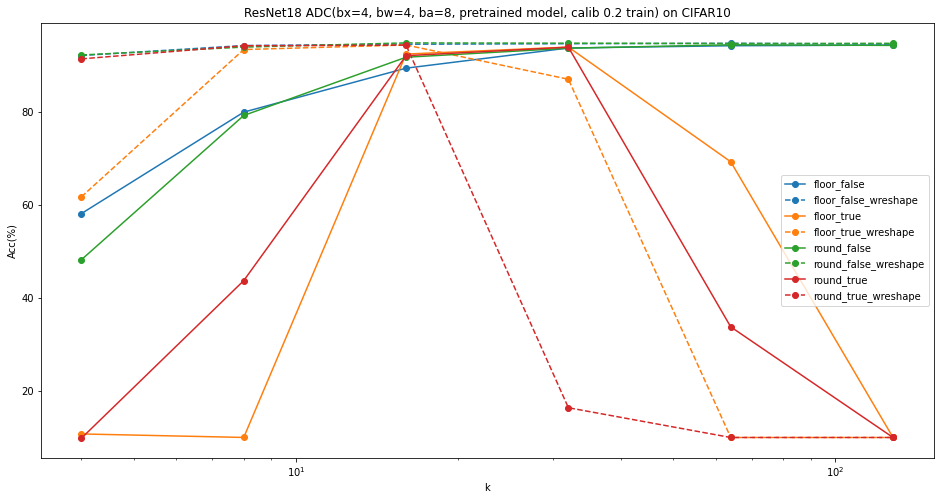

In [19]:
#fig, ax = plt.subplots(1, 2, figsize=(24, 6), sharey=True)

plt.figure(figsize=(16, 8))
k_range = [4, 8, 16, 32, 64, 128]
ste_op = ["floor", "round"]
ashift = ["false", "true"]
colors = ['C0', 'C1', 'C2', 'C3']
for j in range(2):
    for ij in range(2):
        color = colors[j * 2 + ij]
        suf = f"{ste_op[j]}_{ashift[ij]}"
        name = f"{'histogram'}_" + suf

        plt.plot(k_range, [t[1] for t in results_all[name + "_false"]], label=suf, marker='o', color=color)
        plt.plot(k_range, [t[1] for t in results_all[name + "_true"]], 'o--', label=suf + '_wreshape', color=color)
plt.legend()
plt.xscale('log')
plt.xlabel('k')
plt.ylabel('Acc(%)')
plt.title("ResNet18 ADC(bx=4, bw=4, ba=8, pretrained model, calib 0.2 train) on CIFAR10")
plt.show()

In [21]:
evaluate_blocked_model([4, 4, 4], ashift=True, calib_portion=0.2, wreshape = True)

Calibrating quantizers...


Calibrating:   0%|          | 0/39 [00:00<?, ?it/s]

Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.94it/s]


4 (91.29, 0.2996938074588776)
Calibrating quantizers...


...

4 (91.12, 0.3049737117290497)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.16it/s]

4 (91.05, 0.29285129957199096)


[(4, 91.29, 0.2996938074588776),
 (4, 91.12, 0.3049737117290497),
 (4, 91.05, 0.29285129957199096)]

In [25]:
evaluate_blocked_model([4, 4, 4, 4, 4, 4, 4, 4, 4, 4], ashift=True, calib_portion=0.2, wreshape = True)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.18it/s]


4 (91.85, 0.2756852515220642)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

4 (90.43, 0.31265613451004026)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.10it/s]

4 (91.79, 0.28474112052917483)


[(4, 91.85, 0.2756852515220642),
 (4, 92.44, 0.2586893546104431),
 (4, 91.5, 0.29382214965820314),
 (4, 90.98, 0.29727531867027285),
 (4, 91.82, 0.2737235249519348),
 (4, 91.23, 0.29719477338790895),
 (4, 91.02, 0.2926391183853149),
 (4, 90.77, 0.3187243055343628),
 (4, 90.43, 0.31265613451004026),
 (4, 91.79, 0.28474112052917483)]

In [26]:
evaluate_blocked_model([4, 4, 4, 4, 4, 4, 4, 4, 4, 4], ashift=True, calib_portion=0.1, wreshape = True)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.07it/s]


4 (52.33, 1.4470645612716675)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

4 (43.79, 1.5721647792816162)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.06it/s]

4 (54.5, 1.4056734659194947)


[(4, 52.33, 1.4470645612716675),
 (4, 13.86, 2.7426964084625243),
 (4, 48.2, 1.5316808757781983),
 (4, 73.42, 0.8564418167114258),
 (4, 43.98, 1.6864943370819092),
 (4, 54.4, 1.422918782234192),
 (4, 59.48, 1.168675661277771),
 (4, 68.83, 0.9463142732620239),
 (4, 43.79, 1.5721647792816162),
 (4, 54.5, 1.4056734659194947)]

In [24]:
evaluate_blocked_model([4, 4, 4], ashift=True, calib_portion=0.4, wreshape = True)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.13it/s]


4 (90.92, 0.3120022753715515)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

4 (91.46, 0.29313400917053223)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.16it/s]

4 (92.33, 0.2846358776092529)


[(4, 90.92, 0.3120022753715515),
 (4, 91.46, 0.29313400917053223),
 (4, 92.33, 0.2846358776092529)]

In [22]:
results_all["histogram_floor_true_true"]

[(4, 61.69, 1.2053361903190614),
 (8, 93.32, 0.22429098739624023),
 (16, 94.3, 0.21697188596725464),
 (32, 86.94, 0.4764498836517334),
 (64, 10.0, 7.7721727798461915),
 (128, 10.0, 3.3803093376159667)]

In [29]:
results2 = dict()

In [21]:
results2["histogram_floor_false"] = evaluate_blocked_model_wreshape([4, 8, 16, 32, 64, 128], False, 0.1)
print(results2["histogram_floor_false"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.55it/s]


4 (86.87, 0.45176864376068115)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.63it/s]


64 (94.61, 0.21288986234664917)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.60it/s]

128 (94.34, 0.21028037748336792)
[(4, 86.87, 0.45176864376068115), (8, 91.97, 0.2833911647796631), (16, 94.51, 0.21586025543212892), (32, 94.38, 0.20523877835273743), (64, 94.61, 0.21288986234664917), (128, 94.34, 0.21028037748336792)]


In [30]:
results2["histogram_floor_false"] = evaluate_blocked_model_wreshape([4, 8, 16, 32, 64, 128], False, 0.2)
print(results2["histogram_floor_false"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.54it/s]


4 (92.47, 0.26572671213150023)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.58it/s]


64 (94.65, 0.20541759033203125)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.61it/s]

128 (94.39, 0.21054873428344725)
[(4, 92.47, 0.26572671213150023), (8, 94.1, 0.22411553010940552), (16, 94.58, 0.20641255927085878), (32, 94.5, 0.21341412715911864), (64, 94.65, 0.20541759033203125), (128, 94.39, 0.21054873428344725)]


In [22]:
results2["histogram_floor_true"] = evaluate_blocked_model_wreshape([4, 8, 16, 32, 64, 128], True, 0.1)
print(results2["histogram_floor_true"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.11it/s]


4 (75.87, 0.7261715270996094)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.12it/s]


64 (10.0, 3.5730725605010987)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.18it/s]

128 (10.0, 7.590668063354492)
[(4, 75.87, 0.7261715270996094), (8, 86.64, 0.4440462155342102), (16, 91.21, 0.3184593379020691), (32, 10.19, 2.7828544258117676), (64, 10.0, 3.5730725605010987), (128, 10.0, 7.590668063354492)]


In [31]:
results2["histogram_floor_true"] = evaluate_blocked_model_wreshape([4, 8, 16, 32, 64, 128], True, 0.2)
print(results2["histogram_floor_true"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.13it/s]


4 (83.74, 0.6288630447387695)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.14it/s]


64 (10.0, 2.615956265258789)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.98it/s]

128 (10.0, 21.068227783203124)
[(4, 83.74, 0.6288630447387695), (8, 94.24, 0.21768946676254272), (16, 94.21, 0.2197621579170227), (32, 69.77, 1.0559350944519044), (64, 10.0, 2.615956265258789), (128, 10.0, 21.068227783203124)]


In [32]:
ste_func_global = ste_round

In [27]:
results2["histogram_round_false"] = evaluate_blocked_model_wreshape([4, 8, 16, 32, 64, 128], False, 0.1)
print(results2["histogram_round_false"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.59it/s]


4 (17.89, 2.1850850509643553)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.61it/s]


64 (94.71, 0.20737475876808167)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.59it/s]

128 (94.51, 0.21182853746414185)
[(4, 17.89, 2.1850850509643553), (8, 94.47, 0.20956815309524537), (16, 94.66, 0.20723410139083862), (32, 94.44, 0.21274099817276002), (64, 94.71, 0.20737475876808167), (128, 94.51, 0.21182853746414185)]


In [33]:
results2["histogram_round_false"] = evaluate_blocked_model_wreshape([4, 8, 16, 32, 64, 128], False, 0.2)
print(results2["histogram_round_false"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.53it/s]


4 (29.12, 2.1080710216522216)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.55it/s]


64 (94.79, 0.20885025882720948)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.49it/s]

128 (94.68, 0.20568463916778565)
[(4, 29.12, 2.1080710216522216), (8, 94.04, 0.2210010172843933), (16, 94.51, 0.21022741861343383), (32, 94.47, 0.2094431686401367), (64, 94.79, 0.20885025882720948), (128, 94.68, 0.20568463916778565)]


In [28]:
results2["histogram_round_true"] = evaluate_blocked_model_wreshape([4, 8, 16, 32, 64, 128], True, 0.1)
print(results2["histogram_round_true"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.15it/s]


4 (92.57, 0.2615274327278137)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.14it/s]


64 (10.0, 3.4248222885131834)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.13it/s]

128 (10.0, 5.989296340942383)
[(4, 92.57, 0.2615274327278137), (8, 94.27, 0.21991567058563233), (16, 93.16, 0.25469532175064086), (32, 10.2, 2.800468357849121), (64, 10.0, 3.4248222885131834), (128, 10.0, 5.989296340942383)]


In [ ]:
results2["histogram_round_true"] = evaluate_blocked_model_wreshape([4, 8, 16, 32, 64, 128], True, 0.2)
print(results2["histogram_round_true"])

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.15it/s]


4 (90.66, 0.31550784091949463)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


...

32 (79.53, 0.7174960903167724)
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:07<00:00,  5.14it/s]


64 (10.0, 3.7908012897491457)
Calibrating quantizers...


Calibrating:  31%|███       | 12/39 [00:13<00:31,  1.16s/it]

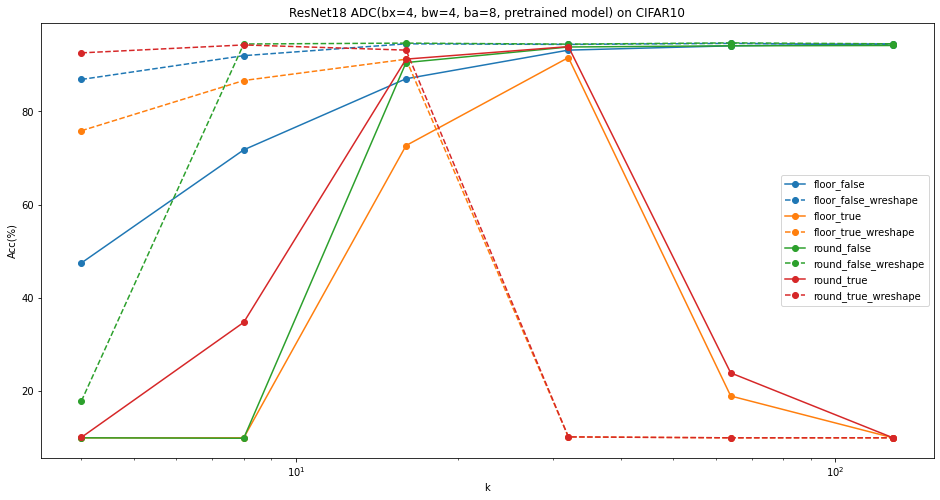

In [51]:
#fig, ax = plt.subplots(1, 2, figsize=(24, 6), sharey=True)

plt.figure(figsize=(16, 8))
k_range = [4, 8, 16, 32, 64, 128]
ste_op = ["floor", "round"]
ashift = ["false", "true"]
colors = ['C0', 'C1', 'C2', 'C3']
for j in range(2):
    for ij in range(2):
        color = colors[j * 2 + ij]
        suf = f"{ste_op[j]}_{ashift[ij]}"
        name = f"{'histogram'}_" + suf

        plt.plot(k_range, [t[1] for t in results[name]], label=suf, marker='o', color=color)
        plt.plot(k_range, [t[1] for t in results2[name]], 'o--', label=suf + '_wreshape', color=color)
plt.legend()
plt.xscale('log')
plt.xlabel('k')
plt.ylabel('Acc(%)')
plt.title("ResNet18 ADC(bx=4, bw=4, ba=8, pretrained model) on CIFAR10")
plt.show()

#### Stats plots

In [60]:
from ADC.logger import LayerwiseStatsLogger

logger = LayerwiseStatsLogger()

logger.enabled = False

model_adc = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=False, logger=logger, conv_type=BlockedConv2dADC)
model_adc.load_state_dict(torch.load('/home/coder/project/resnet18-wreshape-5e-4-st.pth'), strict=False)
model_adc = model_adc.to(device)
calibrate_model(model_adc, train_loader, device, 0.1)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


In [61]:
evaluate_model(model_adc, test_loader)

Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.64it/s]


(85.76, 0.49243953580856326)

In [72]:
logger0 = LayerwiseStatsLogger()

logger0.enabled = False

model_adc0 = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=False, logger=logger0, conv_type=BlockedConv2dADC)
model_adc0.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'), strict=False)
model_adc0 = model_adc0.to(device)
calibrate_model(model_adc0, train_loader, device, 0.1)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


In [73]:
evaluate_model(model_adc0, test_loader)

Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.58it/s]


(45.71, 1.9450170589447022)

In [92]:
loggera = LayerwiseStatsLogger()

loggera.enabled = False

model_adca = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=True, logger=loggera, conv_type=BlockedConv2dADC)
model_adca.load_state_dict(torch.load('/home/coder/project/resnet18-wreshape-5e-4-st.pth'), strict=False)
model_adca = model_adca.to(device)
calibrate_model(model_adca, train_loader, device, 0.1)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


In [93]:
evaluate_model(model_adca, test_loader)

Calculating accuracy: 100%|██████████| 40/40 [00:09<00:00,  4.30it/s]


(72.04, 0.8935481157302857)

In [94]:
statsa = get_stats(model_adca)

In [65]:
stats = get_stats(model_adc)

In [74]:
stats0 = get_stats(model_adc0)

In [76]:
for name in stats.keys():
    print(name)

layer1_block0_conv1
layer1_block0_conv2
layer1_block1_conv1
layer1_block1_conv2
layer2_block0_conv1
layer2_block0_conv2
layer2_downsample_conv
layer2_block1_conv1
layer2_block1_conv2
layer3_block0_conv1
layer3_block0_conv2
layer3_downsample_conv
layer3_block1_conv1
layer3_block1_conv2
layer4_block0_conv1
layer4_block0_conv2
layer4_downsample_conv
layer4_block1_conv1
layer4_block1_conv2


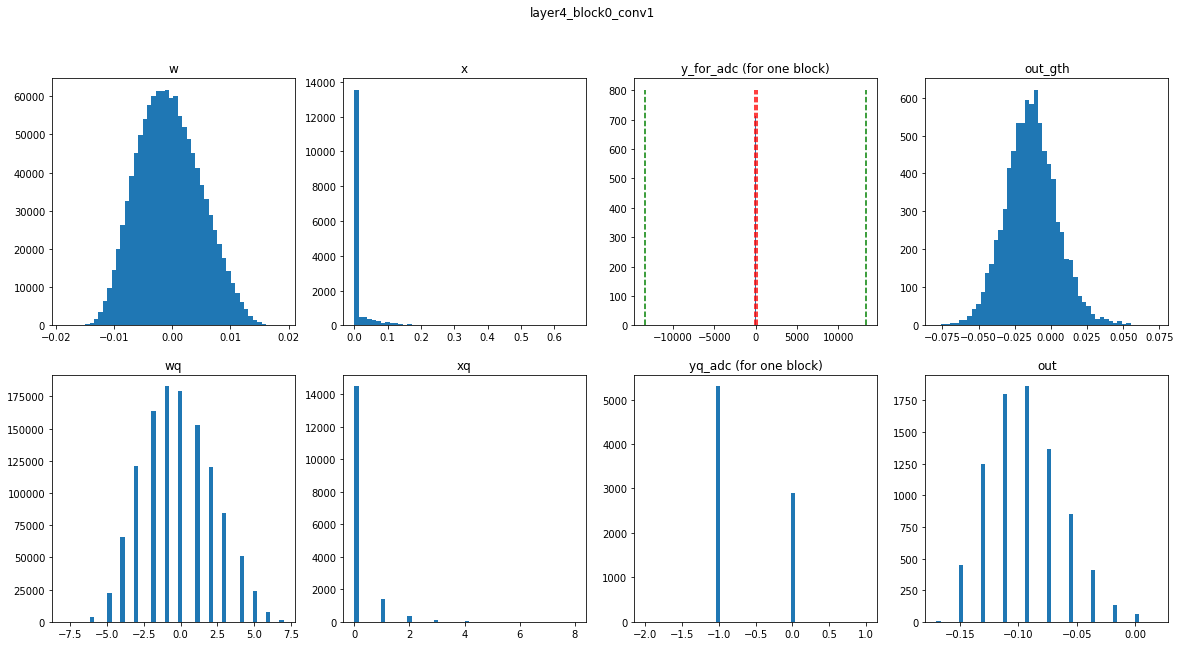

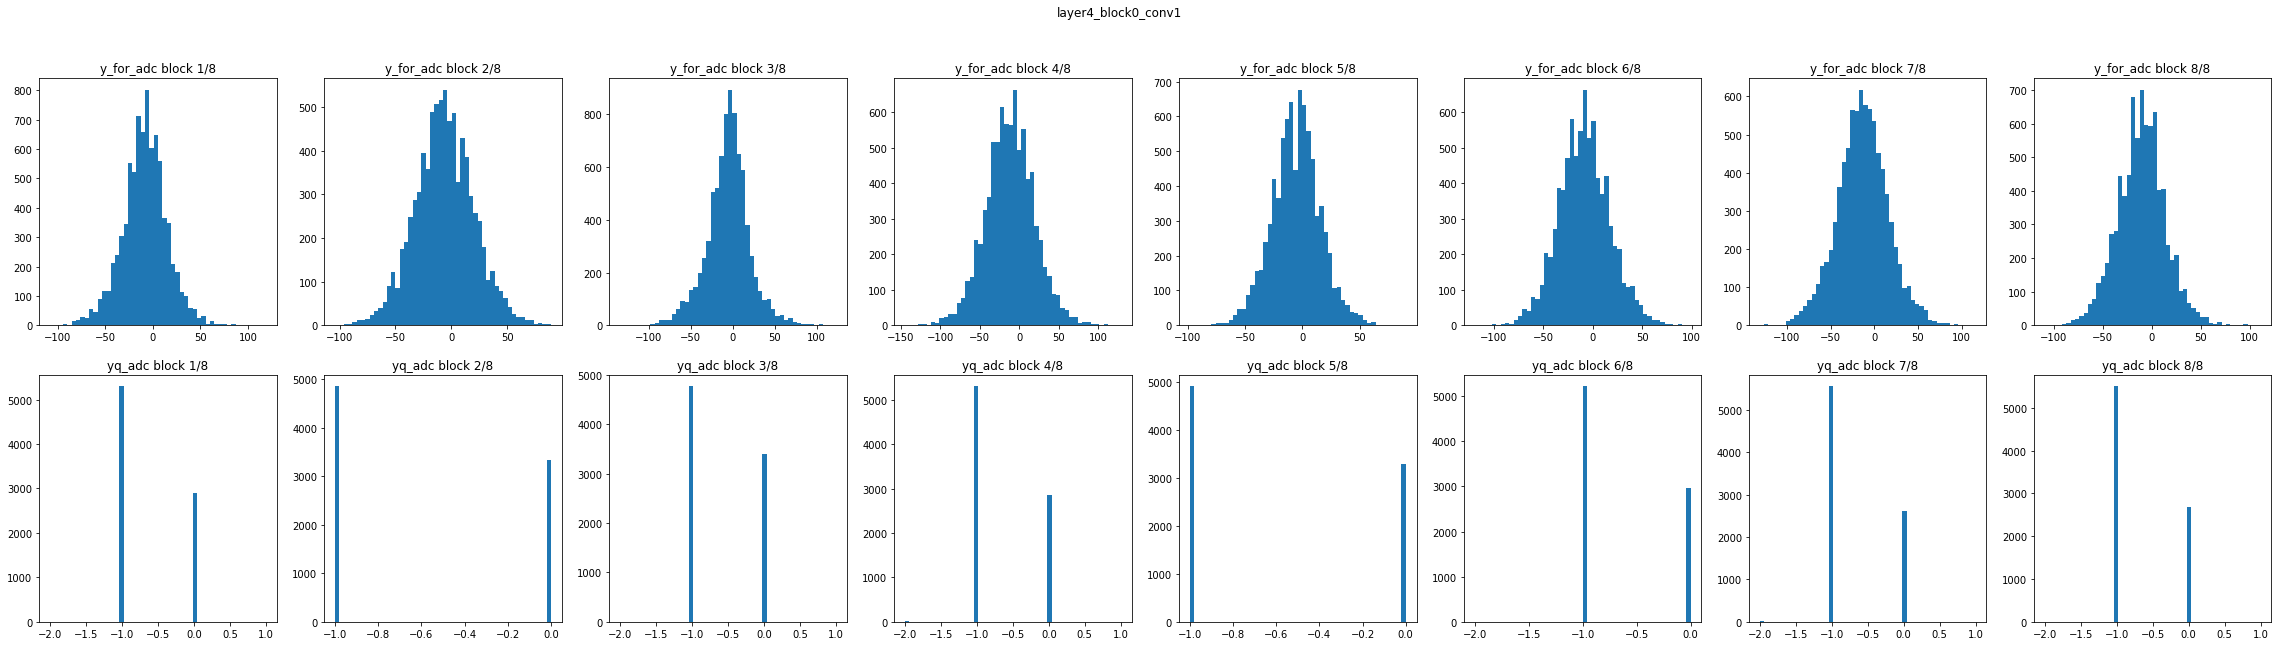

In [91]:
draw_layer_stats(stats, 'layer4_block0_conv1')
draw_layer_stats_y(stats, 'layer4_block0_conv1')

In [88]:
interesting_layers = ['layer1_block0_conv1', 'layer2_block1_conv2', 'layer3_downsample_conv', 'layer4_block0_conv1', 'layer4_block0_conv2', 'layer4_block1_conv2']

##### Layers Ashift + W-reshape + floor

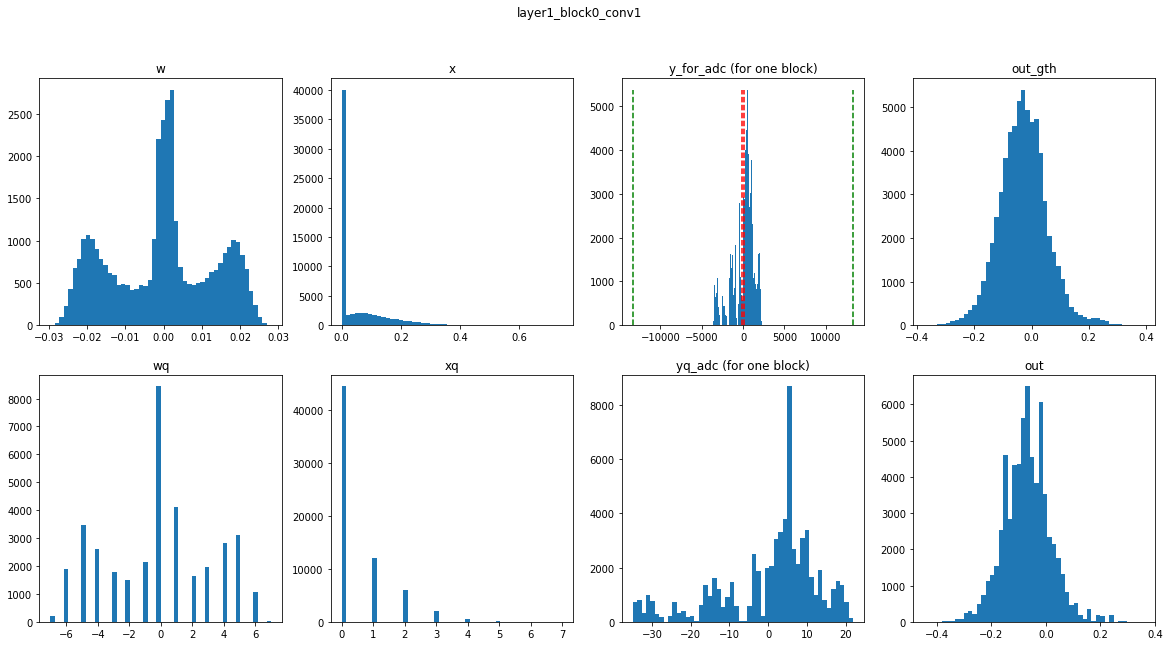

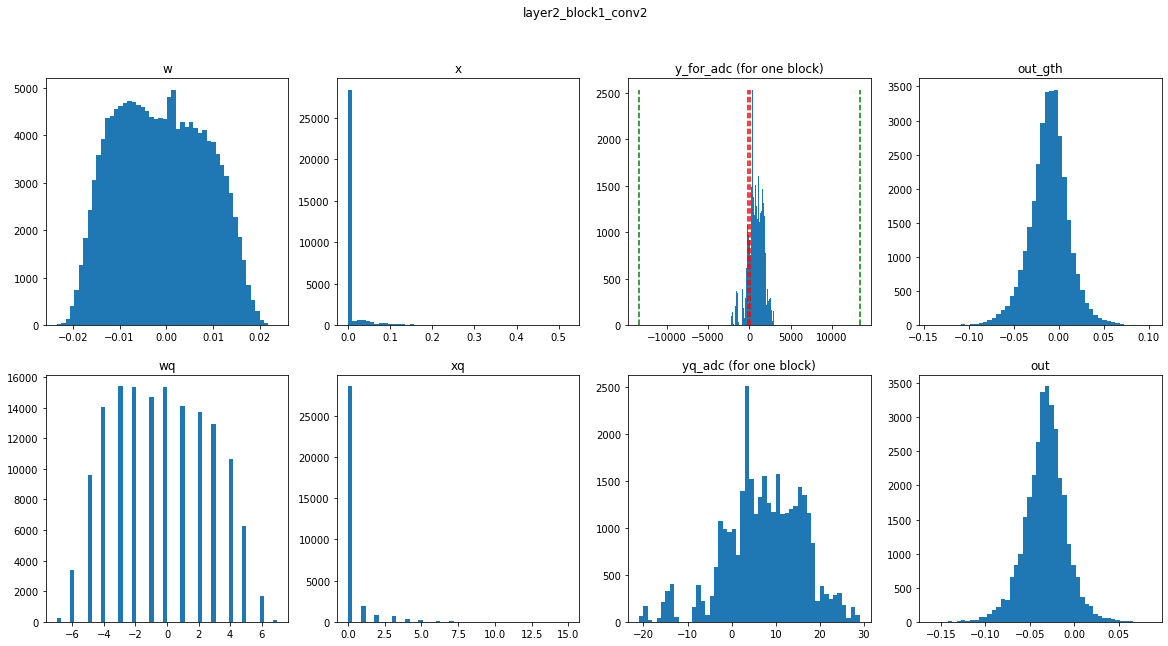

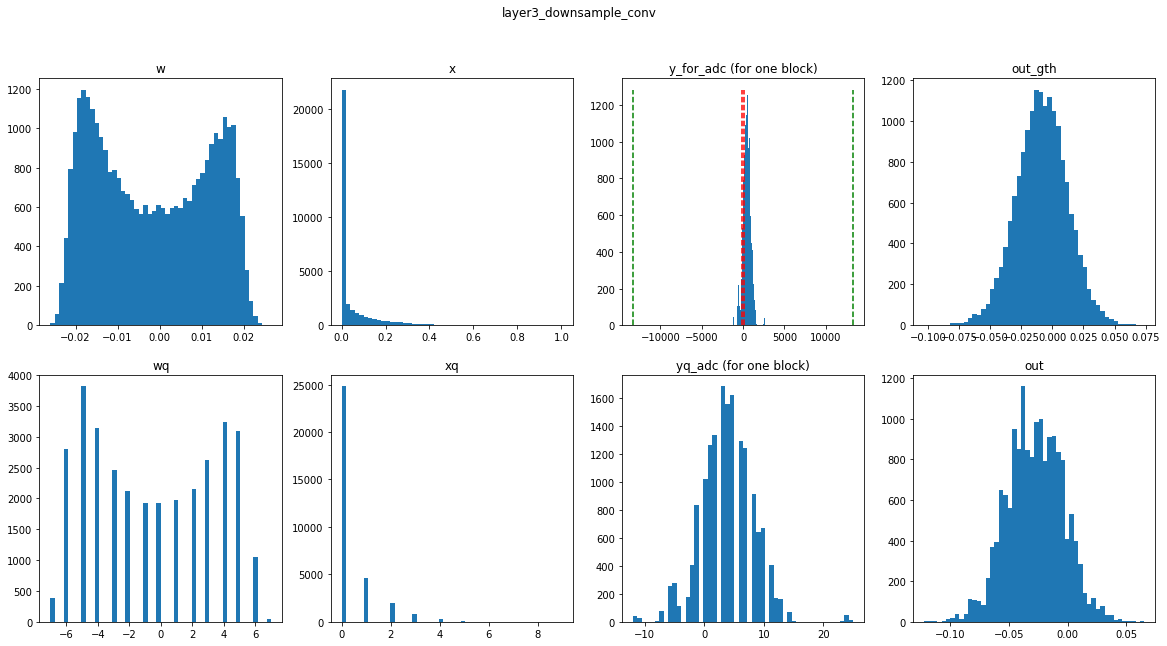

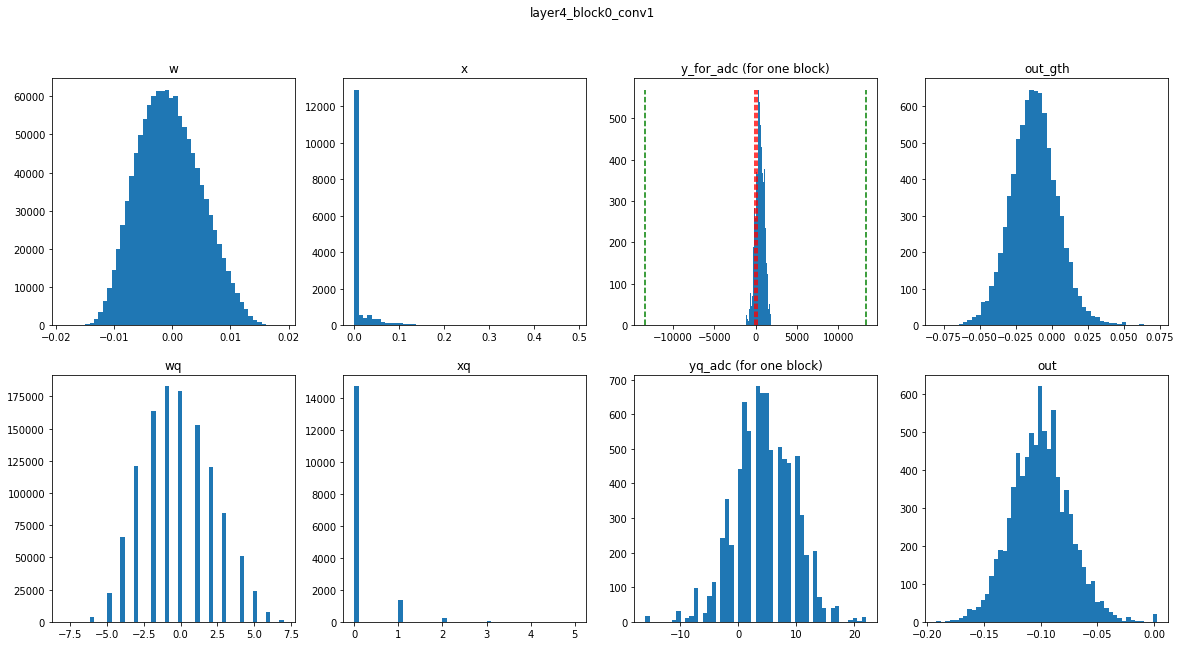

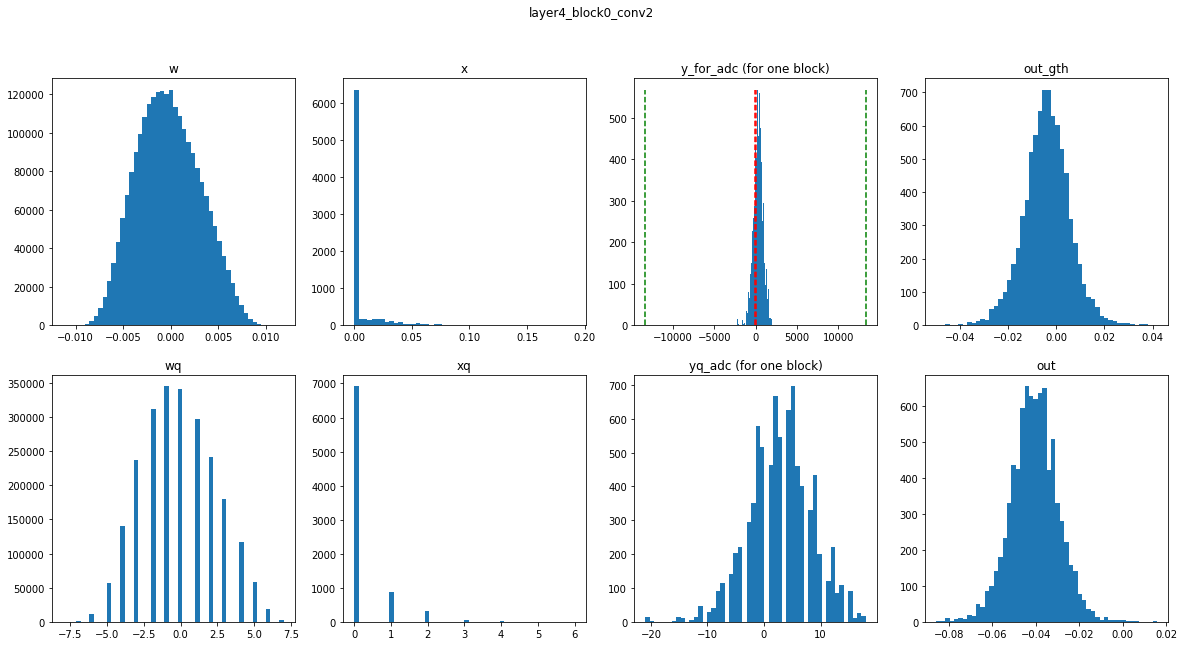

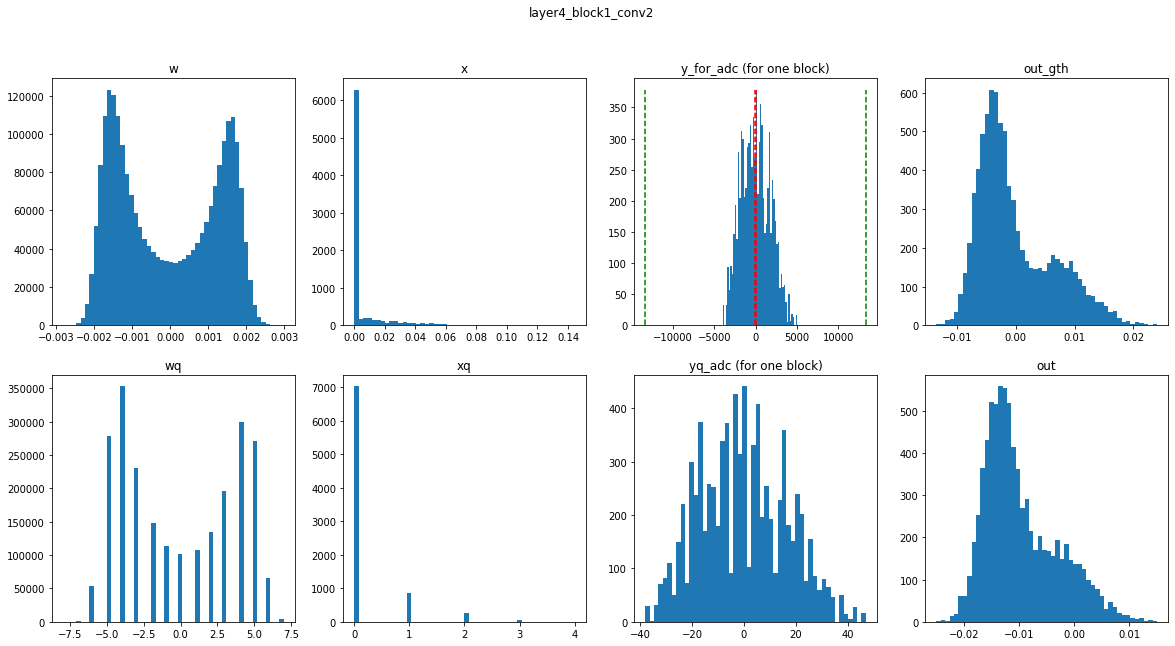

In [96]:
for name in interesting_layers:
    draw_layer_stats(statsa, name)
    plt.show()

##### Comparison with/without W-reshape





----------------------------------------






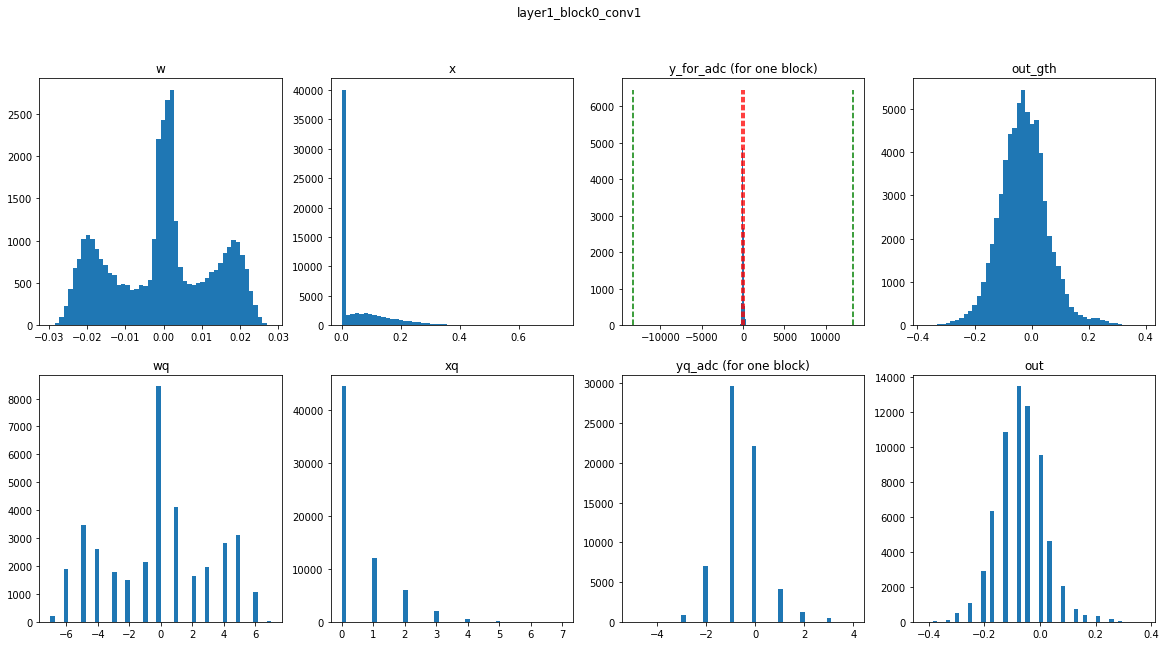

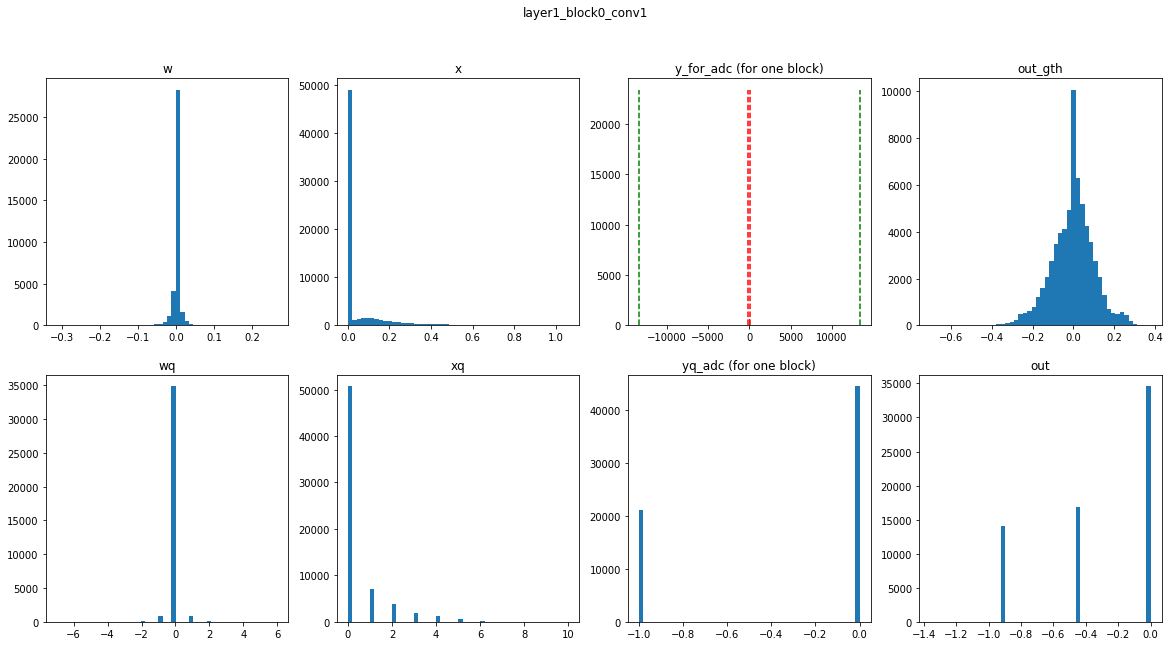





----------------------------------------






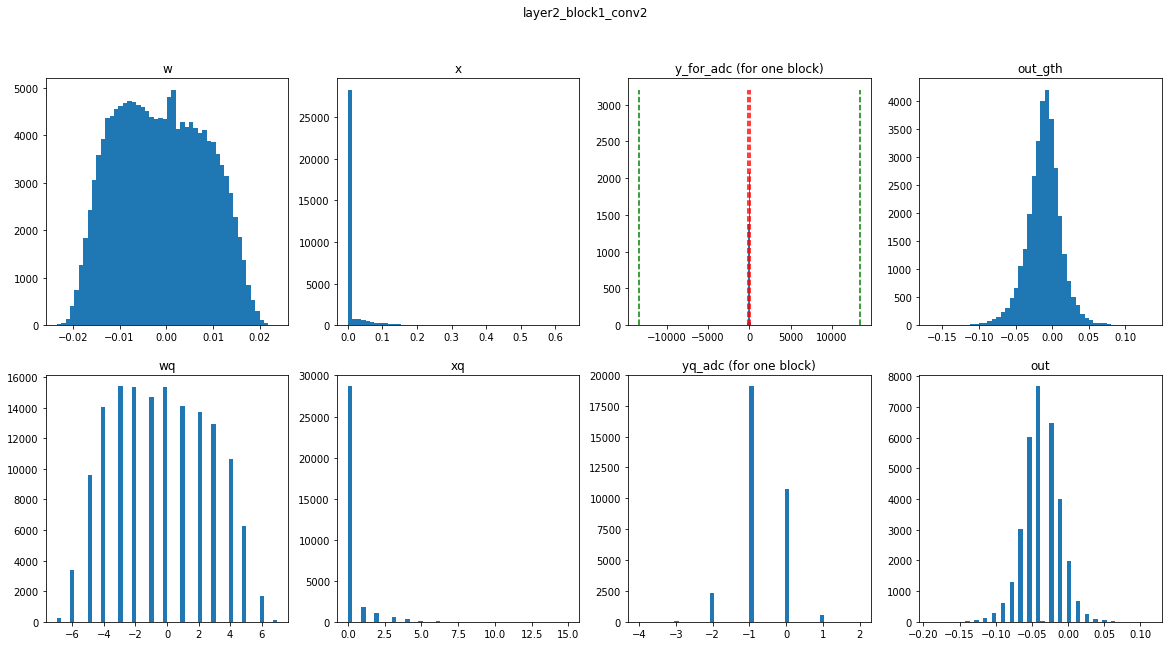

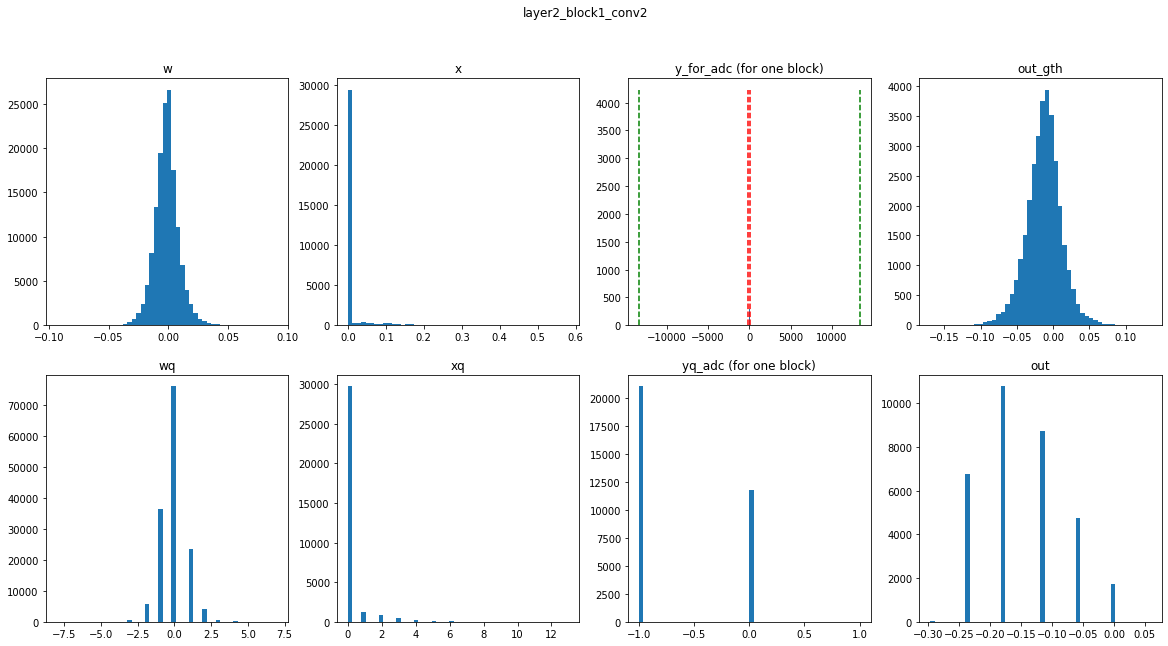





----------------------------------------






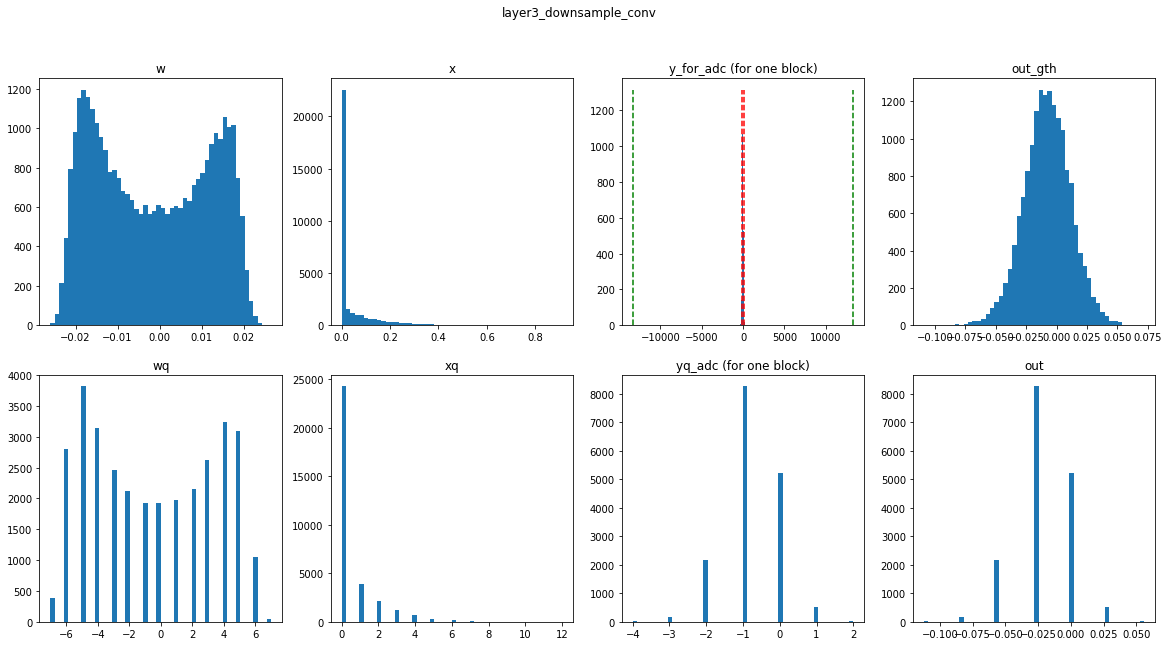

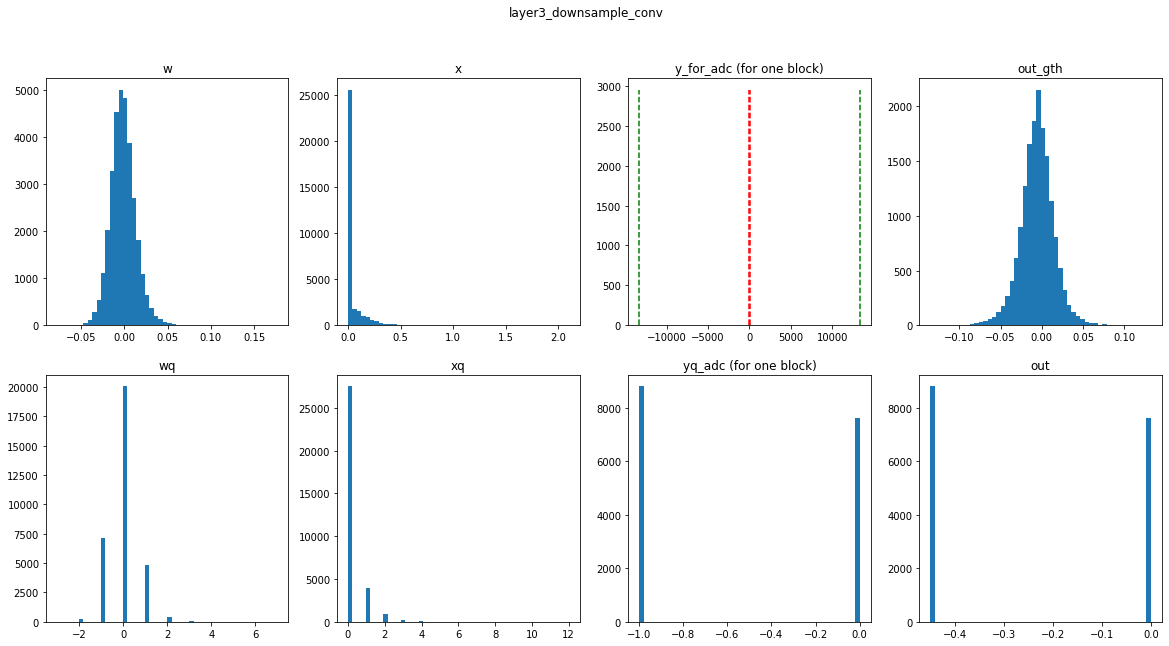





----------------------------------------






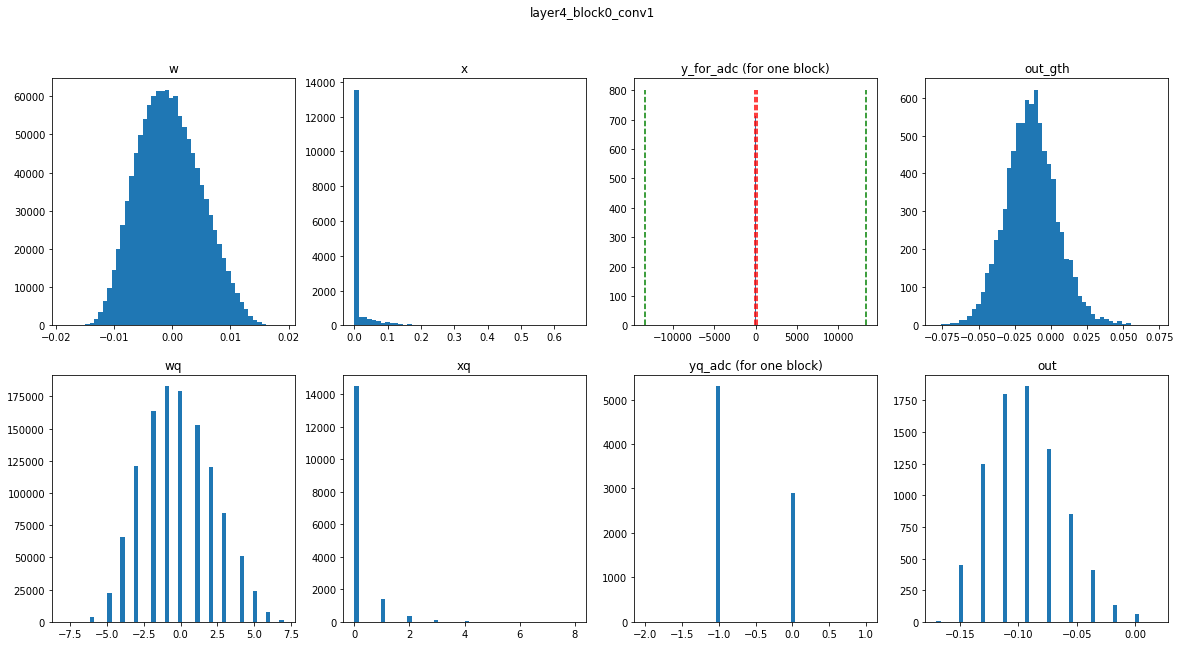

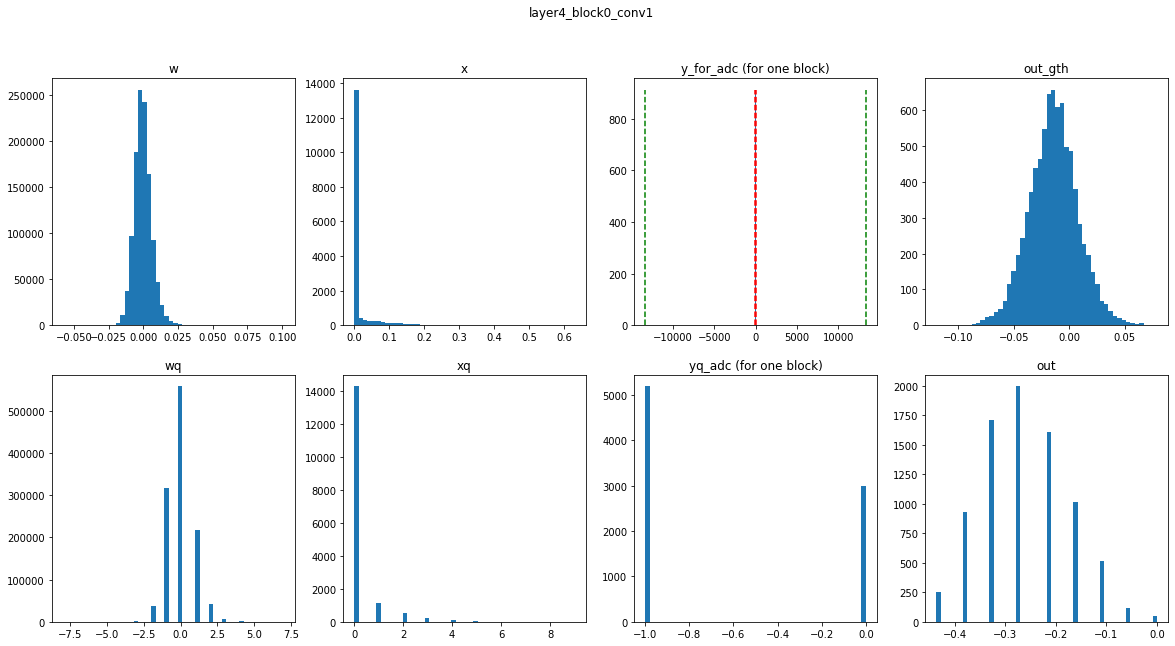





----------------------------------------






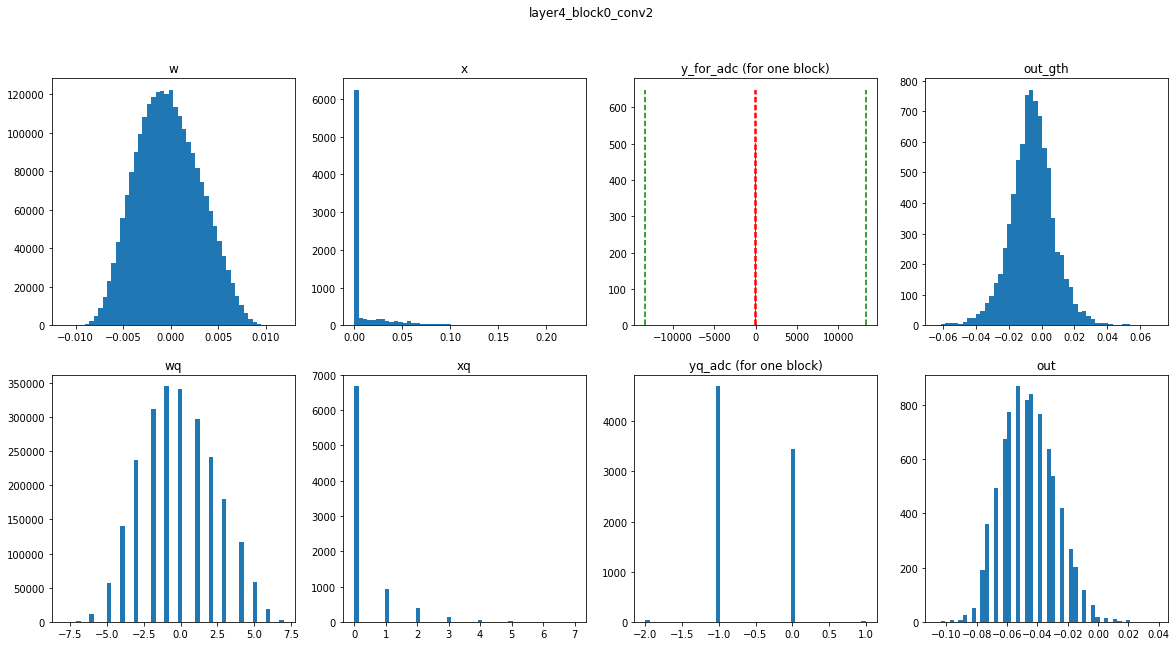

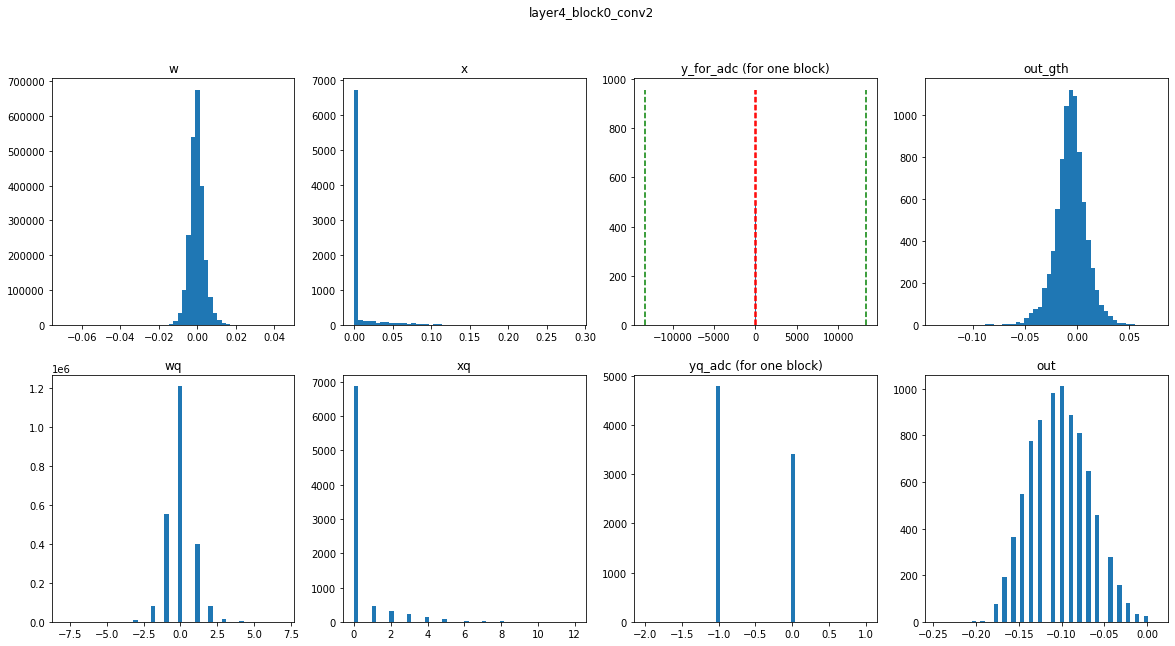





----------------------------------------






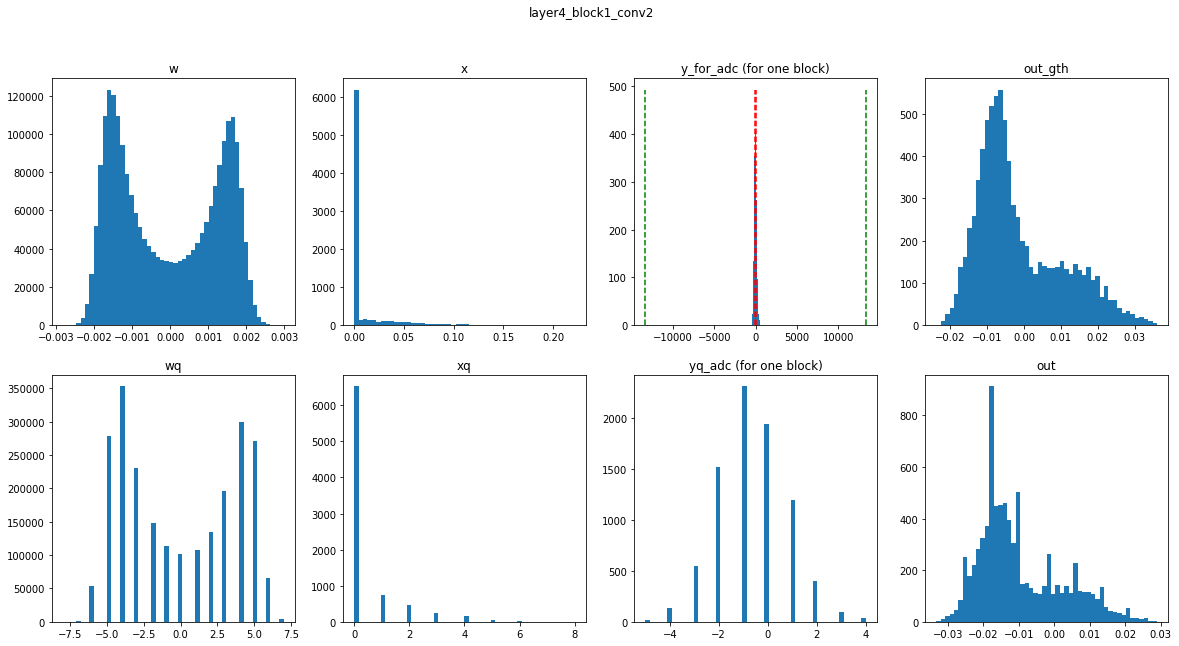

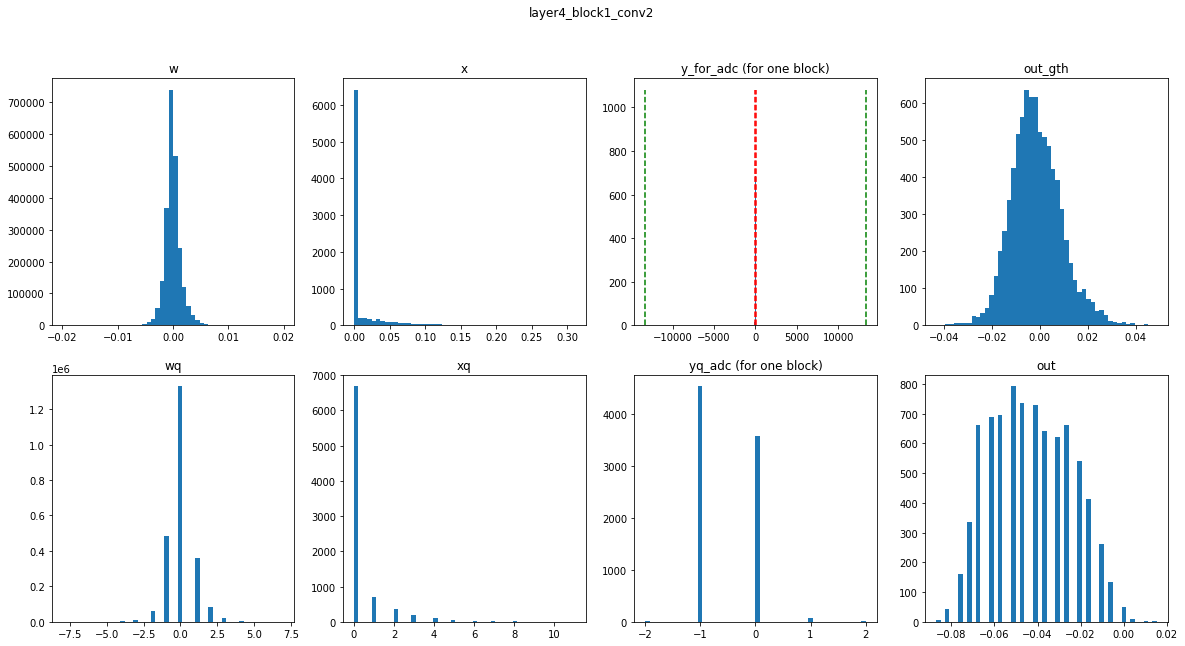

In [89]:
for name in interesting_layers:
    draw_layer_stats(stats, name)
    draw_layer_stats(stats0, name)
    print("\n\n\n\n----------------------------------------\n\n\n\n")
    plt.show()

##### Model without W-reshape layers

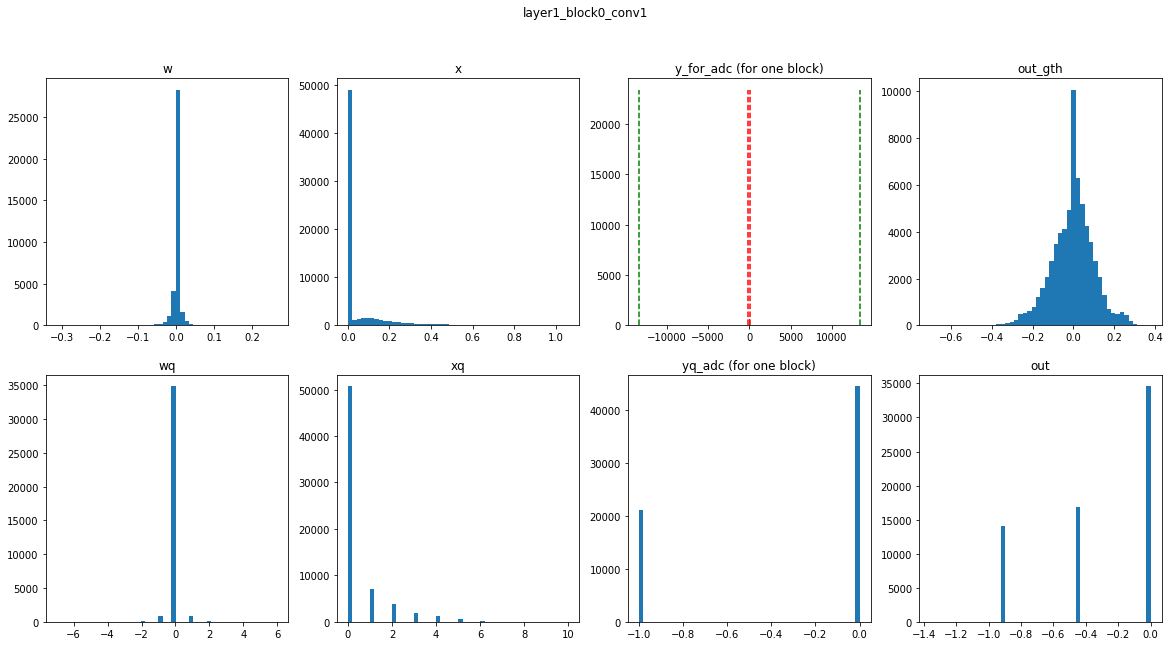

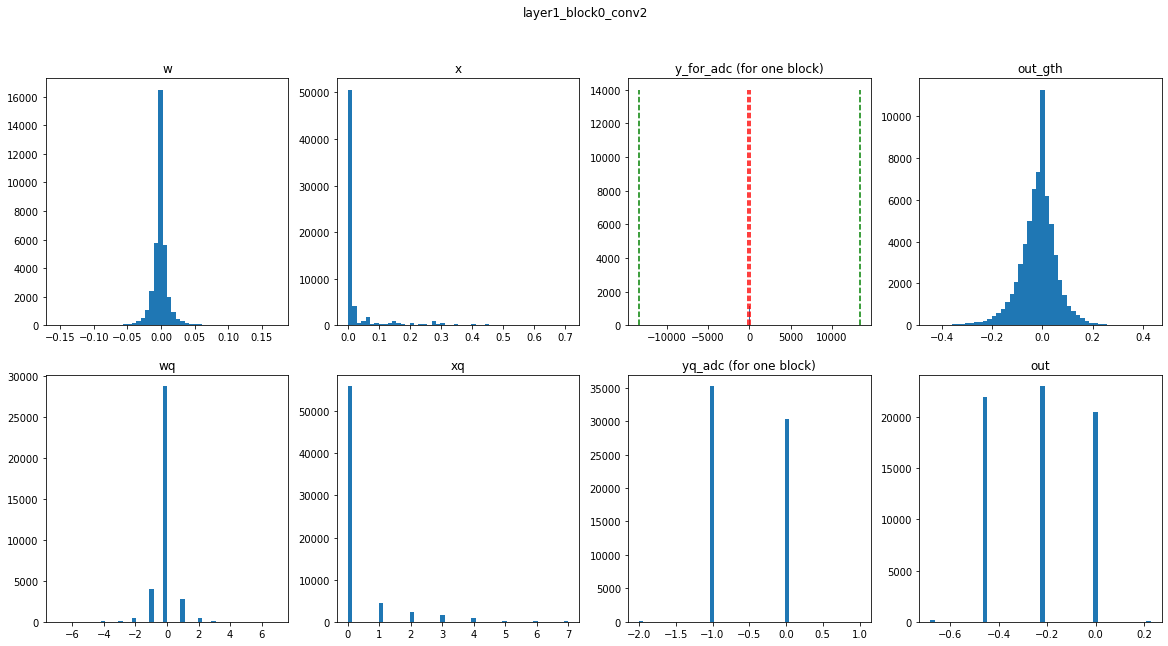

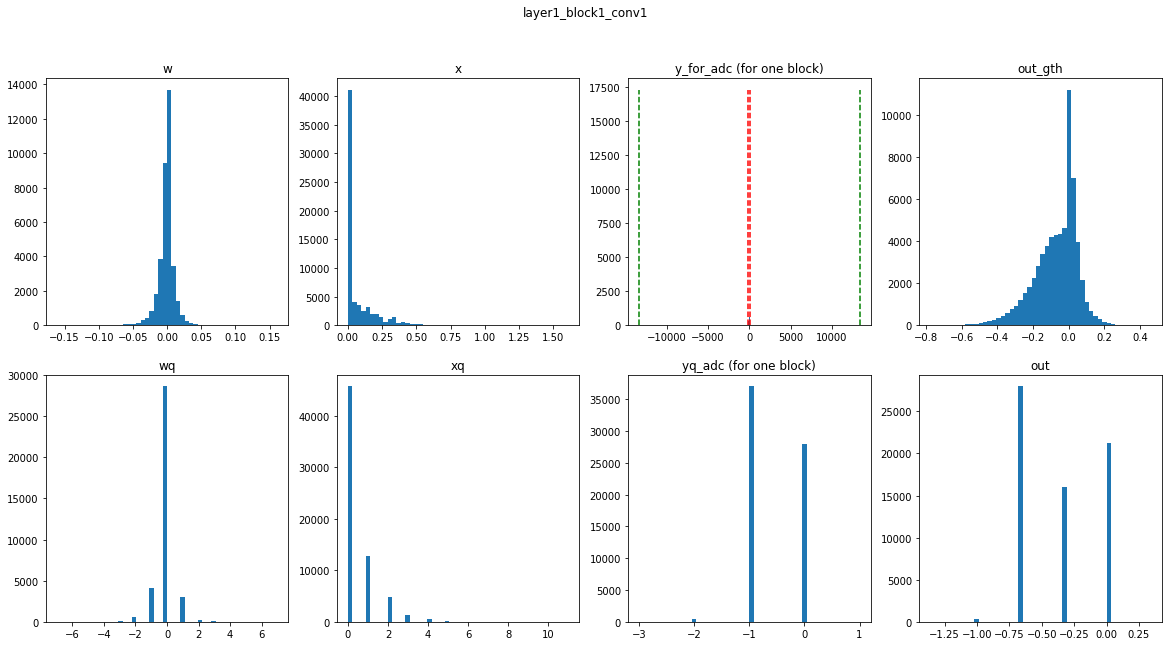

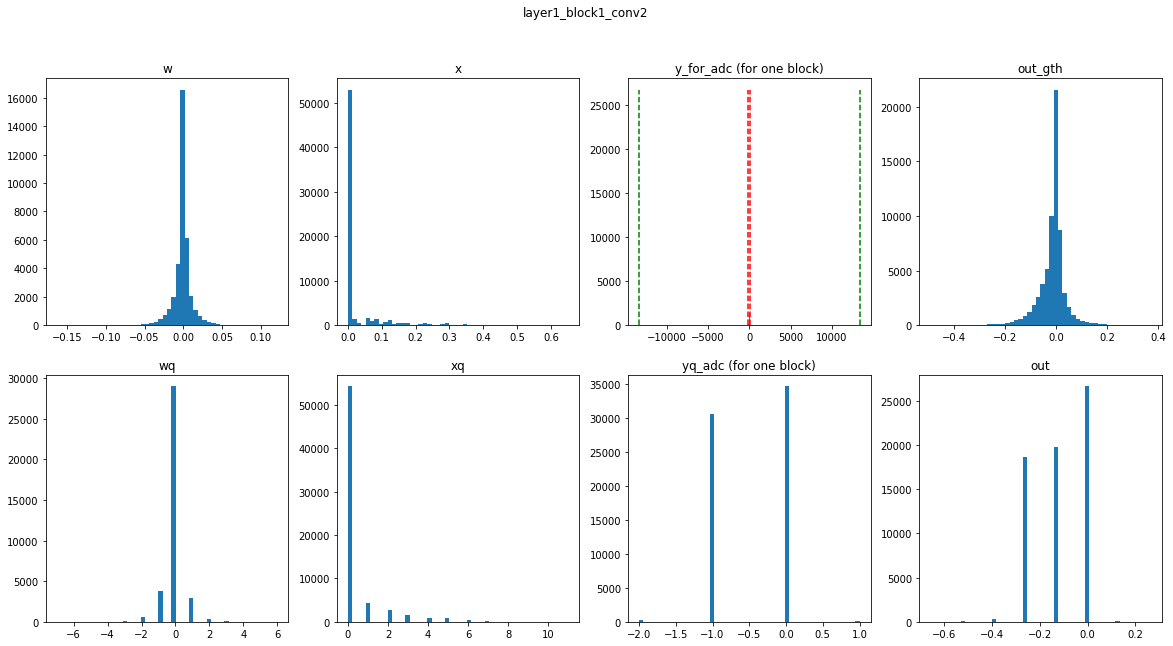

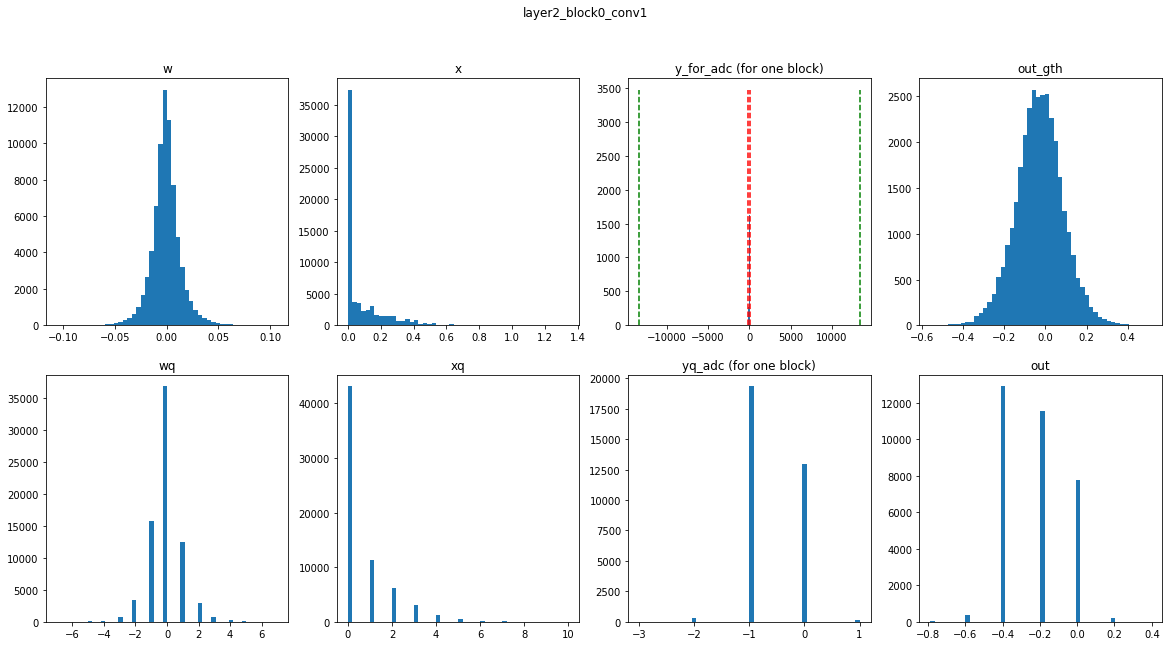

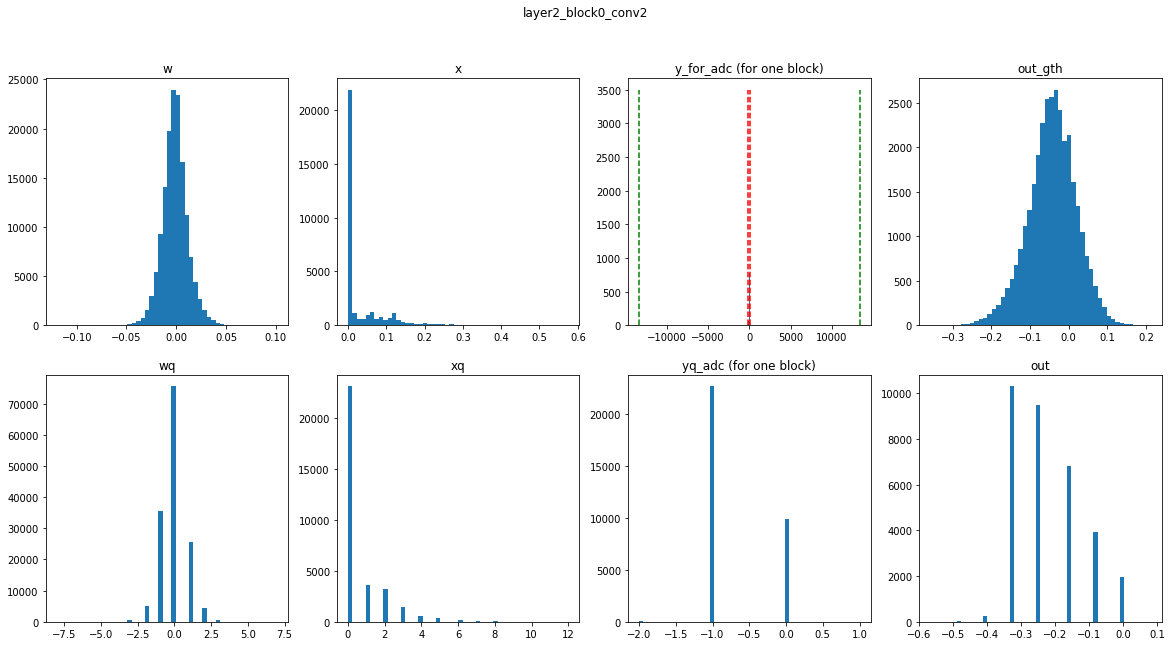

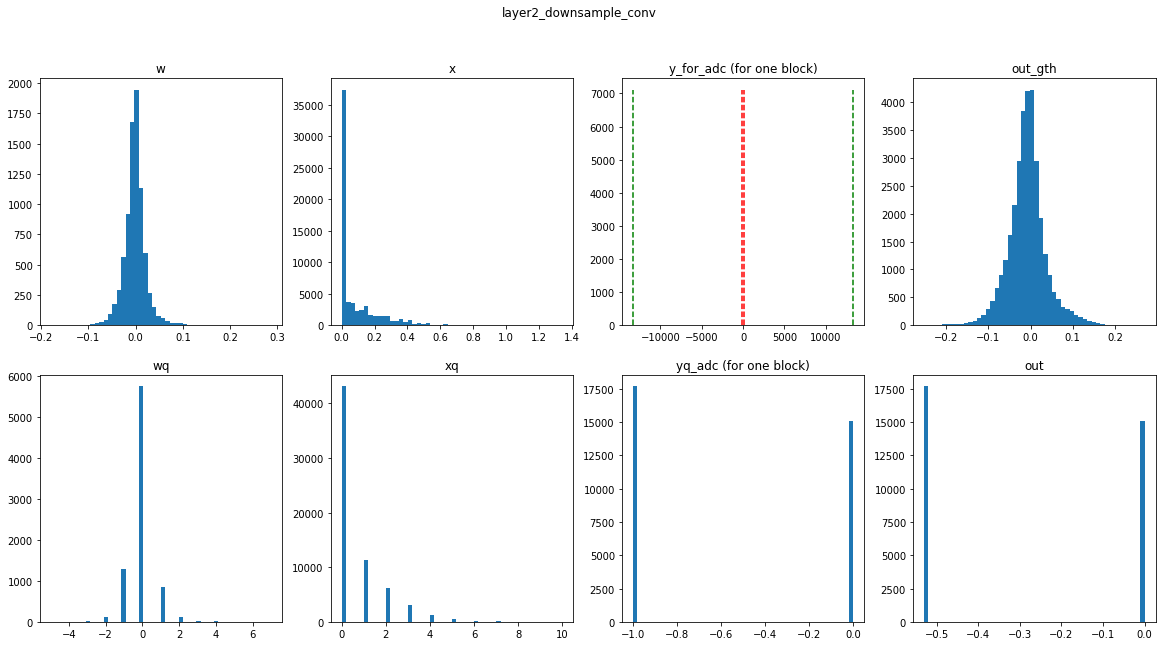

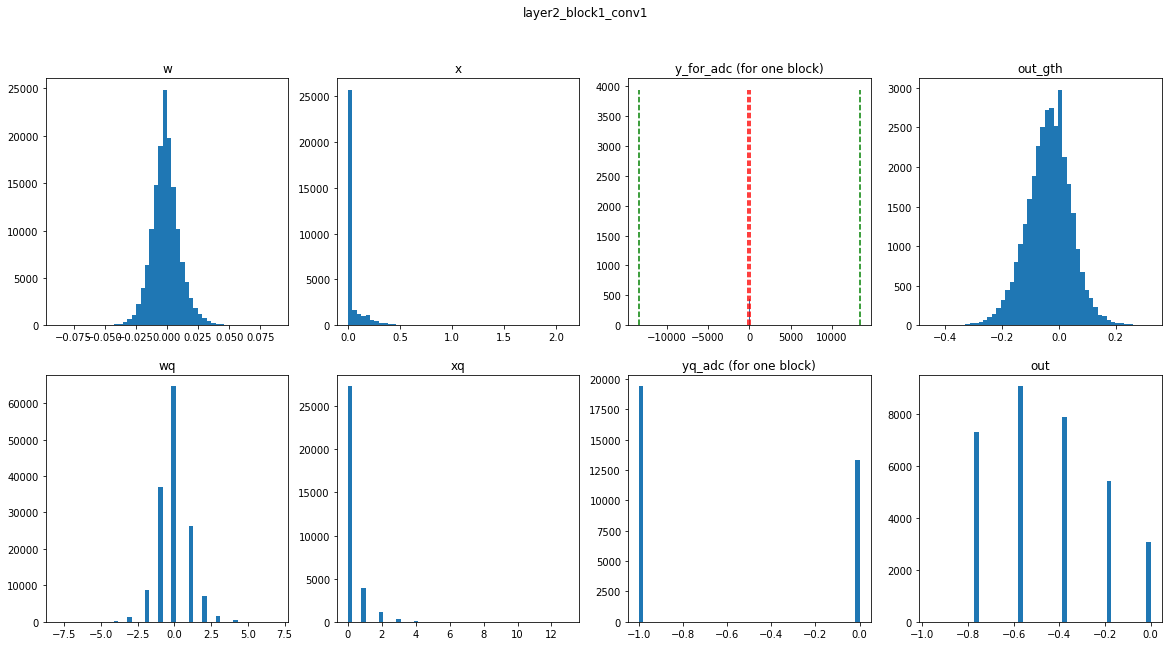

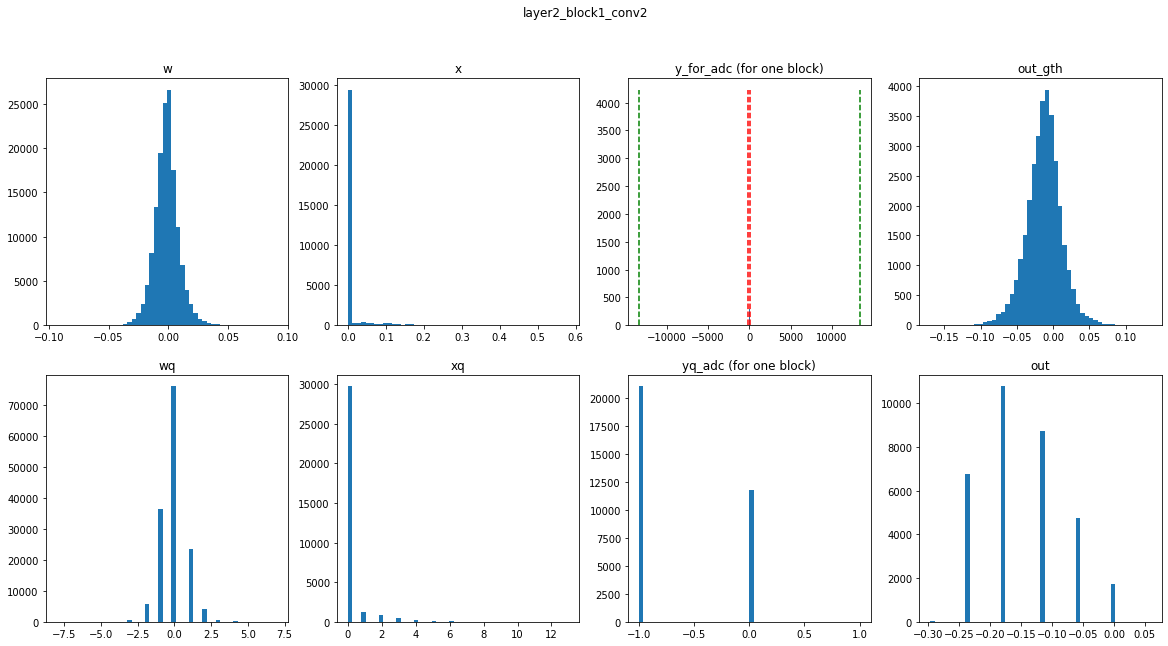

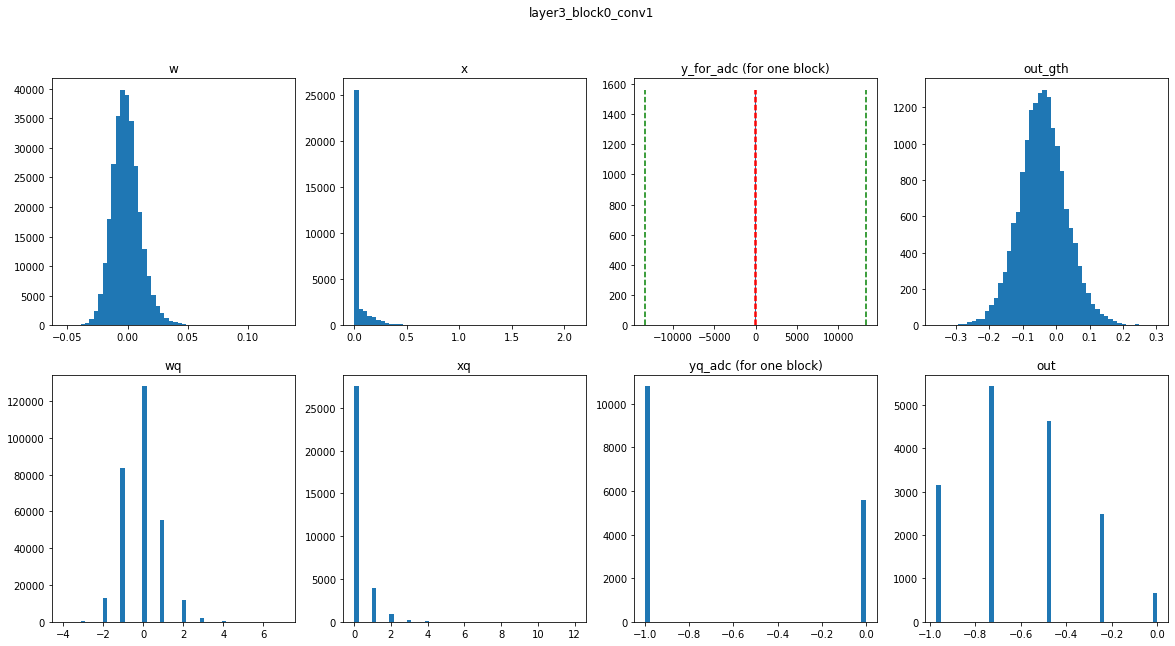

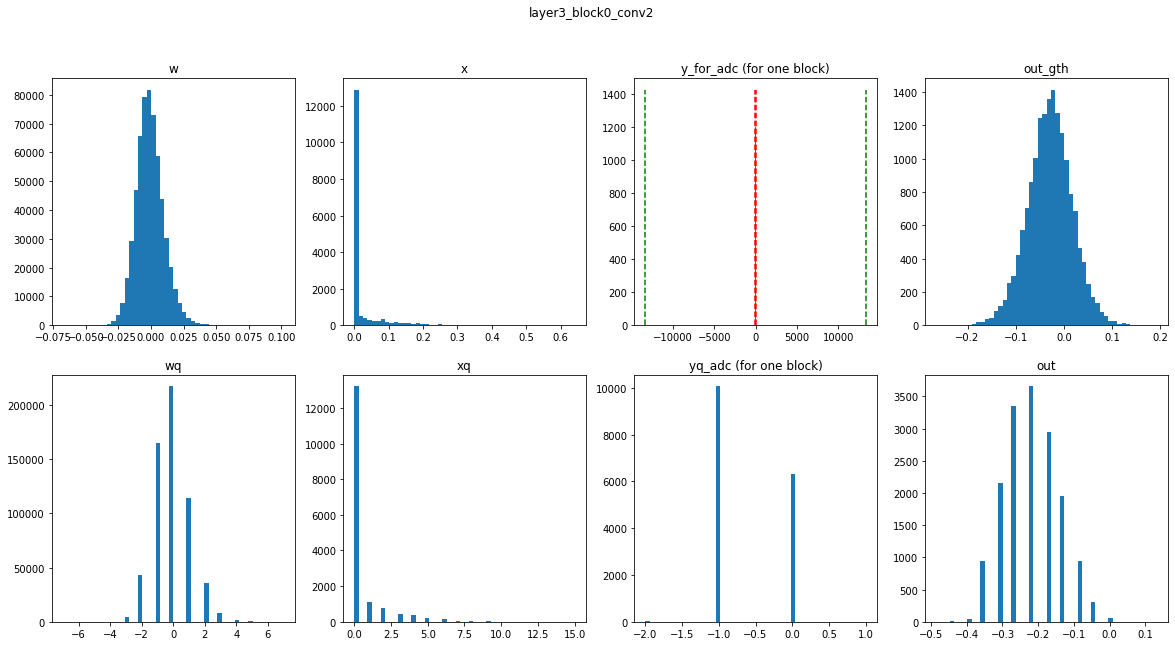

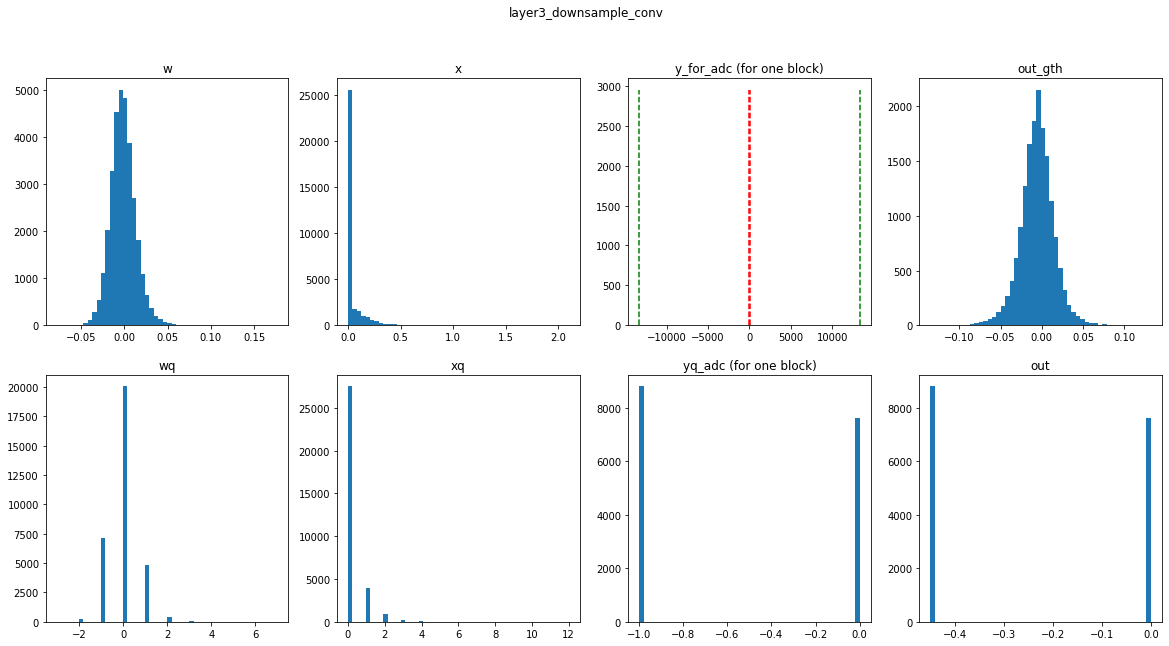

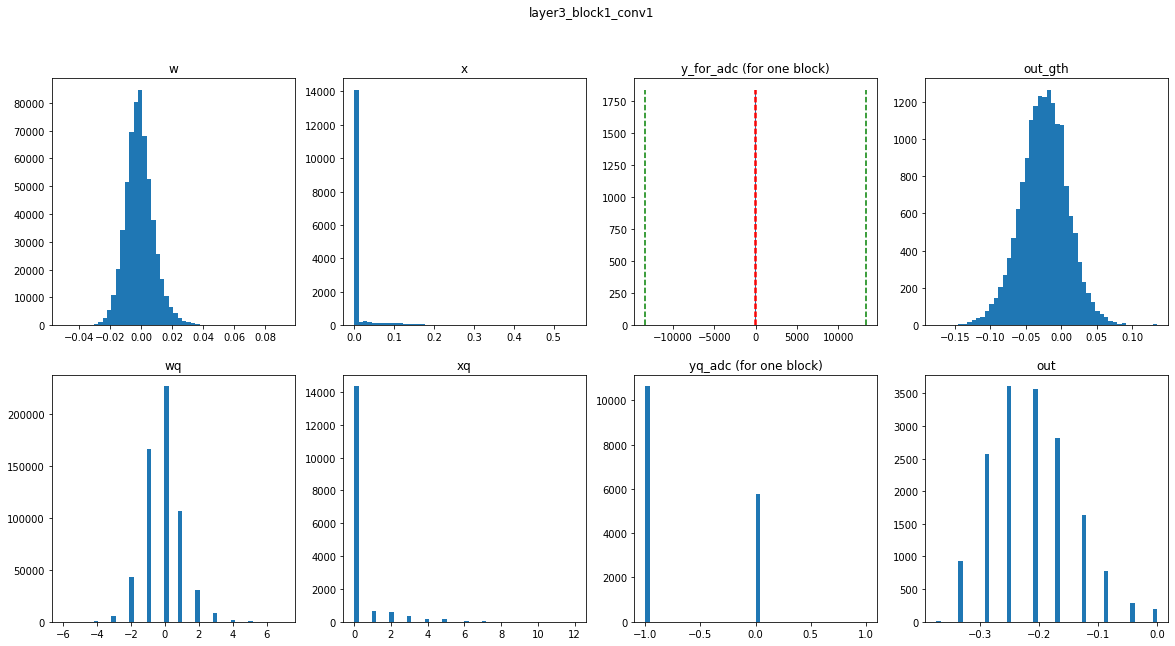

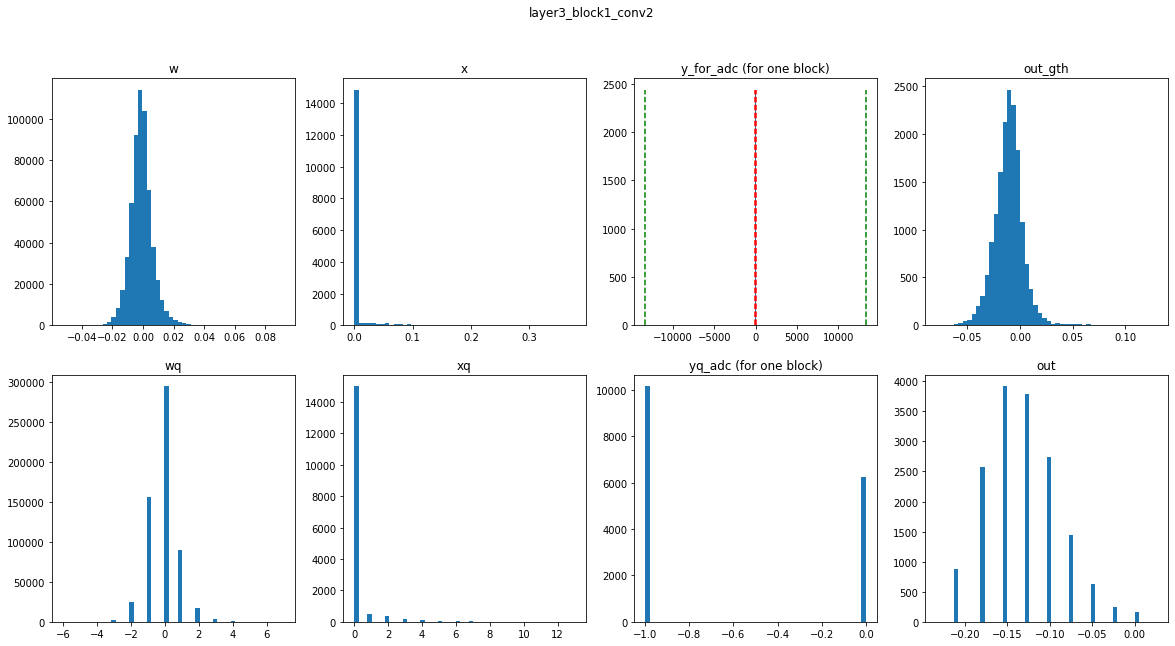

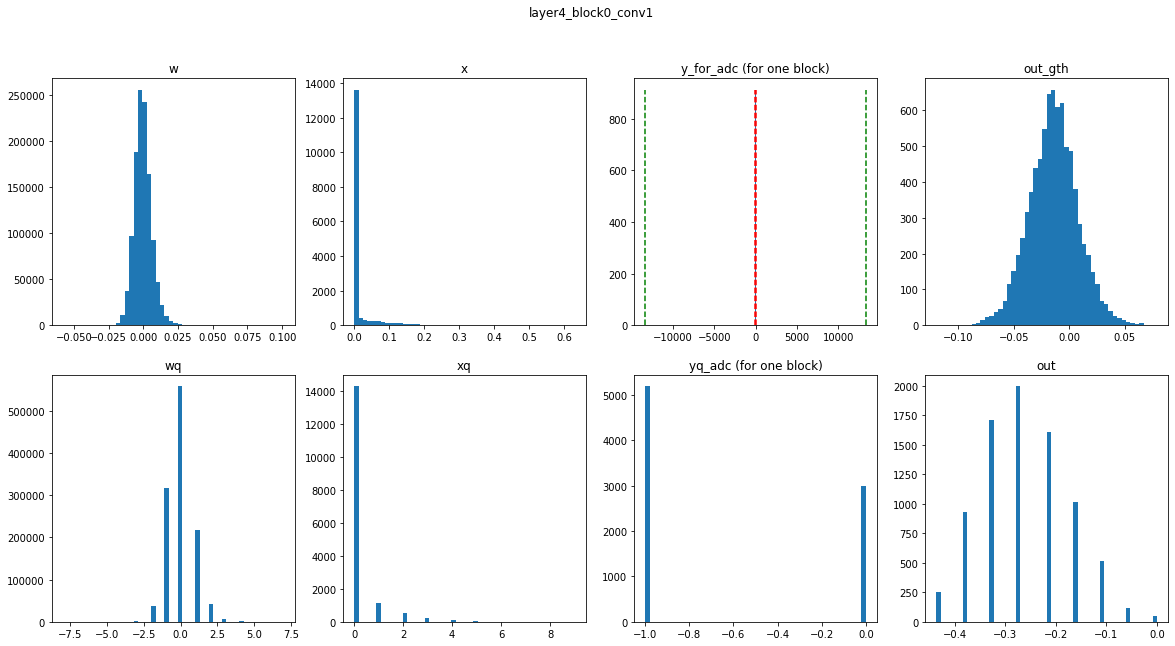

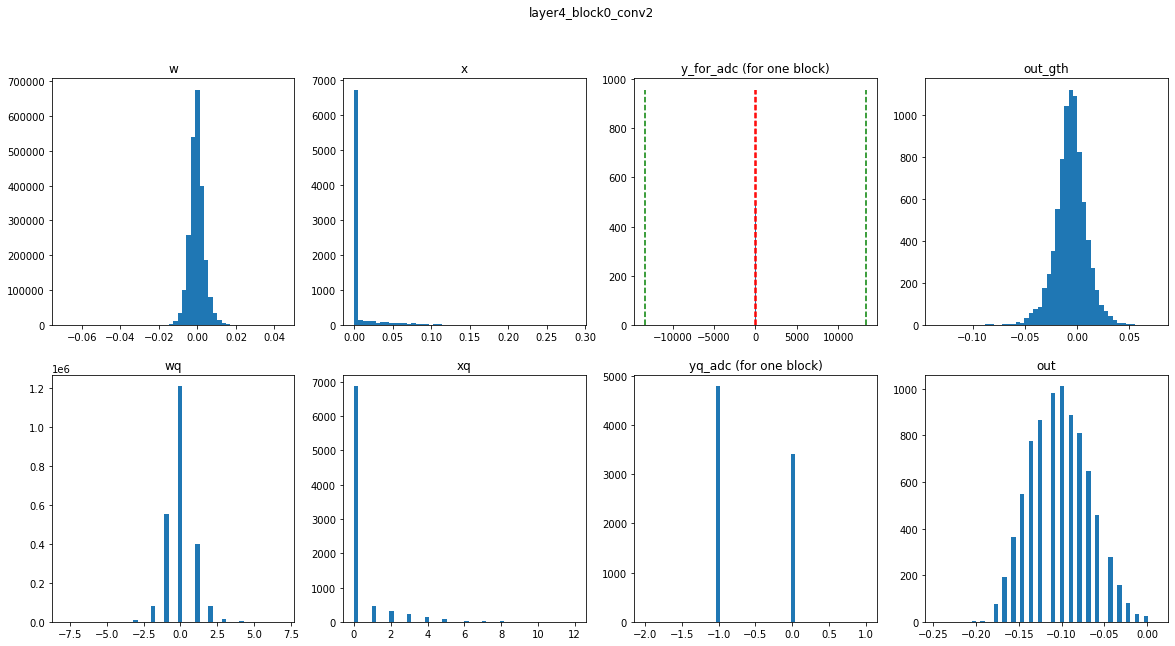

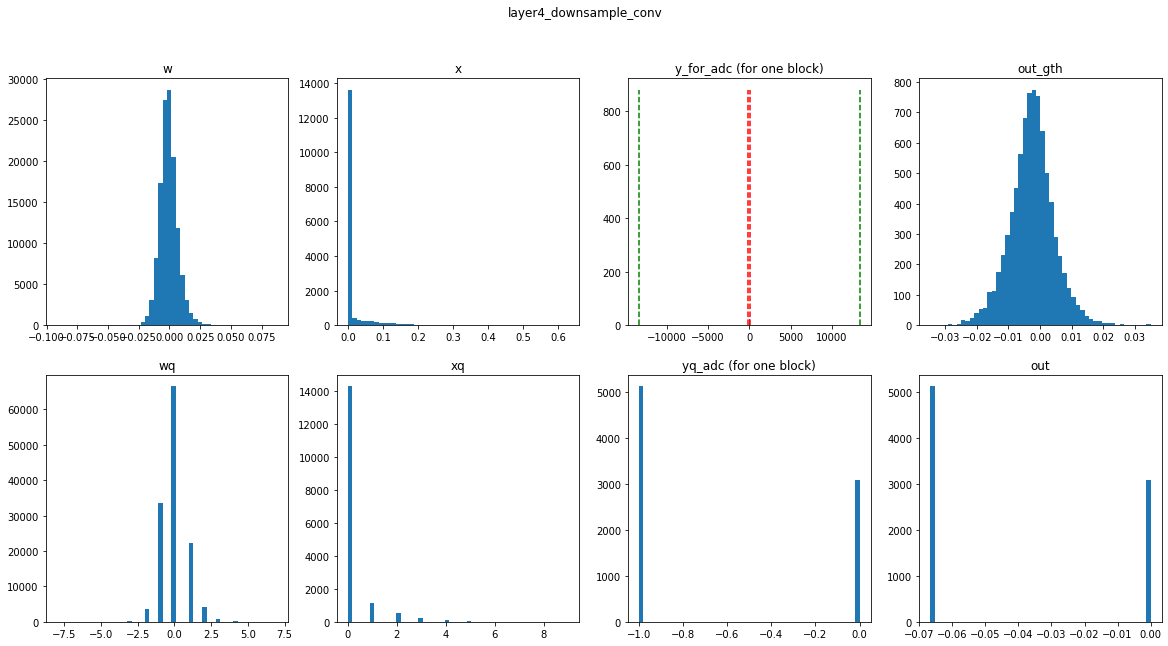

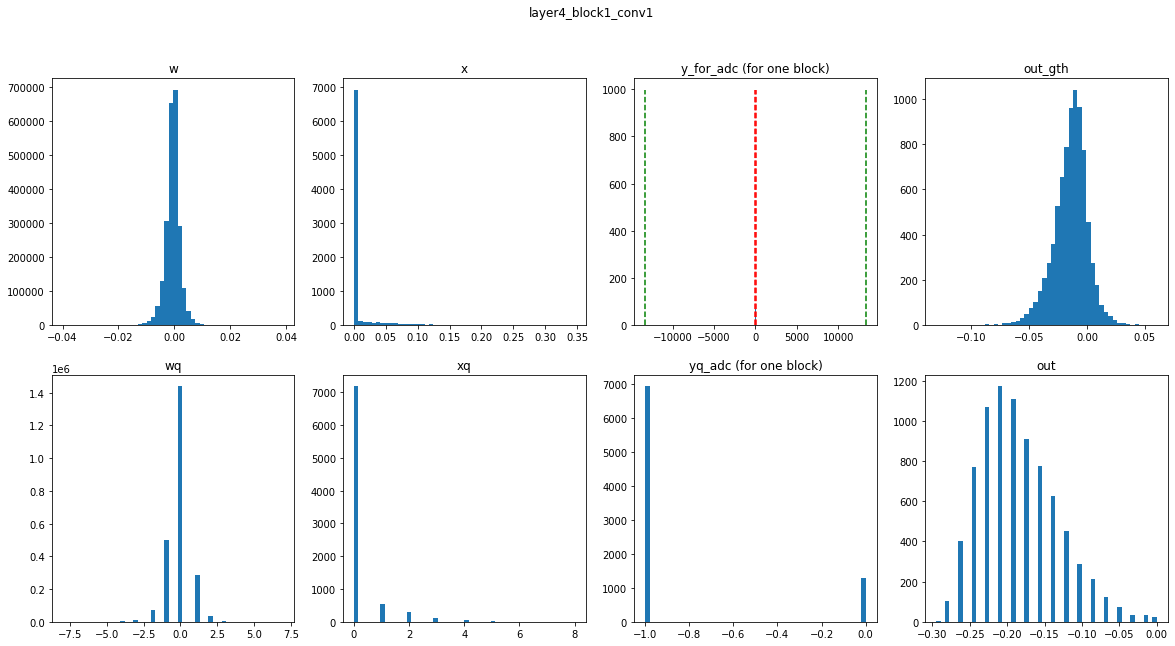

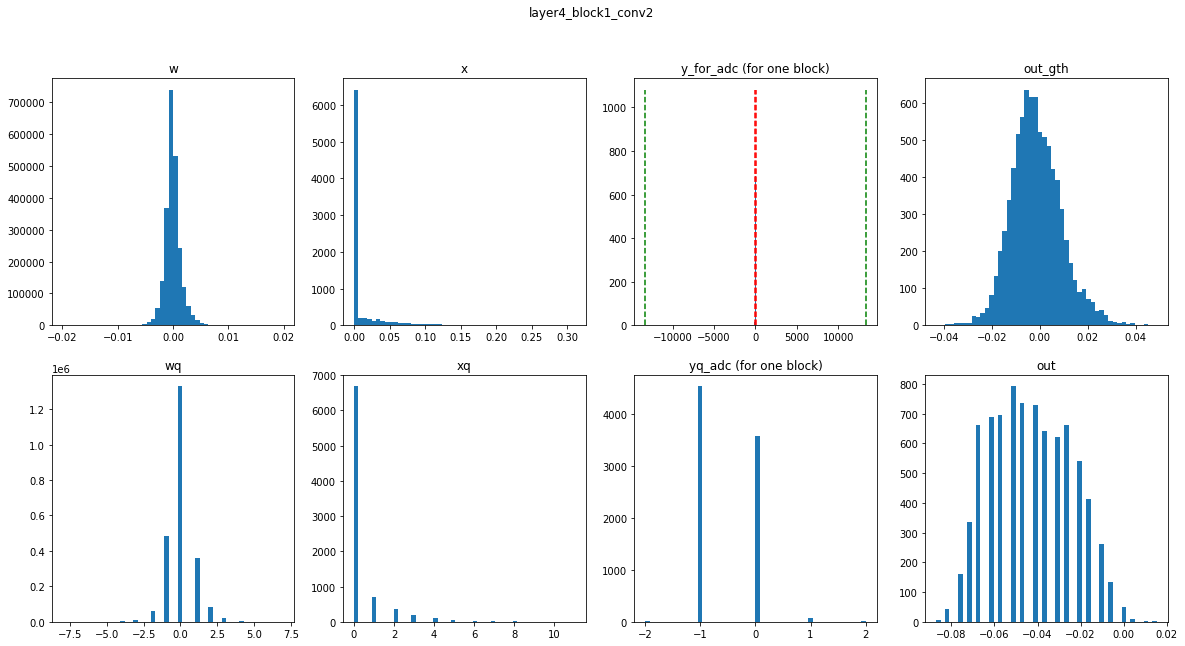

In [86]:
for name in stats0.keys():
    draw_layer_stats(stats0, name)
    plt.show()

##### Model with W-reshape layers

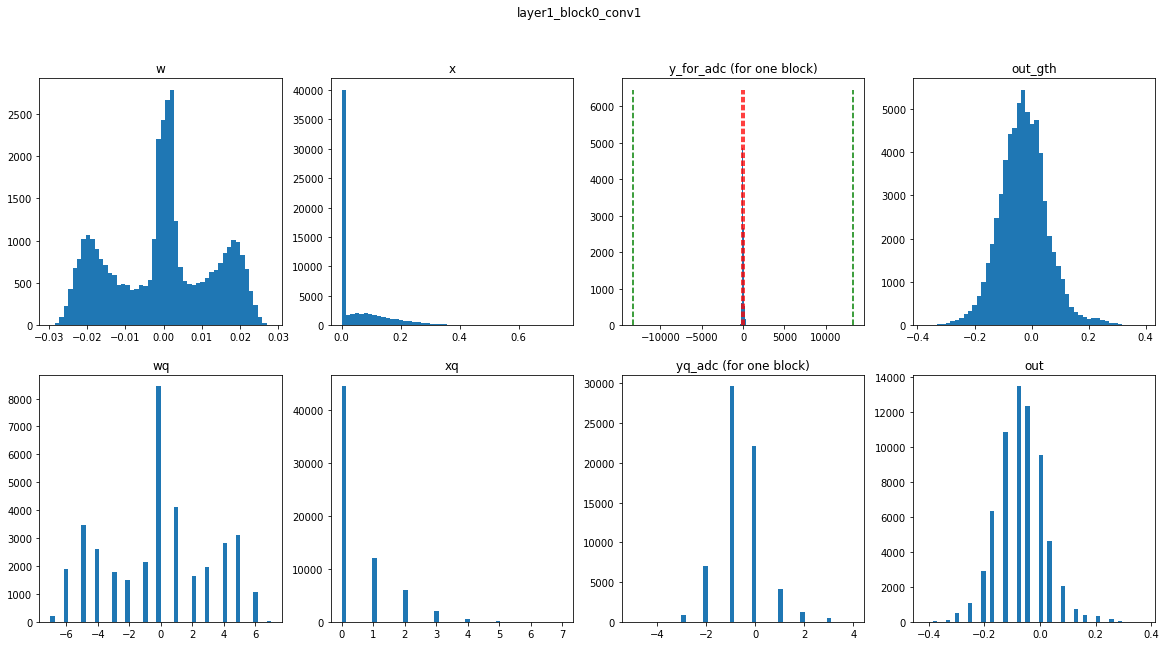

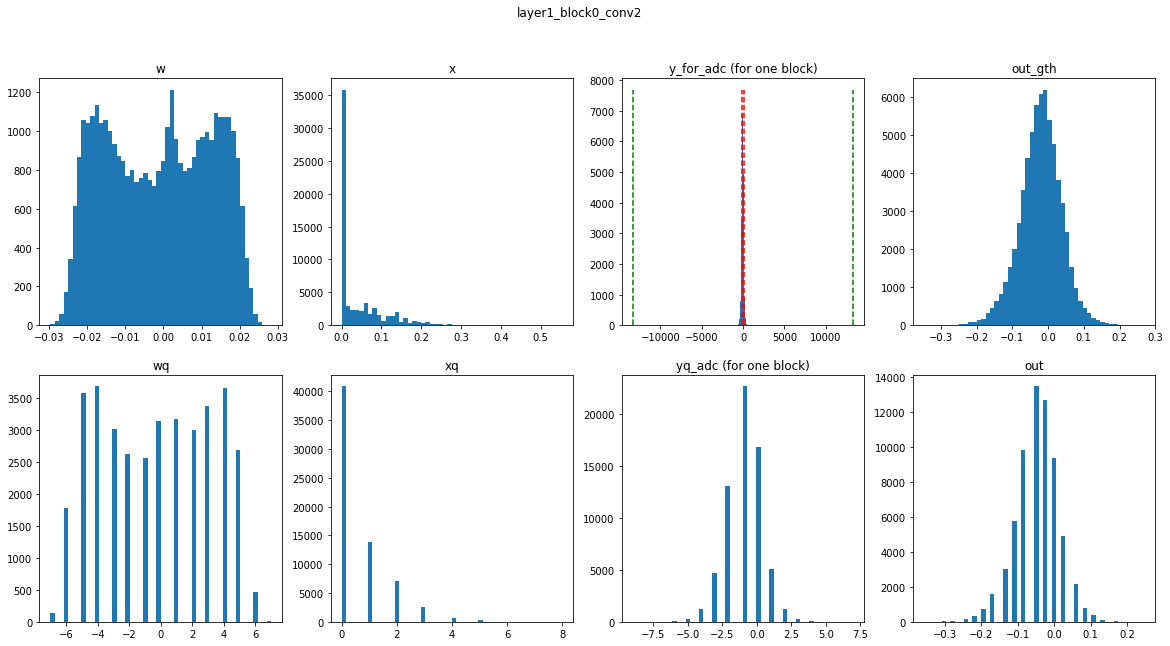

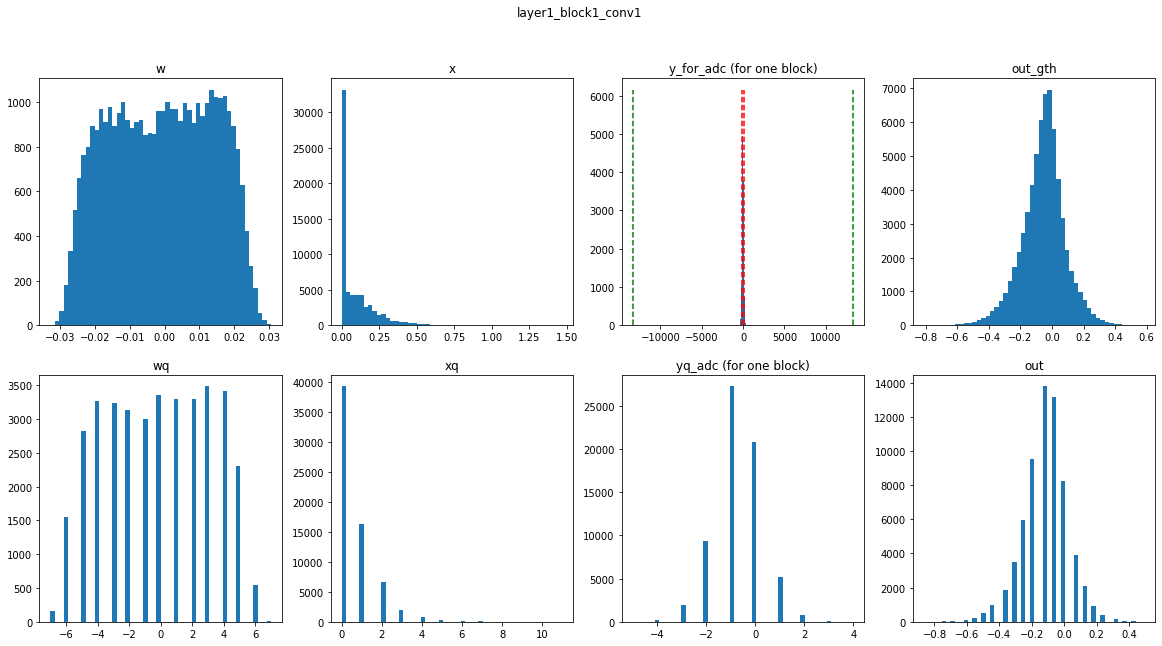

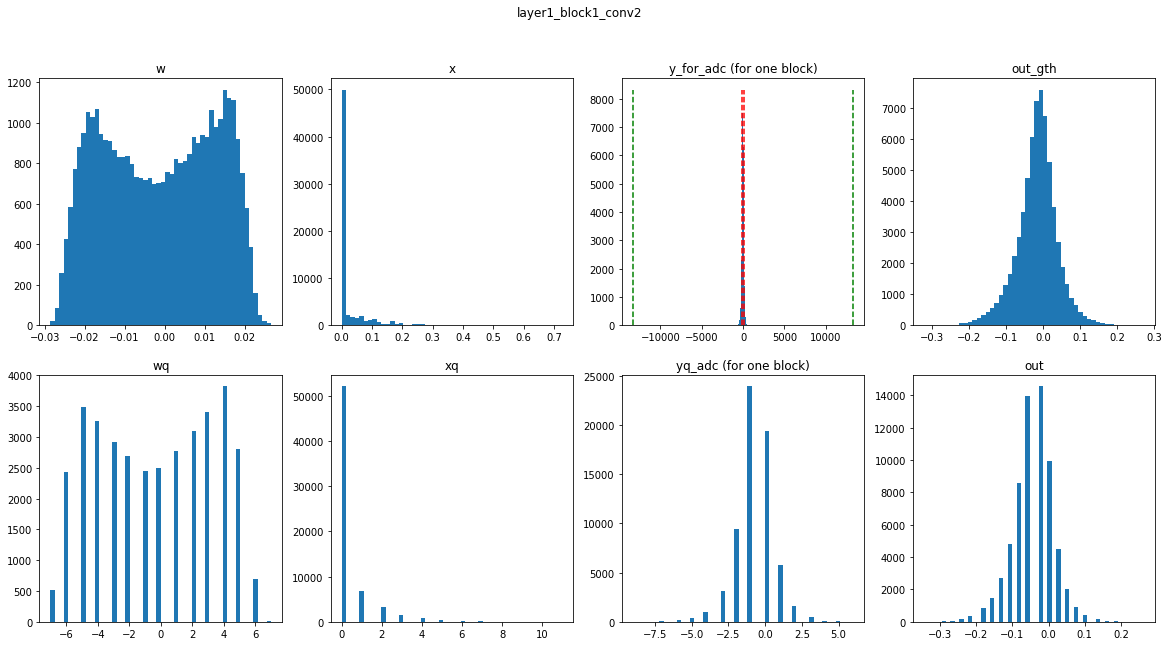

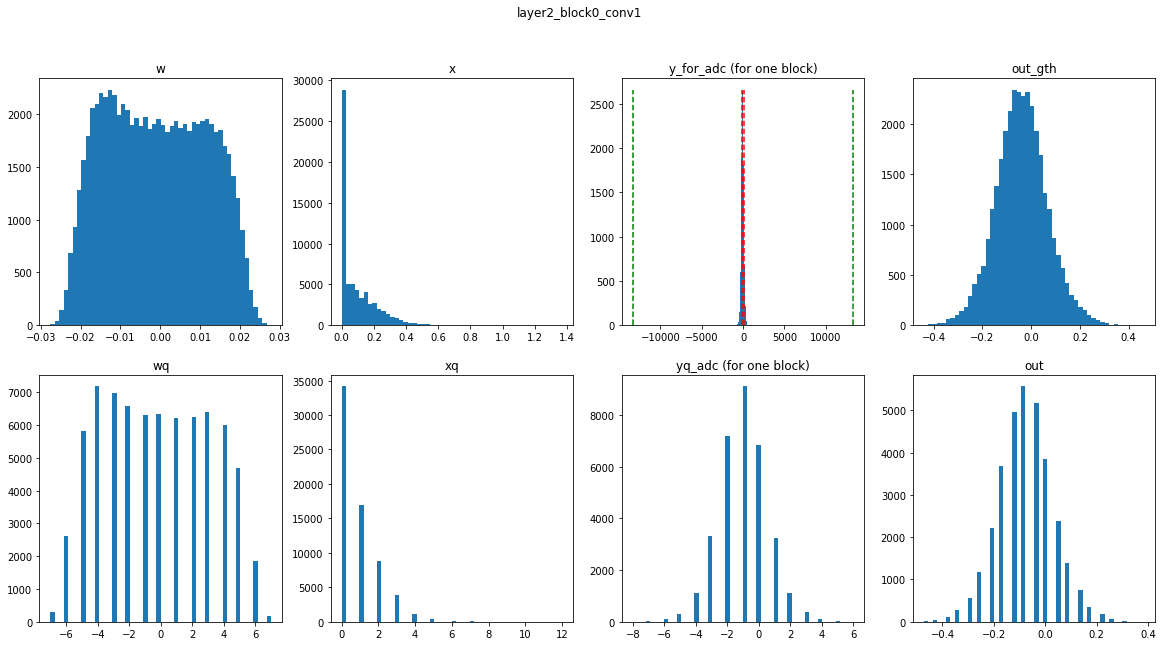

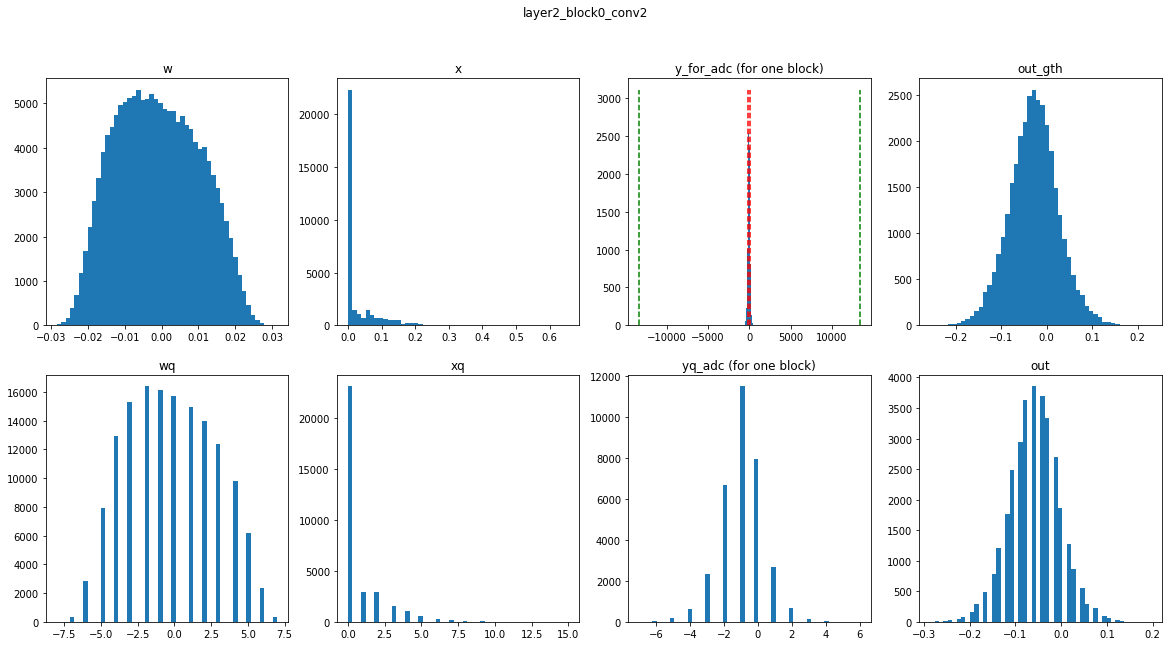

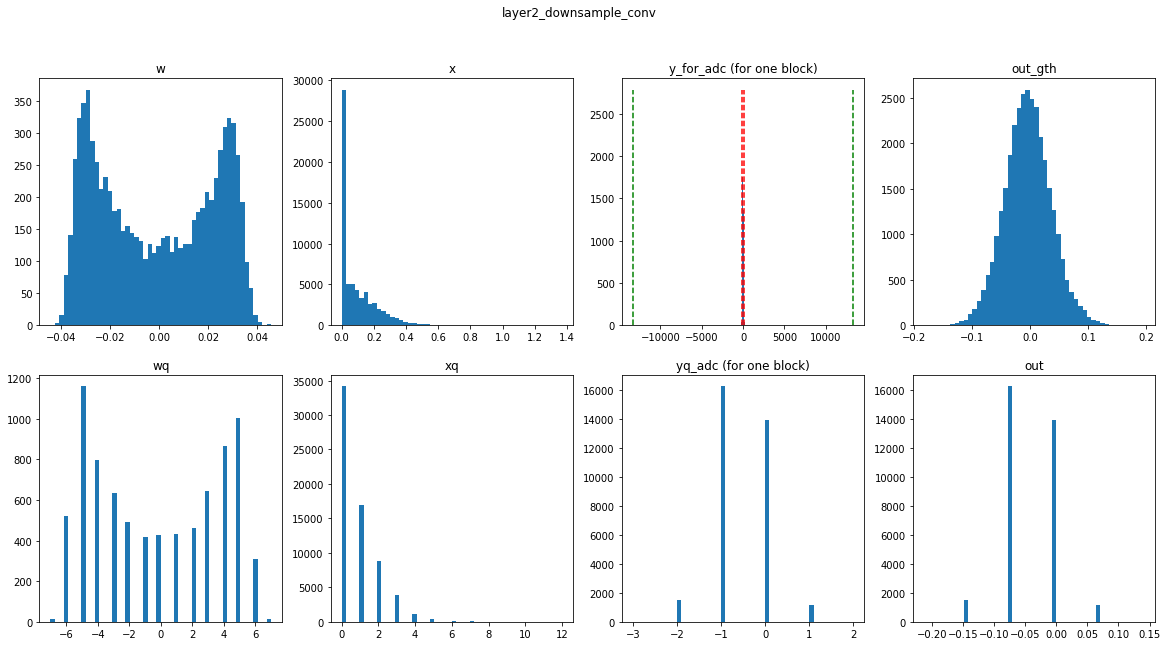

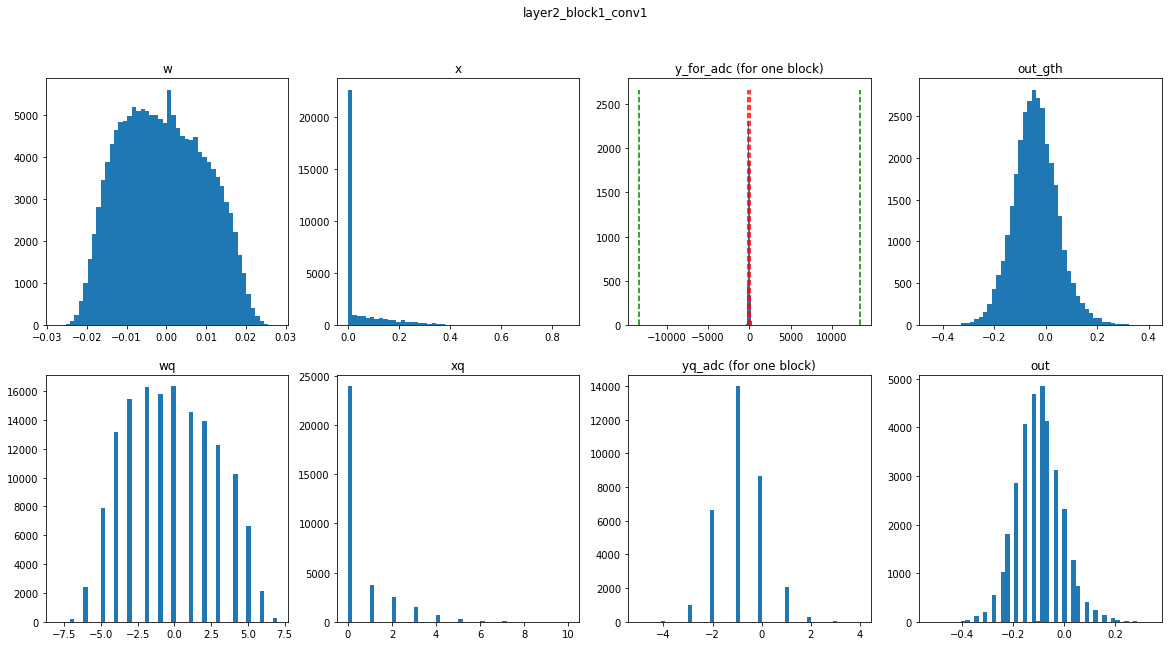

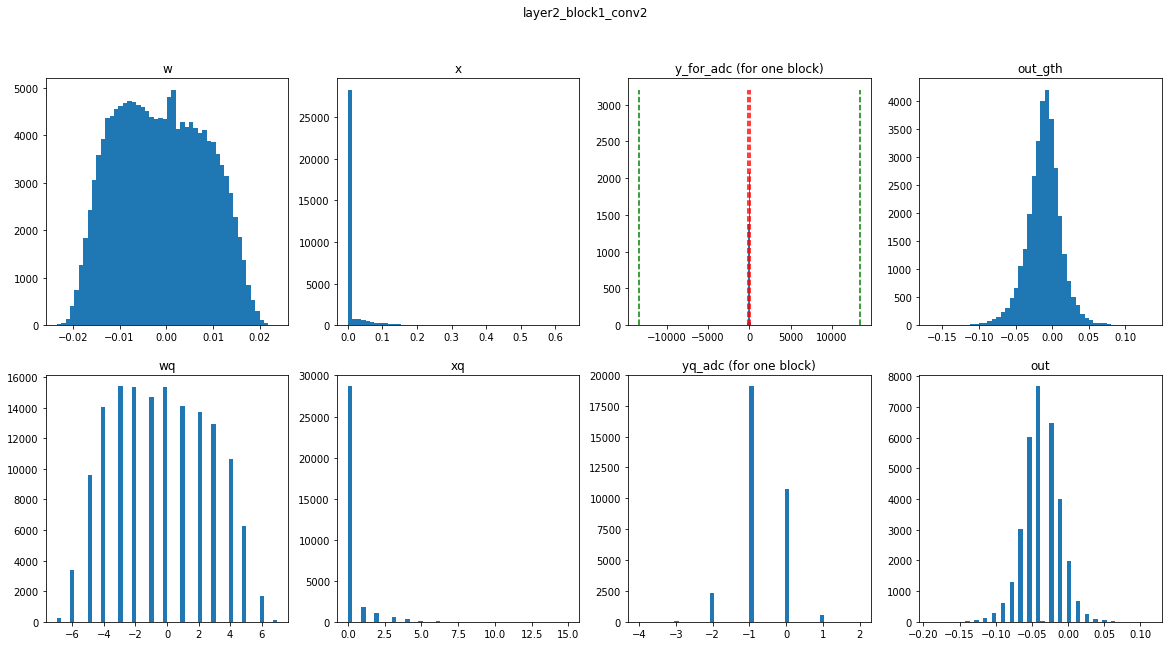

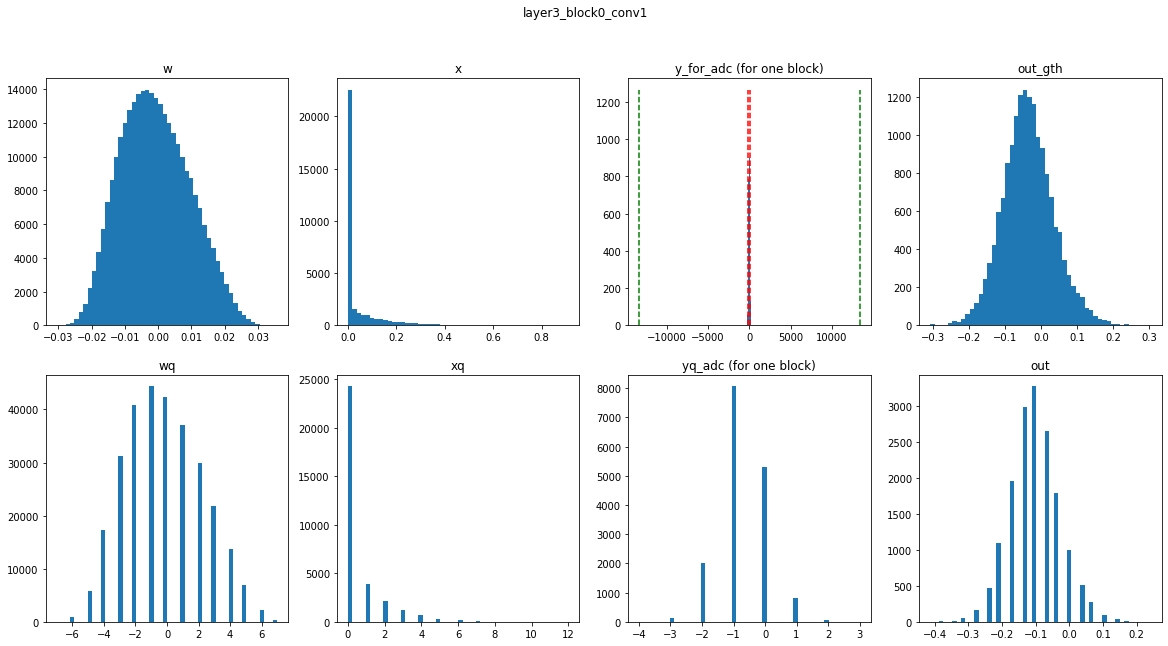

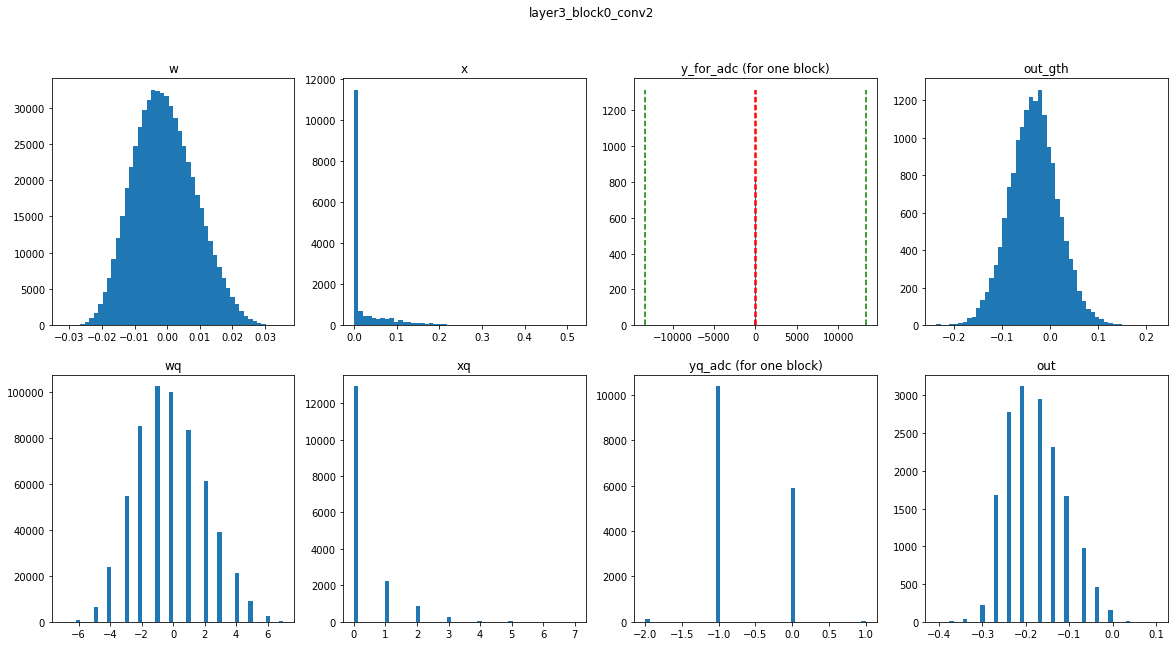

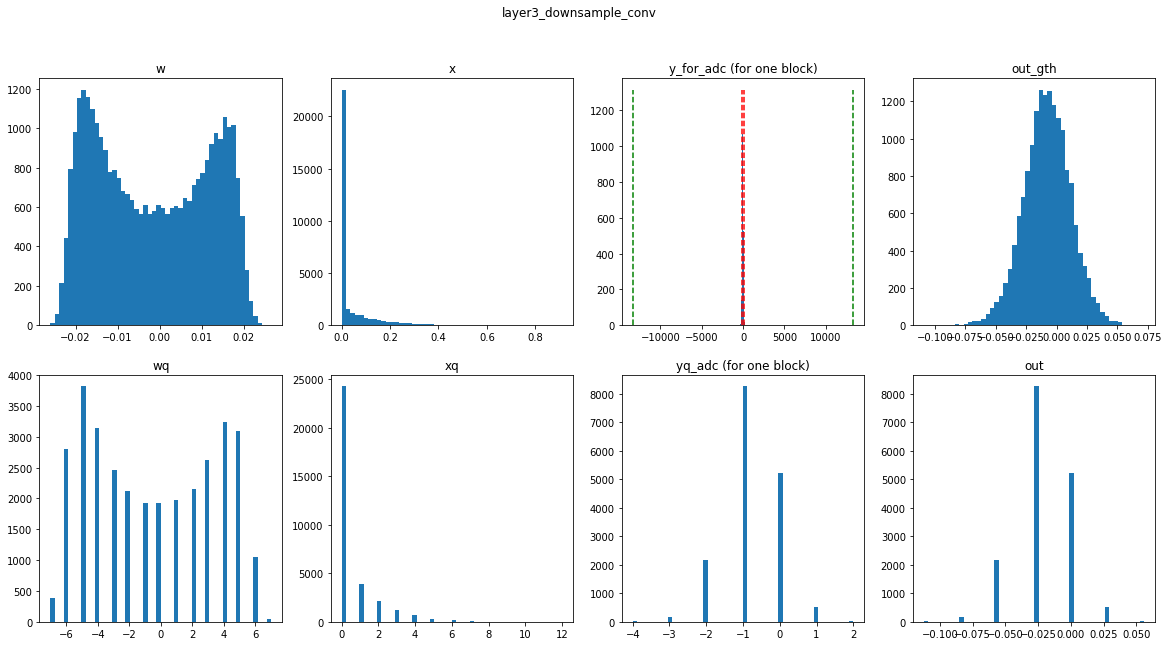

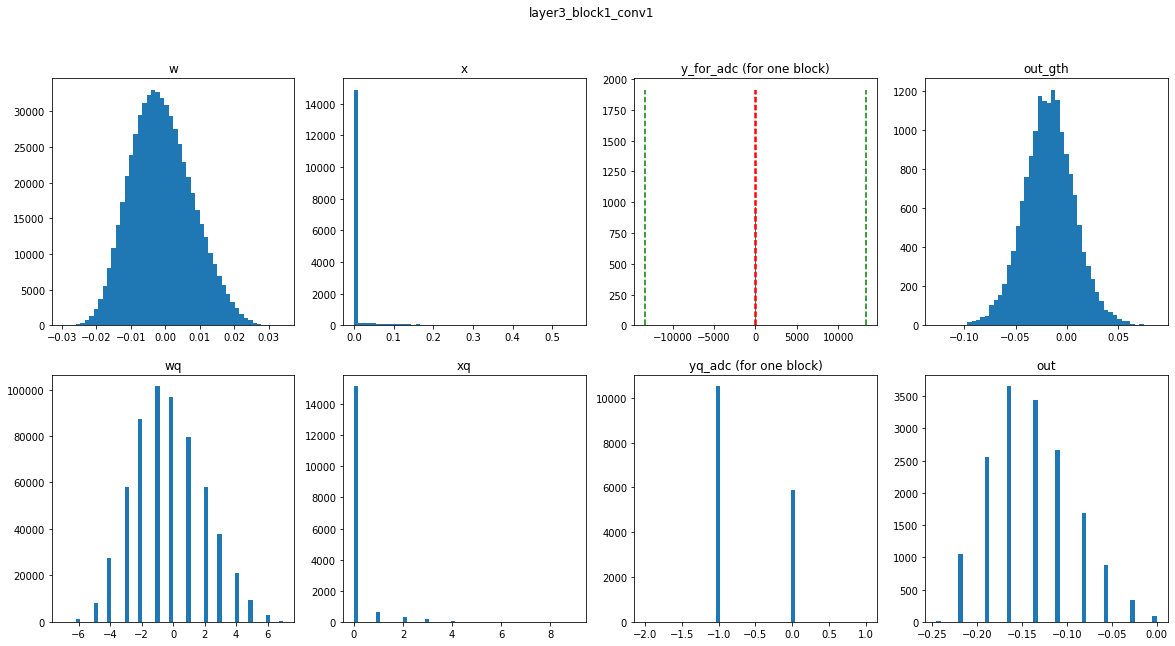

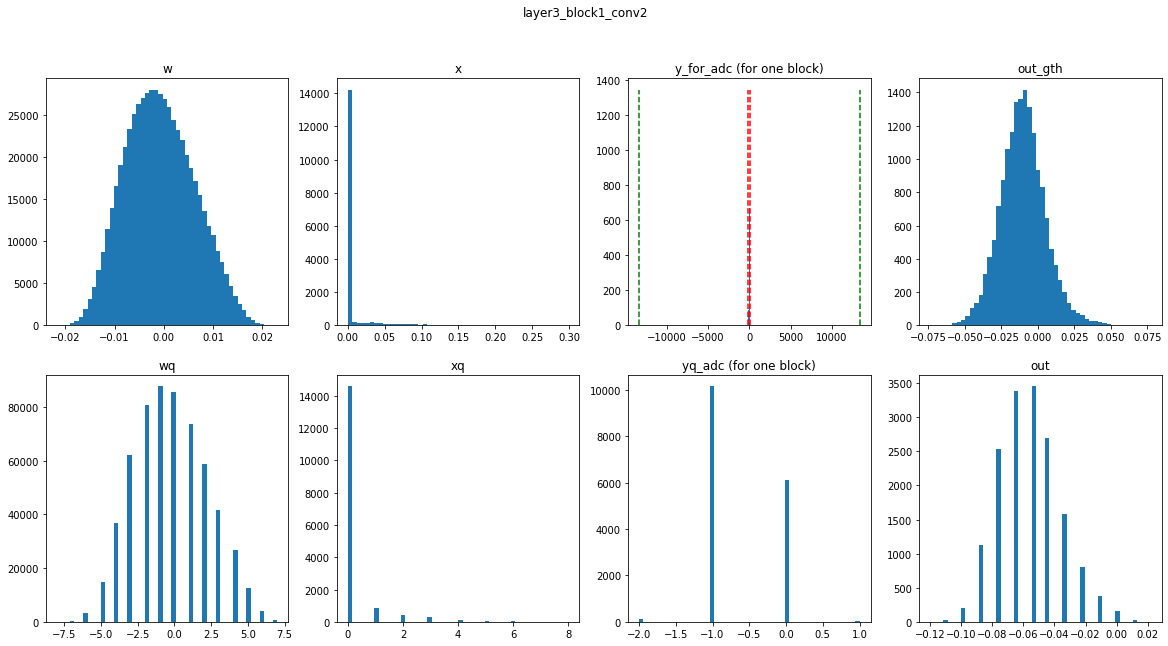

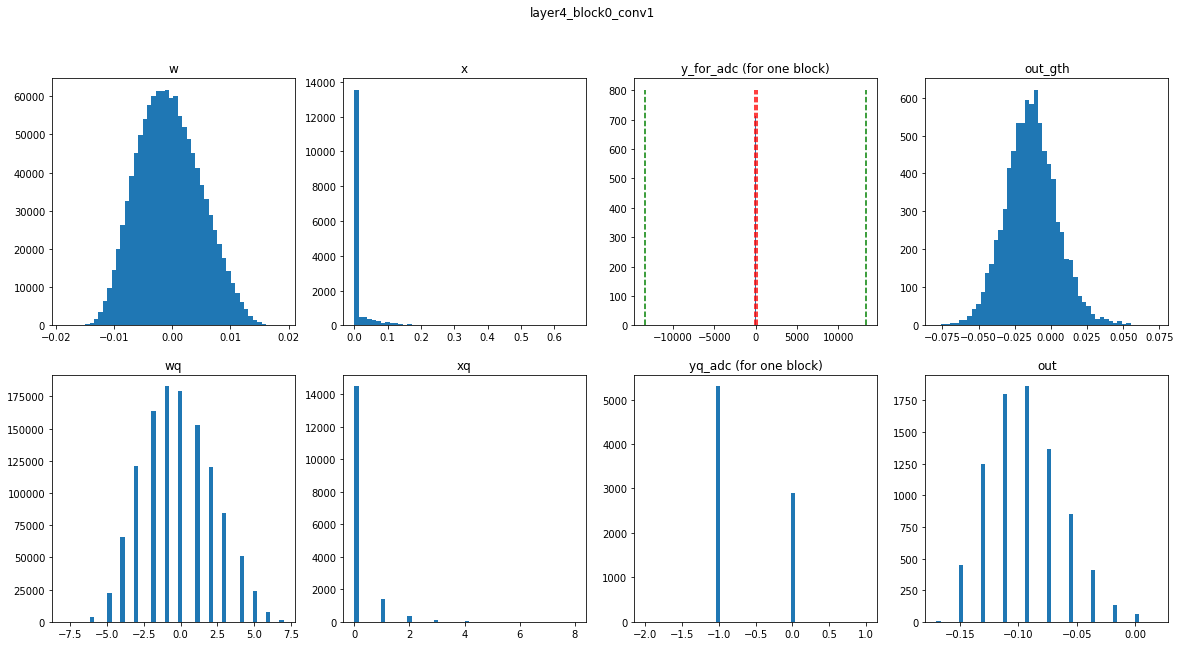

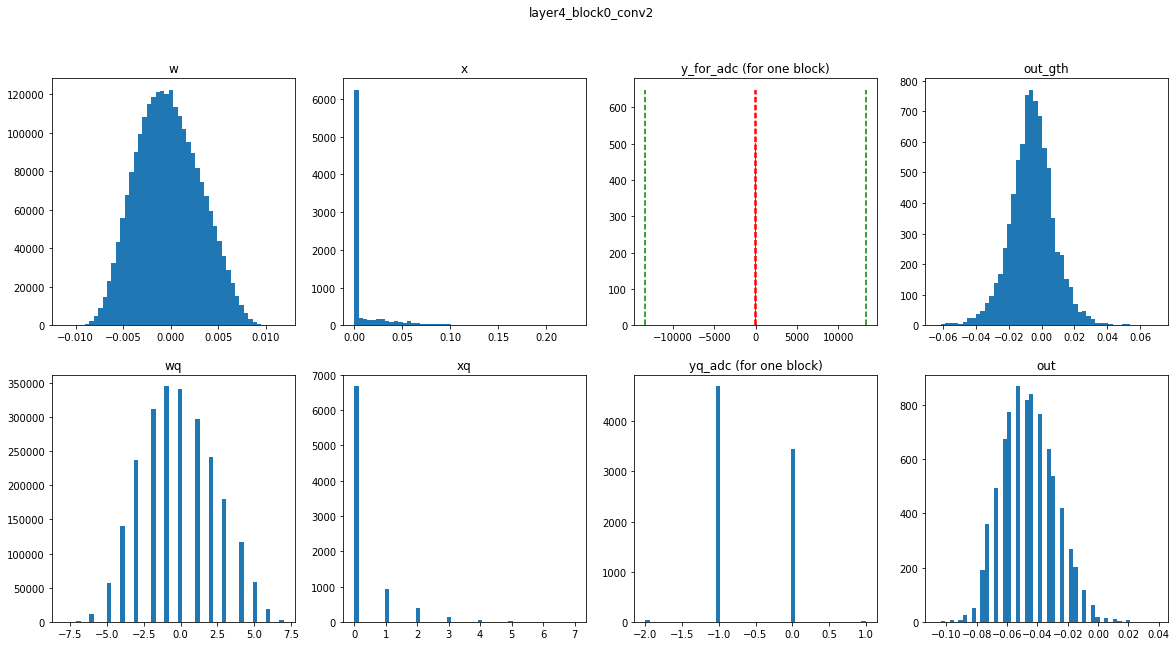

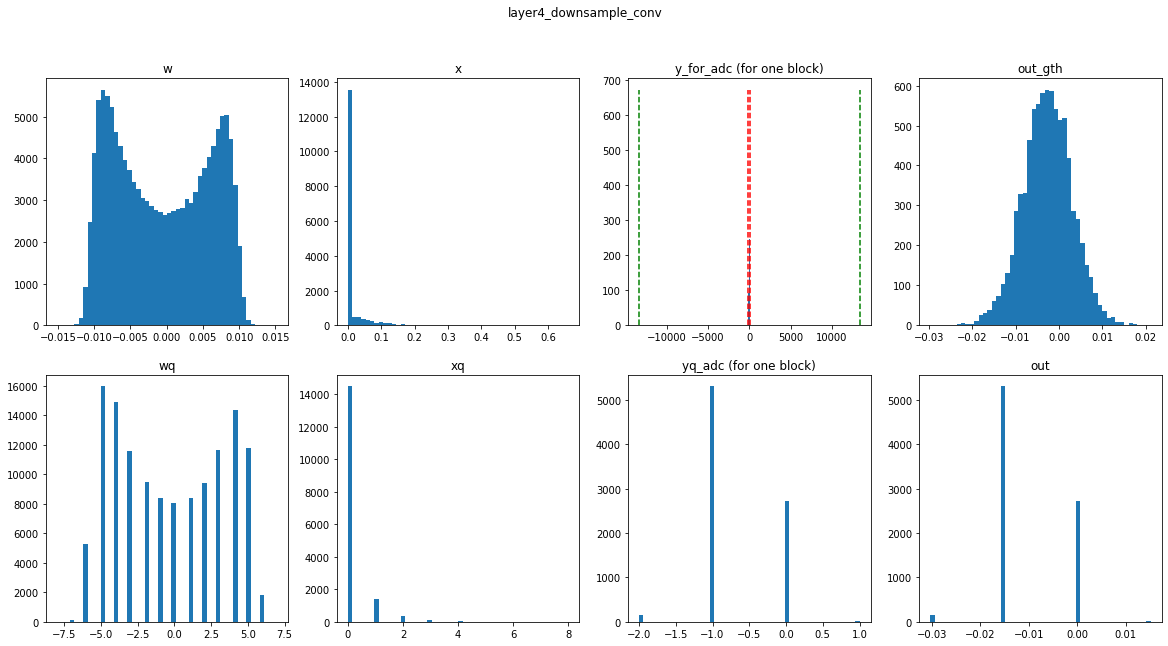

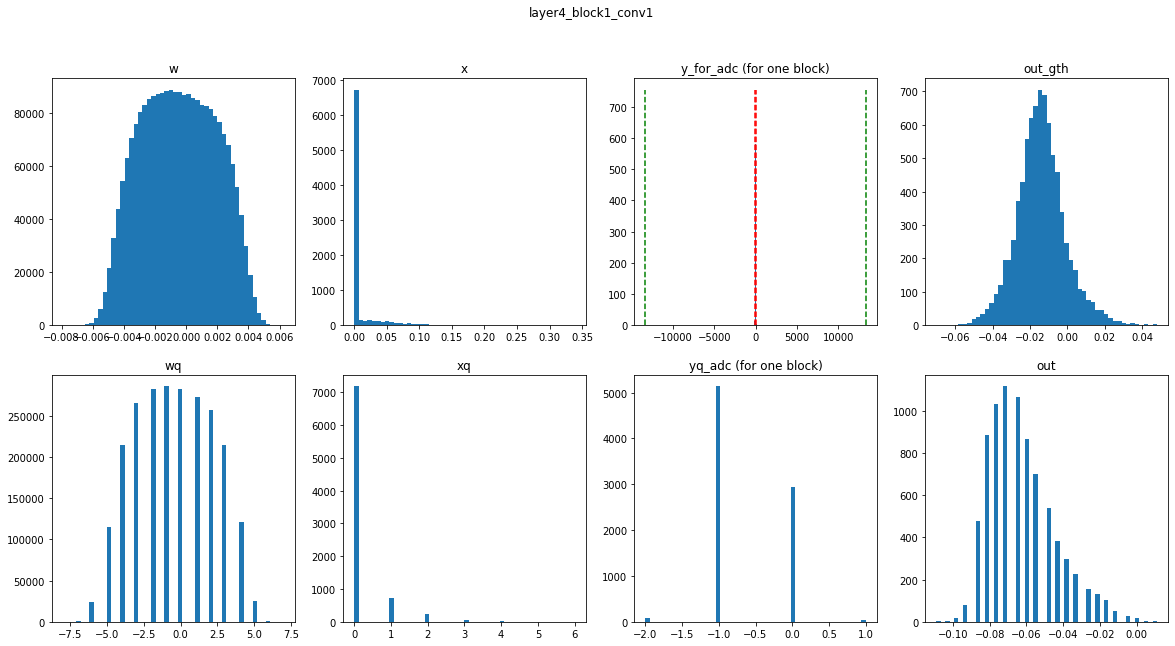

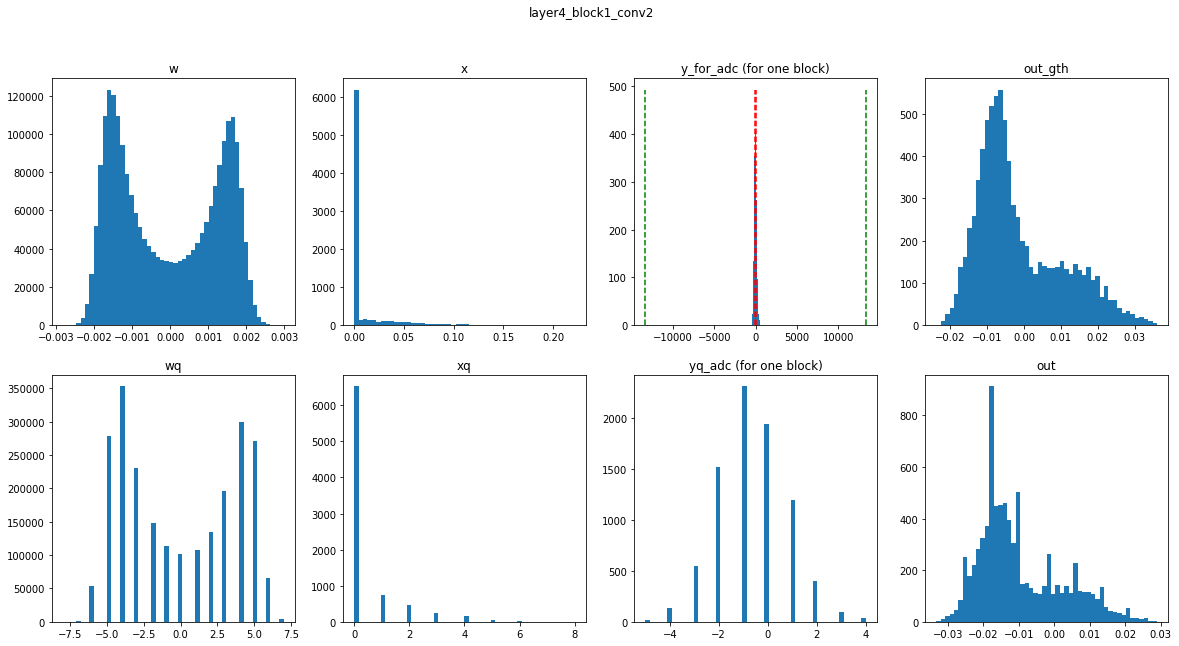

In [85]:
for name in stats.keys():
    draw_layer_stats(stats, name)
    plt.show()

#### Fine-tuning

In [21]:
sc, zp = model_adc.layer1[0].conv1.w_quantizer.observer.calculate_qparams()

In [26]:
def get_quant_params(model):
    params = [p for name, p in model_adc.named_parameters() if name.split('.')[-1] in ['zero_point', 'scale']]
    return params

In [18]:
logger0 = LayerwiseStatsLogger()
logger0.enabled = False


model_adc = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=False, logger=logger0, conv_type=BlockedConv2dADC)
model_adc.load_state_dict(torch.load('/home/coder/project/resnet18-wreshape-5e-4-st.pth'), strict=False)
model_adc = model_adc.to(device)
#calibrate_model(model_adc, train_loader, device, 0.2)
#evaluate_model(model_adc, test_loader)

In [39]:
logger1 = LayerwiseStatsLogger()
logger1.enabled = False


model_adc1 = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=True, logger=logger1, conv_type=BlockedConv2dADC)
model_adc1.load_state_dict(torch.load('/home/coder/project/resnet18-wreshape-5e-4-st.pth'), strict=False)
model_adc1 = model_adc1.to(device)
#calibrate_model(model_adc, train_loader, device, 0.2)
#evaluate_model(model_adc, test_loader)

In [19]:
calibrate_model3(model_adc, train_loader, device, 0.2)

Calibrating quantizers...
Calibrating weight quantizers...

conv1
conv1.x_quantizer
conv1.x_quantizer.observer
conv1.w_quantizer
conv1.w_quantizer.observer
conv1.adc_quantizer
bn1
relu
layer1
layer1.0
layer1.0.conv1
layer1.0.conv1.x_quantizer
layer1.0.conv1.x_quantizer.observer
layer1.0.conv1.w_quantizer
layer1.0.conv1.w_quantizer.observer
layer1.0.conv1.adc_quantizer
layer1.0.bn1
layer1.0.conv2
layer1.0.conv2.x_quantizer
layer1.0.conv2.x_quantizer.observer
layer1.0.conv2.w_quantizer
layer1.0.conv2.w_quantizer.observer
layer1.0.conv2.adc_quantizer
layer1.0.bn2
layer1.0.relu
layer1.1
layer1.1.conv1
layer1.1.conv1.x_quantizer
layer1.1.conv1.x_quantizer.observer
layer1.1.conv1.w_quantizer
layer1.1.conv1.w_quantizer.observer
layer1.1.conv1.adc_quantizer
layer1.1.bn1
layer1.1.conv2
layer1.1.conv2.x_quantizer
layer1.1.conv2.x_quantizer.observer
layer1.1.conv2.w_quantizer
layer1.1.conv2.w_quantizer.observer
layer1.1.conv2.adc_quantizer
layer1.1.bn2
layer1.1.relu
layer2
layer2.0
layer2.0.conv1

Calibration done. Quantizer observers are now disabled.


In [20]:
evaluate_model(model_adc, test_loader)

Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.72it/s]


(92.55, 0.26393796424865723)

In [40]:
calibrate_model3(model_adc1, train_loader, device, 0.2)

Calibrating quantizers...
Calibrating weight quantizers...

conv1
conv1.x_quantizer
conv1.x_quantizer.observer
conv1.w_quantizer
conv1.w_quantizer.observer
conv1.adc_quantizer
bn1
relu
layer1
layer1.0
layer1.0.conv1
layer1.0.conv1.x_quantizer
layer1.0.conv1.x_quantizer.observer
layer1.0.conv1.w_quantizer
layer1.0.conv1.w_quantizer.observer
layer1.0.conv1.adc_quantizer
layer1.0.bn1
layer1.0.conv2
layer1.0.conv2.x_quantizer
layer1.0.conv2.x_quantizer.observer
layer1.0.conv2.w_quantizer
layer1.0.conv2.w_quantizer.observer
layer1.0.conv2.adc_quantizer
layer1.0.bn2
layer1.0.relu
layer1.1
layer1.1.conv1
layer1.1.conv1.x_quantizer
layer1.1.conv1.x_quantizer.observer
layer1.1.conv1.w_quantizer
layer1.1.conv1.w_quantizer.observer
layer1.1.conv1.adc_quantizer
layer1.1.bn1
layer1.1.conv2
layer1.1.conv2.x_quantizer
layer1.1.conv2.x_quantizer.observer
layer1.1.conv2.w_quantizer
layer1.1.conv2.w_quantizer.observer
layer1.1.conv2.adc_quantizer
layer1.1.bn2
layer1.1.relu
layer2
layer2.0
layer2.0.conv1

Calibration done. Quantizer observers are now disabled.


In [41]:
evaluate_model(model_adc1, test_loader)

Calculating accuracy: 100%|██████████| 40/40 [00:09<00:00,  4.28it/s]


(91.07, 0.2941918273925781)

In [ ]:
optimizer = torch.optim.AdamW(model_adc.parameters(), lr=1e-6, weight_decay=0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = torch.nn.CrossEntropyLoss()
res1 = finetune_model(model_adc, optimizer, scheduler, train_loader, test_loader, criterion, device, num_epochs=5, model_name="model4484-wreshape-adc-quant-learn-v0", calib_loader=None, lambda_kurtosis=0.0)

In [34]:
optimizer = torch.optim.AdamW(model_adc.parameters(), lr=1e-7, weight_decay=0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = torch.nn.CrossEntropyLoss()

In [35]:
res1 = finetune_model(model_adc, optimizer, scheduler, train_loader, test_loader, criterion, device, num_epochs=5, model_name="model4484-wreshape-adc-quant-learn-v0", calib_loader=None, lambda_kurtosis=0.0)


--- Finetuning model4484-wreshape-adc-quant-learn-v0 ---


Training epoch 1/5:   0%|          | 0/196 [00:00<?, ?it/s]

Validation epoch 1 / 5: 100%|██████████| 40/40 [00:08<00:00,  4.62it/s]


Epoch 1/5 => Train Loss: 0.0339, Train Acc: 99.00% | Test Loss: 0.2679, Test Acc: 92.70%


Validation epoch 2 / 5: 100%|██████████| 40/40 [00:08<00:00,  4.59it/s]


...

Epoch 3/5 => Train Loss: 0.0301, Train Acc: 99.17% | Test Loss: 0.2615, Test Acc: 92.75%


Validation epoch 4 / 5: 100%|██████████| 40/40 [00:08<00:00,  4.64it/s]


Epoch 4/5 => Train Loss: 0.0281, Train Acc: 99.16% | Test Loss: 0.2582, Test Acc: 92.98%


Validation epoch 5 / 5: 100%|██████████| 40/40 [00:08<00:00,  4.67it/s]

Epoch 5/5 => Train Loss: 0.0289, Train Acc: 99.14% | Test Loss: 0.2625, Test Acc: 92.83%
Training model4484-wreshape-adc-quant-learn-v0 finished in 542.89 seconds.
Final Test Accuracy for model4484-wreshape-adc-quant-learn-v0: 92.83%


In [37]:
res1 = finetune_model(model_adc, optimizer, scheduler, train_loader, test_loader, criterion, device, num_epochs=5, model_name="model4484-wreshape-adc-quant-learn-v0", calib_loader=None, lambda_kurtosis=0.0)


--- Finetuning model4484-wreshape-adc-quant-learn-v0 ---


Validation epoch 1 / 5: 100%|██████████| 40/40 [00:08<00:00,  4.64it/s]


Epoch 1/5 => Train Loss: 0.0235, Train Acc: 99.35% | Test Loss: 0.2462, Test Acc: 93.08%


Validation epoch 2 / 5: 100%|██████████| 40/40 [00:08<00:00,  4.64it/s]


Epoch 2/5 => Train Loss: 0.0192, Train Acc: 99.48% | Test Loss: 0.2382, Test Acc: 93.47%


...

Epoch 3/5 => Train Loss: 0.0149, Train Acc: 99.65% | Test Loss: 0.2394, Test Acc: 93.38%


Validation epoch 4 / 5: 100%|██████████| 40/40 [00:08<00:00,  4.66it/s]


Epoch 4/5 => Train Loss: 0.0136, Train Acc: 99.66% | Test Loss: 0.2317, Test Acc: 93.68%


Validation epoch 5 / 5: 100%|██████████| 40/40 [00:08<00:00,  4.67it/s]


Epoch 5/5 => Train Loss: 0.0122, Train Acc: 99.69% | Test Loss: 0.2268, Test Acc: 93.90%
Training model4484-wreshape-adc-quant-learn-v0 finished in 542.09 seconds.
Final Test Accuracy for model4484-wreshape-adc-quant-learn-v0: 93.90%


In [38]:
res2 = finetune_model(model_adc, optimizer, scheduler, train_loader, test_loader, criterion, device, num_epochs=10, model_name="model4484-wreshape-adc-quant-learn-v0", calib_loader=None, lambda_kurtosis=0.0)


--- Finetuning model4484-wreshape-adc-quant-learn-v0 ---


Validation epoch 1 / 10: 100%|██████████| 40/40 [00:08<00:00,  4.66it/s]


Epoch 1/10 => Train Loss: 0.0097, Train Acc: 99.79% | Test Loss: 0.2314, Test Acc: 93.80%


Validation epoch 2 / 10: 100%|██████████| 40/40 [00:08<00:00,  4.62it/s]


Epoch 2/10 => Train Loss: 0.0093, Train Acc: 99.80% | Test Loss: 0.2296, Test Acc: 93.99%


...

Epoch 5/10 => Train Loss: 0.0076, Train Acc: 99.85% | Test Loss: 0.2244, Test Acc: 94.12%


Validation epoch 6 / 10: 100%|██████████| 40/40 [00:08<00:00,  4.63it/s]


Epoch 6/10 => Train Loss: 0.0075, Train Acc: 99.87% | Test Loss: 0.2251, Test Acc: 94.05%


Training epoch 7/10:   6%|▌         | 12/196 [00:06<01:43,  1.78it/s]


KeyboardInterrupt: 

In [42]:
optimizer1 = torch.optim.AdamW(model_adc1.parameters(), lr=1e-6, weight_decay=0)
scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=50)
criterion = torch.nn.CrossEntropyLoss()

In [43]:
res_adc1 = finetune_model(model_adc1, optimizer1, scheduler1, train_loader, test_loader, criterion, device, num_epochs=3, model_name="model4484-wreshape-ashift-adc-quant-learn-v0", calib_loader=None, lambda_kurtosis=0.0)


--- Finetuning model4484-wreshape-ashift-adc-quant-learn-v0 ---


Validation epoch 1 / 3: 100%|██████████| 40/40 [00:09<00:00,  4.30it/s]


Epoch 1/3 => Train Loss: 0.0568, Train Acc: 98.32% | Test Loss: 0.2604, Test Acc: 92.57%


Validation epoch 2 / 3: 100%|██████████| 40/40 [00:09<00:00,  4.31it/s]


Epoch 2/3 => Train Loss: 0.0406, Train Acc: 98.84% | Test Loss: 0.2575, Test Acc: 92.72%


Validation epoch 3 / 3: 100%|██████████| 40/40 [00:09<00:00,  4.24it/s]


Epoch 3/3 => Train Loss: 0.0334, Train Acc: 99.04% | Test Loss: 0.2613, Test Acc: 92.57%
Training model4484-wreshape-ashift-adc-quant-learn-v0 finished in 340.76 seconds.
Final Test Accuracy for model4484-wreshape-ashift-adc-quant-learn-v0: 92.57%


In [ ]:
res_adc1 = finetune_model(model_adc1, optimizer1, scheduler1, train_loader, test_loader, criterion, device, num_epochs=15, model_name="model4484-wreshape-ashift-adc-quant-learn-v0", calib_loader=None, lambda_kurtosis=0.0)

In [83]:
loggera = LayerwiseStatsLogger()

loggera.enabled = False

model_adca = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=True, logger=loggera, conv_type=BlockedConv2dADC)
model_adca.load_state_dict(torch.load('/home/coder/project/resnet18-wreshape-5e-4-st.pth'), strict=False)
model_adca = model_adca.to(device)
calibrate_model(model_adca, train_loader, device, 0.2)
evaluate_model(model_adca, test_loader)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:09<00:00,  4.32it/s]


(90.63, 0.32817405080795287)

In [84]:
stats_ptq = get_stats(model_adca)

In [85]:
loggera.enabled = False

In [ ]:
# for param in model_adca.parameters():
#     param.requires_grad = False

# for name, param in model_adca.named_parameters():
#     if "bias" in name:
#         param.requires_grad = True

In [86]:
optimizer = torch.optim.AdamW(model_adca.parameters(), lr=1e-7, weight_decay=0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [87]:
criterion = nn.CrossEntropyLoss()

In [88]:
wandb.init(project=WANDB_PROJECT_NAME)

test_acc,▁
test_loss,▁
train_acc,▁
train_loss,▁
test_acc,92.5
test_loss,0.26289
train_acc,99.134
train_loss,0.03011


In [89]:
res1 = train_model(model_adca, optimizer, scheduler, train_loader, test_loader, criterion, device, num_epochs=5, model_name="model4484-wreshape-ashift-adc-v0", calib_loader=None, lambda_kurtosis=0.0)

No dedicated calibration loader. Calibrating on initial training batches...
Calibrating quantizers...


Calibrating:   0%|          | 0/19 [00:00<?, ?it/s]

Calibration done. Quantizer observers are now disabled.

--- Training model4484-wreshape-ashift-adc-v0 ---


Validation epoch 1 / 5: 100%|██████████| 40/40 [00:09<00:00,  4.32it/s]


Epoch 1/5 => Train Loss: 0.0643, Train Acc: 98.08% | Test Loss: 0.2837, Test Acc: 91.90%


...

Epoch 3/5 => Train Loss: 0.0599, Train Acc: 98.22% | Test Loss: 0.2730, Test Acc: 92.24%


Validation epoch 4 / 5: 100%|██████████| 40/40 [00:09<00:00,  4.17it/s]


Epoch 4/5 => Train Loss: 0.0603, Train Acc: 98.18% | Test Loss: 0.2780, Test Acc: 91.99%


Validation epoch 5 / 5: 100%|██████████| 40/40 [00:09<00:00,  4.25it/s]


Epoch 5/5 => Train Loss: 0.0565, Train Acc: 98.28% | Test Loss: 0.2776, Test Acc: 92.17%
Training model4484-wreshape-ashift-adc-v0 finished in 530.91 seconds.
Final Test Accuracy for model4484-wreshape-ashift-adc-v0: 92.17%


In [90]:
stats_qat1 = get_stats(model_adca)

In [91]:
loggera.enabled = False

In [92]:
calibrate_model(model_adca, train_loader, device, 0.2)
evaluate_model(model_adca, test_loader)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:09<00:00,  4.29it/s]


(92.03, 0.2807822088241577)

In [93]:
stats_qat2 = get_stats(model_adca)

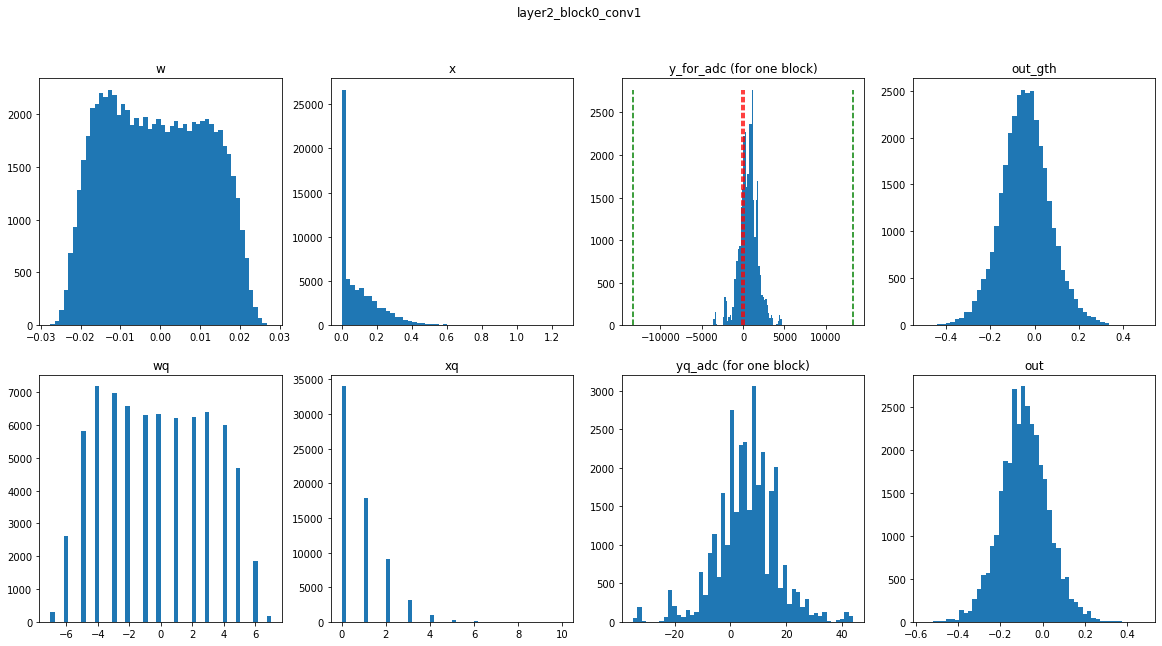

In [99]:
draw_layer_stats(stats_ptq, 'layer2_block0_conv1')

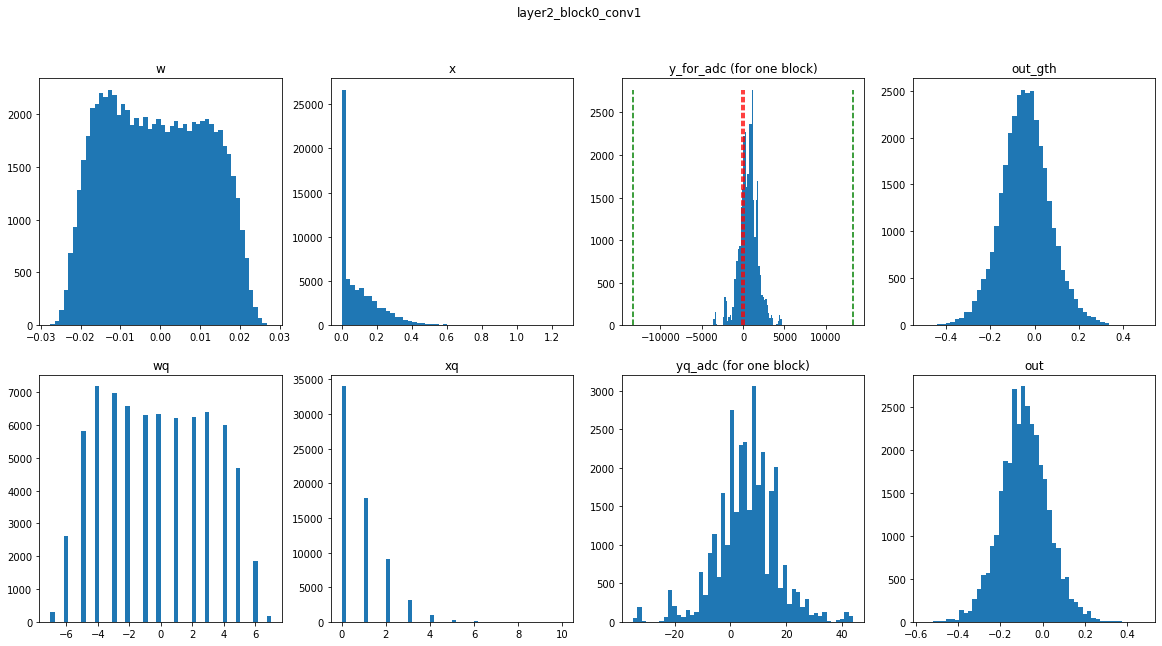

In [98]:
draw_layer_stats(stats_qat1, 'layer2_block0_conv1')

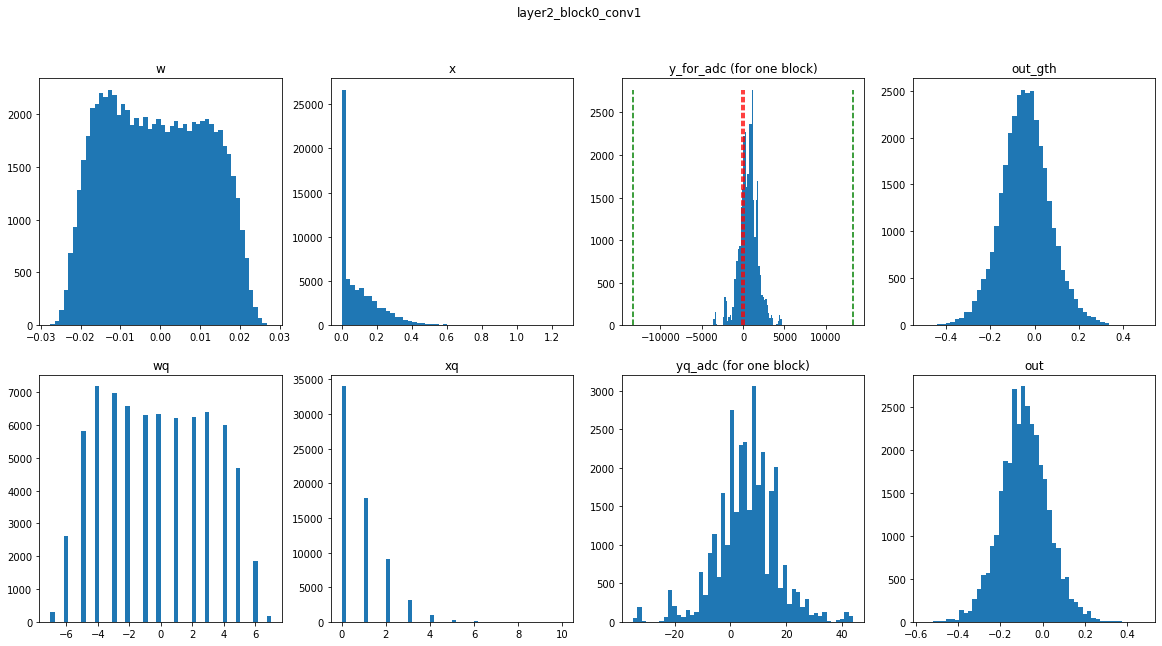

In [97]:
draw_layer_stats(stats_qat2, 'layer2_block0_conv1')

In [69]:
calibrate_model(model_adc, train_loader, device, 0.2)
evaluate_model(model_adc, test_loader)

Calibrating quantizers...


Calibrating:   0%|          | 0/39 [00:00<?, ?it/s]

Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.62it/s]


(92.55, 0.27468622121810915)

In [ ]:
model_adc.layer1[0].conv1.w_quantizer.observer.

HistogramObserver()

In [21]:
evaluate_model(model_adc, test_loader)
calibrate_model(model_adc, train_loader, device, 0.2)
evaluate_model(model_adc, test_loader)

Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.58it/s]


Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.61it/s]


(44.44, 1.6580899894714356)

In [22]:
stats = get_stats(model_adc)

In [23]:
logger = LayerwiseStatsLogger()

logger.enabled = False

model_adc_gth = resnet18_cifar_adc(10, 4, 4, 8, 4, ashift=False, logger=logger, conv_type=BlockedConv2dADC)
model_adc_gth.load_state_dict(torch.load('resnet18-wreshape-5e-4-st.pth'), strict=False)
model_adc_gth = model_adc_gth.to(device)
calibrate_model(model_adc_gth, train_loader, device, 0.2)
evaluate_model(model_adc_gth, test_loader)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:08<00:00,  4.61it/s]


(92.41, 0.2753527181386948)

In [24]:
stats_gth = get_stats(model_adc_gth)

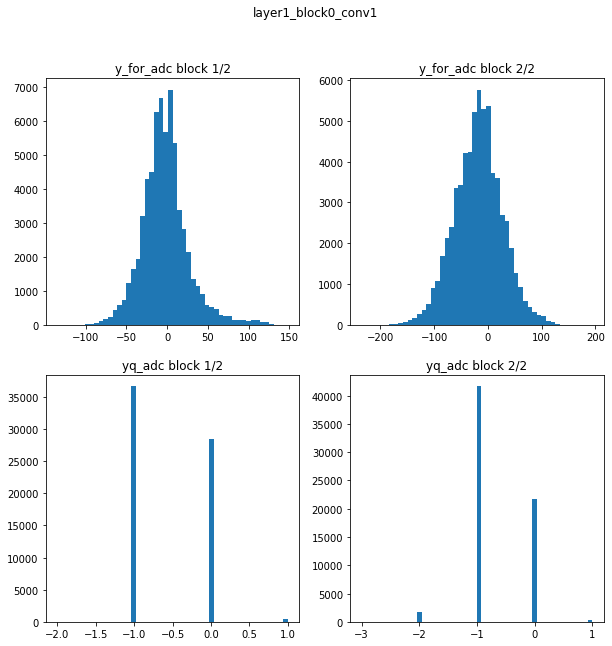

In [30]:
draw_layer_stats_y(stats, 'layer1_block0_conv1')

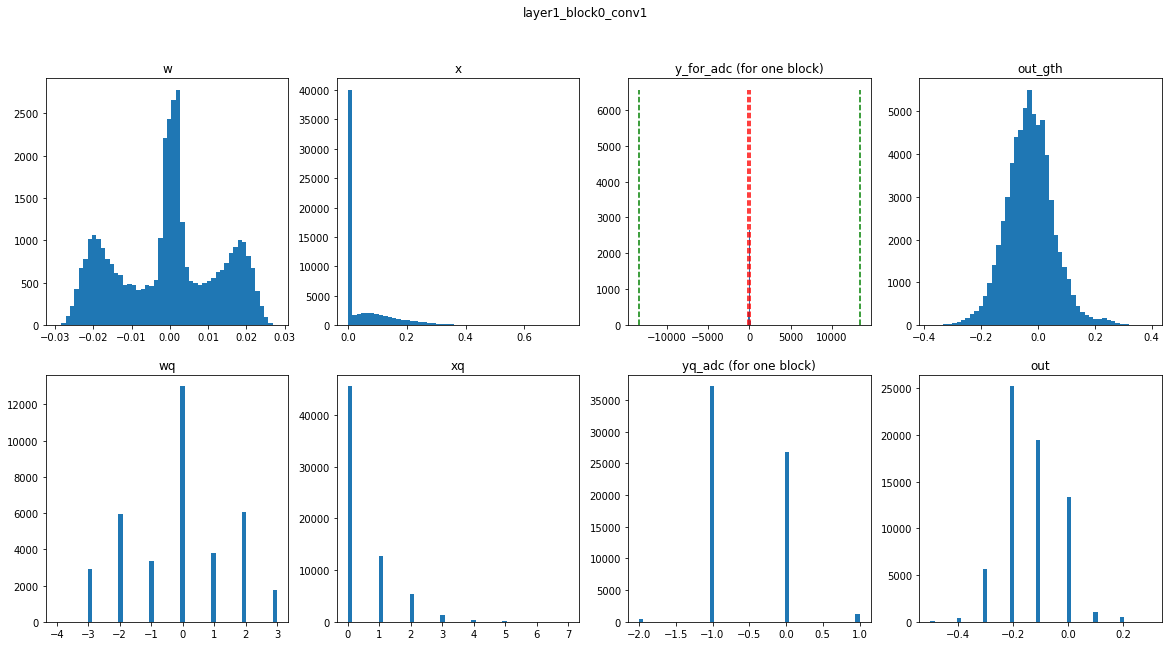

In [25]:
draw_layer_stats(stats, 'layer1_block0_conv1')

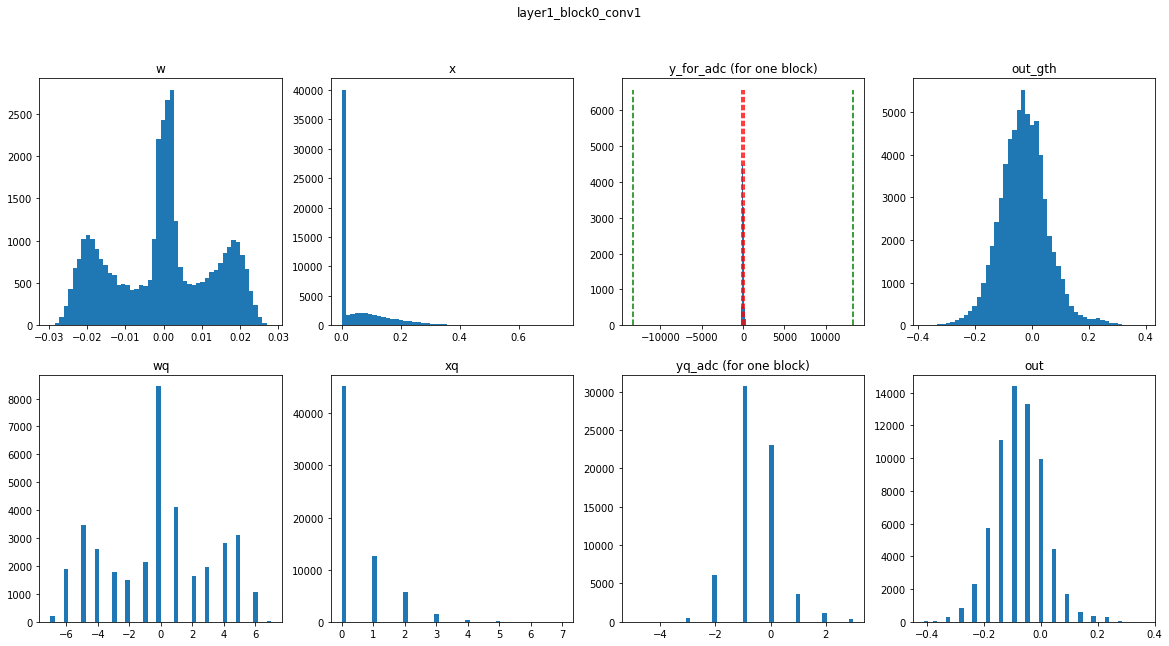

In [26]:
draw_layer_stats(stats_gth, 'layer1_block0_conv1')

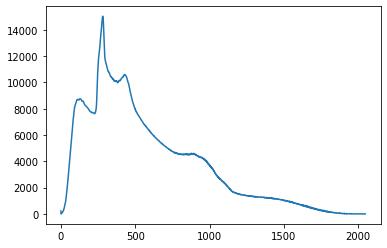

In [53]:
plt.plot(model_adc.layer1[0].conv1.w_quantizer.observer.histogram.cpu().numpy())

(array([2.000e+00, 4.000e+00, 1.200e+01, 1.900e+01, 4.200e+01, 6.100e+01,
        8.300e+01, 1.480e+02, 1.950e+02, 2.280e+02, 3.070e+02, 3.650e+02,
        3.430e+02, 4.420e+02, 4.730e+02, 5.460e+02, 5.020e+02, 5.610e+02,
        5.290e+02, 4.920e+02, 4.580e+02, 4.480e+02, 4.160e+02, 3.630e+02,
        3.570e+02, 3.610e+02, 3.200e+02, 2.960e+02, 3.020e+02, 2.960e+02,
        2.410e+02, 2.370e+02, 2.510e+02, 2.400e+02, 2.300e+02, 2.500e+02,
        2.120e+02, 2.060e+02, 2.200e+02, 2.090e+02, 2.230e+02, 2.550e+02,
        2.260e+02, 2.400e+02, 2.530e+02, 2.780e+02, 3.300e+02, 6.910e+02,
        1.043e+03, 1.160e+03, 1.169e+03, 1.257e+03, 1.288e+03, 1.373e+03,
        1.433e+03, 1.344e+03, 8.240e+02, 4.060e+02, 3.690e+02, 3.200e+02,
        2.790e+02, 2.430e+02, 2.410e+02, 2.500e+02, 2.460e+02, 2.270e+02,
        2.570e+02, 2.380e+02, 2.740e+02, 2.440e+02, 2.710e+02, 2.810e+02,
        3.080e+02, 3.240e+02, 3.070e+02, 3.450e+02, 3.700e+02, 3.690e+02,
        4.220e+02, 4.300e+02, 4.580e+0

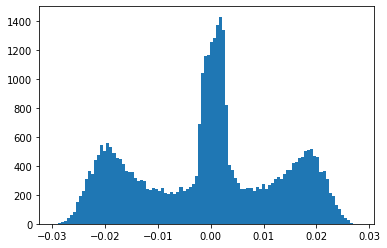

In [61]:
plt.hist(model_adc.layer1[0].conv1.weight.detach().cpu().numpy().flatten(), bins=100)

In [56]:
model_adc_gth.layer1[0].conv1.w_quantizer.observer.min_val, model_adc_gth.layer1[0].conv1.w_quantizer.observer.max_val

(tensor(-0.0295, device='cuda:0'), tensor(0.0281, device='cuda:0'))

In [57]:
model_adc.layer1[0].conv1.w_quantizer.observer.min_val, model_adc.layer1[0].conv1.w_quantizer.observer.max_val

(tensor(-0.0295, device='cuda:0'), tensor(0.2006, device='cuda:0'))

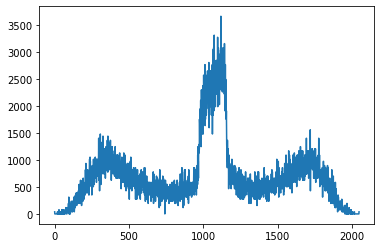

In [54]:
plt.plot(model_adc_gth.layer1[0].conv1.w_quantizer.observer.histogram.cpu().numpy())

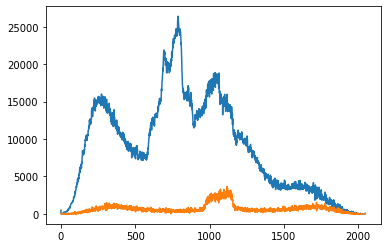

In [40]:
plt.plot(model_adc.layer1[0].conv1.w_quantizer.observer.histogram.cpu().numpy())
plt.plot(model_adc_gth.layer1[0].conv1.w_quantizer.observer.histogram.cpu().numpy())

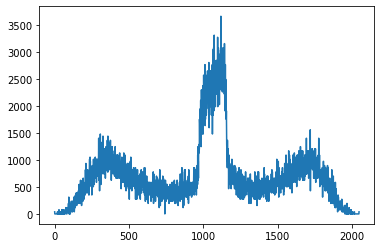

In [41]:
plt.plot(model_adc_gth.layer1[0].conv1.w_quantizer.observer.histogram.cpu().numpy())

In [43]:
model_adc.layer1[0].conv1.w_quantizer.enabled

False

In [32]:
model_adc.layer1[0].conv1.w_quantizer.scale, model_adc.layer1[0].conv1.w_quantizer.zero_point

(tensor([0.0083], device='cuda:0'),
 tensor([0], device='cuda:0', dtype=torch.int32))

In [33]:
model_adc_gth.layer1[0].conv1.w_quantizer.scale, model_adc_gth.layer1[0].conv1.w_quantizer.zero_point

(tensor([0.0039], device='cuda:0'),
 tensor([0], device='cuda:0', dtype=torch.int32))

In [ ]:
distr1 = model_adc.layer1[0].conv1.weight.

# Experiments 17.09

In [ ]:
model_qat = resnet18_cifar_adc(10, 4, 4, 8, 4, False, None, Conv2dADC)
model_qat.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'), strict=False)
model_qat = model_qat.to(device)
model_qat.disable_adc()
calibrate_model(model_qat, test_loader, device)
evaluate_model(model_qat, test_loader)

Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:01<00:00, 24.16it/s]


(92.93, 0.2542257201194763)

In [ ]:
model_adc0 = resnet18_cifar_adc(10, 4, 4, 8, 4, False, None, Conv2dADC)
model_adc0.load_state_dict(torch.load('/home/coder/project/resnet18-baseline.pth'), strict=False)
model_adc0 = model_adc0.to(device)
model_adc0.enable_adc()
calibrate_model(model_adc0, train_loader, device)
evaluate_model(model_adc0, test_loader)

enable adc
Calibrating quantizers...
Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:06<00:00,  6.13it/s]


(12.67, 2.508772074508667)

In [ ]:
from torch import nn
def load_tiled_model_weights(custom_model, pretrained_model):
    """
    Loads weights from a pretrained model with nn.Conv2d layers into
    a custom model with TiledConv2dADC layers.
    """
    pretrained_modules = dict(pretrained_model.named_modules())
    custom_modules = dict(custom_model.named_modules())

    for name, custom_module in custom_modules.items():
        if name in pretrained_modules:
            pretrained_module = pretrained_modules[name]

            # Case 1: Custom has TiledConv2dADC and pretrained has Conv2d
            if isinstance(custom_module, TiledConv2dADC) and isinstance(pretrained_module, nn.Conv2d):
                #print(f"[TILED] Loading Conv2d → TiledConv2dADC for layer: {name}")
                custom_module.load_weights(pretrained_module)

            # Case 2: They are of the same type → copy state_dict directly
            elif type(custom_module) == type(pretrained_module) or isinstance(custom_module, Conv2dADC) or isinstance(custom_module, LinearADC):
                try:
                    custom_module.load_state_dict(pretrained_module.state_dict(), strict=False)
                    #print(f"[DEFAULT] Loaded state_dict for: {name}")
                except RuntimeError as e:
                    print(f"[WARNING] Skipped {name} due to mismatch: {e}")

In [ ]:
model_adc1 = resnet18_cifar_adc(10, 4, 4, 8, 4, False, None, TiledConv2dADC)



In [ ]:
from ADC.logger import LayerwiseStatsLogger

model_adc2 = resnet18_cifar_adc(10, 4, 4, 8, 4, True, None, TiledConv2dADC)
load_tiled_model_weights(model_adc2, model)
model_adc2 = model_adc2.to(device)
model_adc2.enable_adc()
calibrate_model(model_adc2, train_loader, device, 0.1)
evaluate_model(model_adc2, test_loader)

[TILED] Loading Conv2d → TiledConv2dADC for layer: conv1
[DEFAULT] Loaded state_dict for: bn1
[DEFAULT] Loaded state_dict for: relu
[DEFAULT] Loaded state_dict for: layer1
[TILED] Loading Conv2d → TiledConv2dADC for layer: layer1.0.conv1
[DEFAULT] Loaded state_dict for: layer1.0.bn1
[TILED] Loading Conv2d → TiledConv2dADC for layer: layer1.0.conv2
[DEFAULT] Loaded state_dict for: layer1.0.bn2
[DEFAULT] Loaded state_dict for: layer1.0.relu
[TILED] Loading Conv2d → TiledConv2dADC for layer: layer1.1.conv1
[DEFAULT] Loaded state_dict for: layer1.1.bn1
[TILED] Loading Conv2d → TiledConv2dADC for layer: layer1.1.conv2
[DEFAULT] Loaded state_dict for: layer1.1.bn2
[DEFAULT] Loaded state_dict for: layer1.1.relu
[DEFAULT] Loaded state_dict for: layer2
[TILED] Loading Conv2d → TiledConv2dADC for layer: layer2.0.conv1
[DEFAULT] Loaded state_dict for: layer2.0.bn1
[TILED] Loading Conv2d → TiledConv2dADC for layer: layer2.0.conv2
[DEFAULT] Loaded state_dict for: layer2.0.bn2
[DEFAULT] Loaded state

Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:13<00:00,  2.94it/s]


(10.0, 2.448097971725464)

In [ ]:
from ADC.logger import LayerwiseStatsLogger
logger = LayerwiseStatsLogger()
logger.enabled = False
model_adc1 = resnet18_cifar_adc(10, 4, 4, 8, 4, False, logger, TiledConv2dADC)
load_tiled_model_weights(model_adc1, model)
model_adc1 = model_adc1.to(device)
model_adc1.enable_adc()
calibrate_model(model_adc1, train_loader, device, 0.1)
evaluate_model(model_adc1, test_loader)

enable adc
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:27<00:00,  1.45it/s]


(57.32, 1.4176880884170533)

In [ ]:
model_adc1.logger.enabled = True

In [ ]:
def get_stats(model):
    model.logger.enabled = True
    batch, labels = next(iter(test_loader))
    batch = batch.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        res = model(batch)
    return model.logger.get_stats()

In [ ]:
stats.keys()

NameError: name 'stats' is not defined

In [ ]:
def draw_layer_stats(stats, layer_name):
    fig, ax = plt.subplots(2, 4, figsize=(20, 10))
    
    data = stats[layer_name]

    names = [["w", "x", "y_for_adc", "out_gth"], ["wq", "xq", "yq_adc", "out"]]

    for i in range(2):
        for j in range(4):
            samples = data[names[i][j]][0]
            if names[i][j][0] != 'w':
                samples = samples[0]
            samples = samples.flatten()
            ax[i][j].hist(samples, bins=50)
            ax[i][j].set_title(names[i][j])
    fig.suptitle(layer_name)

In [ ]:
stats['layer1_block0_conv1_1/2']['x'][0][0].shape, stats['layer1_block0_conv1_1/2']['xq'][0][0].shape

(torch.Size([32, 32, 32]), torch.Size([32, 32, 32]))

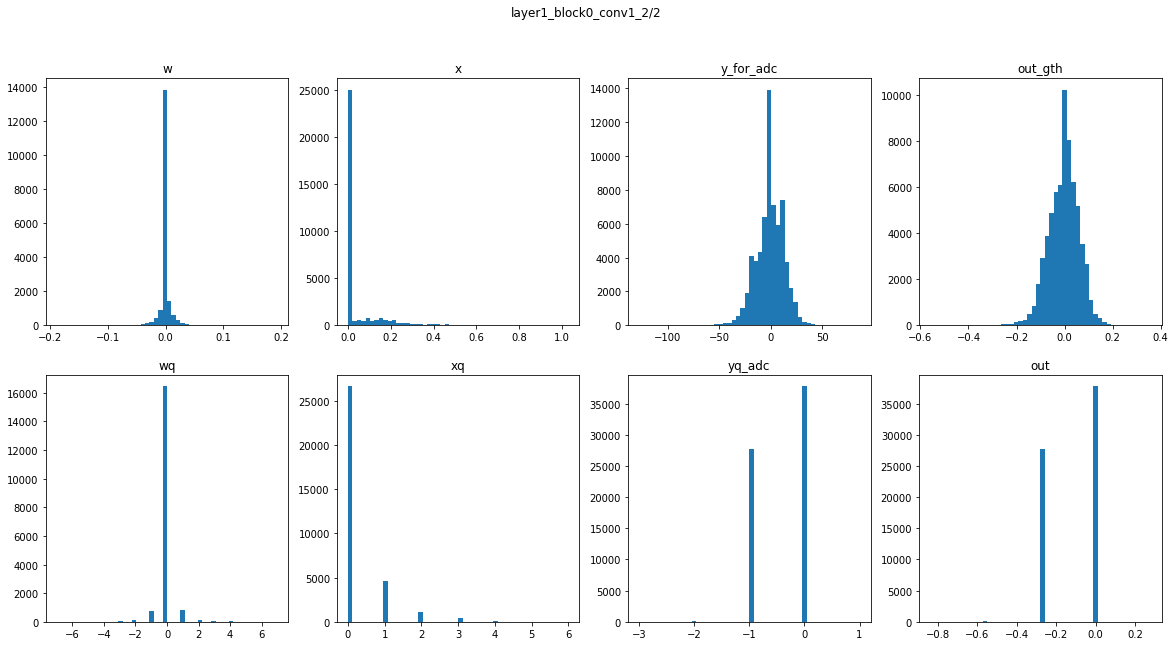

In [ ]:
draw_layer_stats(stats, 'layer1_block0_conv1_2/2')

In [ ]:
from ADC.logger import LayerwiseStatsLogger
logger = LayerwiseStatsLogger()
logger.enabled = False
model_adc2 = resnet18_cifar_adc(10, 4, 4, 8, 8, False, logger, TiledConv2dADC)
load_tiled_model_weights(model_adc2, model)
model_adc2 = model_adc2.to(device)
model_adc2.enable_adc()
calibrate_model(model_adc2, train_loader, device, 0.1)
evaluate_model(model_adc2, test_loader)

enable adc
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:17<00:00,  2.29it/s]


(78.83, 0.6964647256851196)

In [ ]:
stats = get_stats(model_adc2)

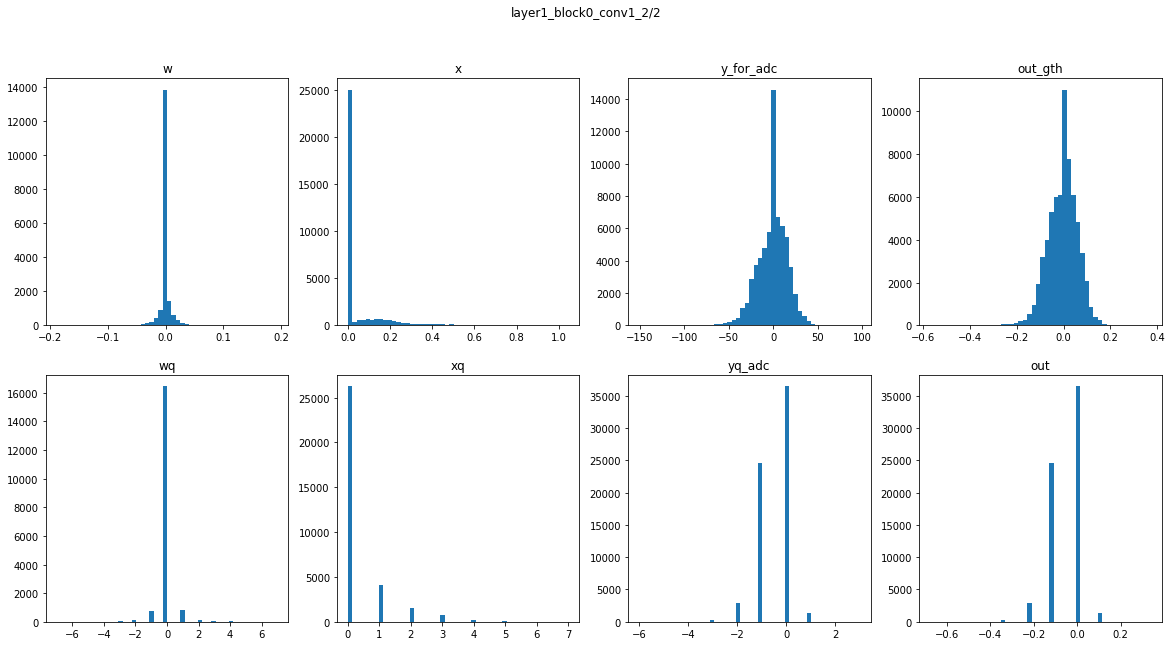

In [ ]:
draw_layer_stats(stats, 'layer1_block0_conv1_2/2')

In [ ]:
from ADC.logger import LayerwiseStatsLogger
logger3 = LayerwiseStatsLogger()
logger3.enabled = False
model_adc3 = resnet18_cifar_adc(10, 4, 4, 8, 16, False, logger3, TiledConv2dADC)
load_tiled_model_weights(model_adc3, model)
model_adc3 = model_adc3.to(device)
model_adc3.enable_adc()
calibrate_model(model_adc3, train_loader, device, 0.1)
evaluate_model(model_adc3, test_loader)

enable adc
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:17<00:00,  2.28it/s]


(90.12, 0.3448119439125061)

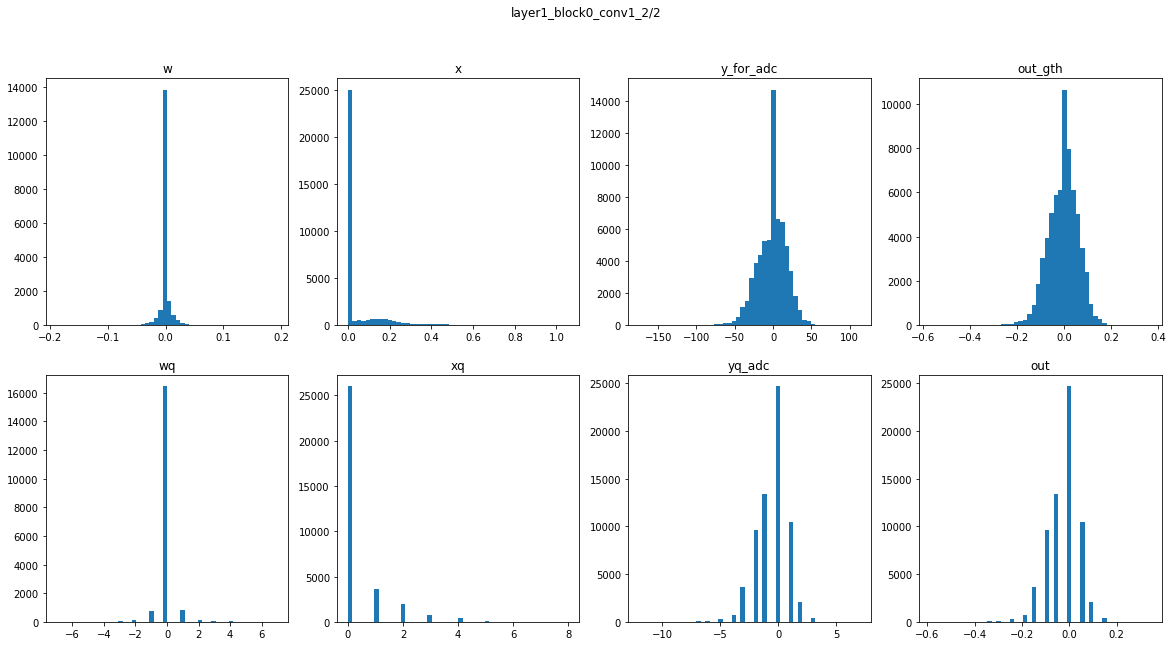

In [ ]:
stats3 = get_stats(model_adc3)
draw_layer_stats(stats3, 'layer1_block0_conv1_2/2')

In [ ]:
del stats3

In [ ]:
from ADC.logger import LayerwiseStatsLogger
logger3 = LayerwiseStatsLogger()
logger3.enabled = False
model_adc3 = resnet18_cifar_adc(10, 4, 4, 8, 16, True, logger3, TiledConv2dADC)
load_tiled_model_weights(model_adc3, model)
model_adc3 = model_adc3.to(device)
model_adc3.enable_adc()
calibrate_model(model_adc3, train_loader, device, 0.1)
evaluate_model(model_adc3, test_loader)

enable adc
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:30<00:00,  1.32it/s]


(85.66, 0.4717162773132324)

In [ ]:
from ADC.logger import LayerwiseStatsLogger
logger3 = LayerwiseStatsLogger()
logger3.enabled = False
model_adc3 = resnet18_cifar_adc(10, 4, 4, 8, 4, True, logger3, TiledConv2dADC)
load_tiled_model_weights(model_adc3, model)
model_adc3 = model_adc3.to(device)
model_adc3.enable_adc()
calibrate_model(model_adc3, train_loader, device, 0.1)
evaluate_model(model_adc3, test_loader)

enable adc
Calibrating quantizers...


Calibration done. Quantizer observers are now disabled.


Calculating accuracy: 100%|██████████| 40/40 [00:29<00:00,  1.33it/s]


(11.34, 2.3571521869659424)

In [ ]:
del stats4

In [ ]:
torch.ones((4, 2, 1)).unsqueeze(0).shape

torch.Size([1, 4, 2, 1])

In [ ]:
stats4 = get_stats(model_adc3)

In [ ]:
xc = torch.ones_like(stats4['layer1_block0_conv1_1/2']['x'][0])
wc = model_adc3.layer1[0].conv1.convs[0].weight.cpu()

wq = stats4['layer1_block0_conv1_1/2']['wq'][0]



In [ ]:
layer = model_adc3.layer1[0].conv1.convs[0]

In [ ]:
layer.padding

(1, 1)

In [ ]:
xshape = xc.shape
mask = torch.nn.functional.conv2d(torch.ones(xshape[1:]).unsqueeze(0).to(wq.device), 
                                               wq, 
                                               bias=None, 
                                               stride=layer.stride, 
                                               padding=layer.padding, 
                                               dilation=layer.dilation, 
                                               groups=layer.groups)

In [ ]:
out.shape

torch.Size([256, 64, 32, 32])

In [ ]:
mask.shape

torch.Size([1, 64, 32, 32])

(array([3.0000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        9.0000e+02, 0.0000e+00, 3.0000e+01, 1.8000e+03, 0.0000e+00,
        9.1000e+01, 1.5100e+02, 9.9400e+02, 0.0000e+00, 2.8820e+03,
        3.0060e+03, 0.0000e+00, 1.9620e+03, 3.2200e+03, 0.0000e+00,
        4.8440e+03, 1.2130e+03, 1.2160e+03, 0.0000e+00, 1.8689e+04,
        3.1350e+03, 0.0000e+00, 1.4000e+03, 5.8580e+03, 0.0000e+00,
        1.0980e+03, 2.0170e+03, 4.2500e+02, 0.0000e+00, 1.8640e+03,
        9.6200e+02, 0.0000e+00, 1.9820e+03, 1.0220e+03, 0.0000e+00,
        1.8610e+03, 9.6200e+02, 3.0000e+01, 0.0000e+00, 0.0000e+00,
        3.0000e+01, 0.0000e+00, 1.8310e+03, 0.0000e+00, 3.0000e+01]),
 array([-17. , -16.3, -15.6, -14.9, -14.2, -13.5, -12.8, -12.1, -11.4,
        -10.7, -10. ,  -9.3,  -8.6,  -7.9,  -7.2,  -6.5,  -5.8,  -5.1,
         -4.4,  -3.7,  -3. ,  -2.3,  -1.6,  -0.9,  -0.2,   0.5,   1.2,
          1.9,   2.6,   3.3,   4. ,   4.7,   5.4,   6.1,   6.8,   7.5,
          8.2,   8.9,   9.6,  10.3

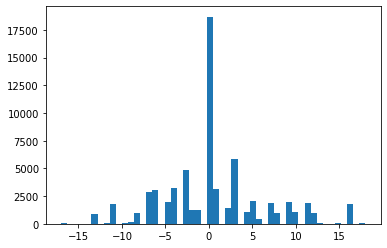

In [ ]:
plt.hist(mask.flatten(), bins=50)

(array([ 1.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  1.,  0.,  3.,  0.,  3.,
         2.,  0.,  3.,  0.,  5.,  1.,  0.,  1.,  0., 18.,  0.,  3.,  1.,
         0.,  6.,  0.,  1.,  0.,  2.,  0.,  0.,  2.,  0.,  1.,  2.,  0.,
         1.,  0.,  2.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  2.]),
 array([-13.  , -12.42, -11.84, -11.26, -10.68, -10.1 ,  -9.52,  -8.94,
         -8.36,  -7.78,  -7.2 ,  -6.62,  -6.04,  -5.46,  -4.88,  -4.3 ,
         -3.72,  -3.14,  -2.56,  -1.98,  -1.4 ,  -0.82,  -0.24,   0.34,
          0.92,   1.5 ,   2.08,   2.66,   3.24,   3.82,   4.4 ,   4.98,
          5.56,   6.14,   6.72,   7.3 ,   7.88,   8.46,   9.04,   9.62,
         10.2 ,  10.78,  11.36,  11.94,  12.52,  13.1 ,  13.68,  14.26,
         14.84,  15.42,  16.  ], dtype=float32),
 <BarContainer object of 50 artists>)

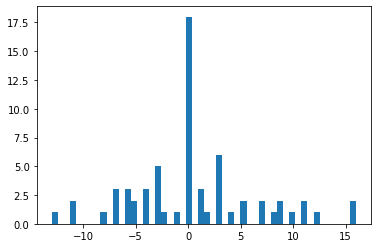

In [ ]:
plt.hist((wq.sum(axis=(1, 2, 3))), bins=50)

In [ ]:
(wq.sum(axis=(1, 2, 3)))[None, :, None, None]

tensor([[[[  0.]],

         [[ -5.]],

         [[-13.]],

         [[ 11.]],

         [[ -3.]],

         [[  3.]],

         [[  3.]],

         [[  1.]],

         [[  7.]],

         [[  0.]],

         [[  9.]],

         [[  0.]],

         [[ 16.]],

         [[  3.]],

         [[  3.]],

         [[ 10.]],

         [[  2.]],

         [[  4.]],

         [[  8.]],

         [[ -3.]],

         [[ 11.]],

         [[ -7.]],

         [[ -7.]],

         [[  3.]],

         [[  3.]],

         [[  7.]],

         [[  0.]],

         [[  1.]],

         [[  0.]],

         [[ -5.]],

         [[ -6.]],

         [[ -1.]],

         [[  0.]],

         [[ -3.]],

         [[  5.]],

         [[  0.]],

         [[ -7.]],

         [[ 12.]],

         [[  0.]],

         [[  0.]],

         [[ -4.]],

         [[  9.]],

         [[ -4.]],

         [[  0.]],

         [[ -4.]],

         [[  0.]],

         [[-11.]],

         [[ -8.]],

         [[  0.]],

         [[  0.]],



In [ ]:
out = stats4['layer1_block0_conv1_1/2']['out'][0]
out_gth = stats4['layer1_block0_conv1_1/2']['out_gth'][0]
diff = torch.linalg.norm(out - out_gth).cpu().item()
gth_norm = torch.linalg.norm(out_gth).cpu().item()
diff / gth_norm

1.0337689495381024

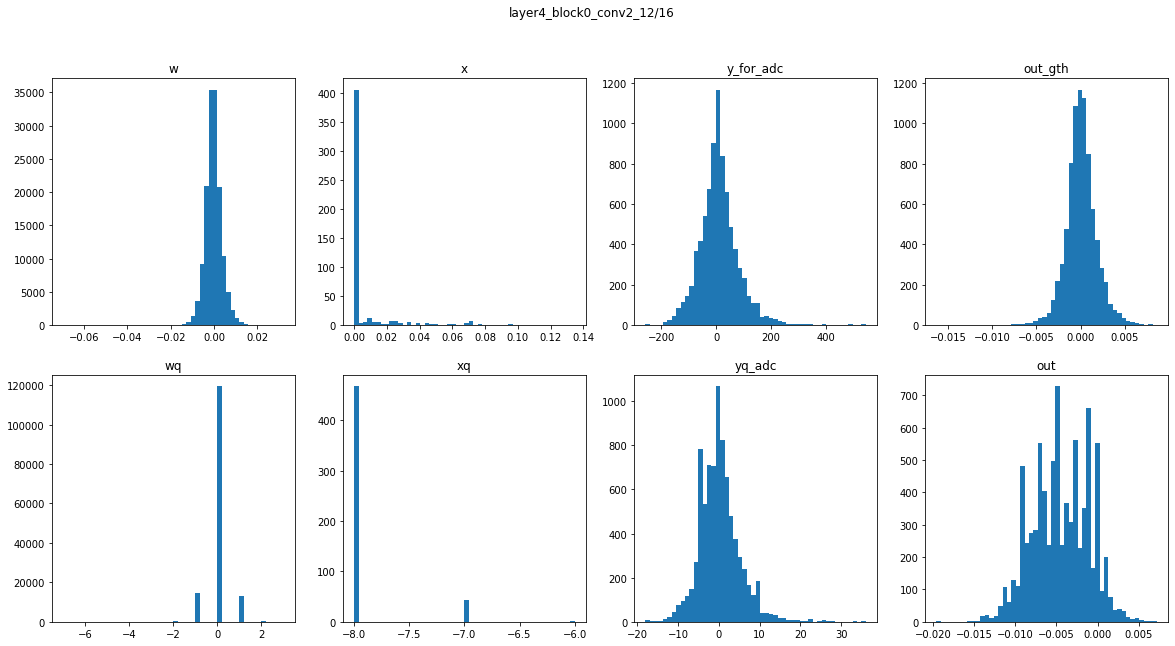

In [ ]:
draw_layer_stats(stats4, 'layer4_block0_conv2_12/16')

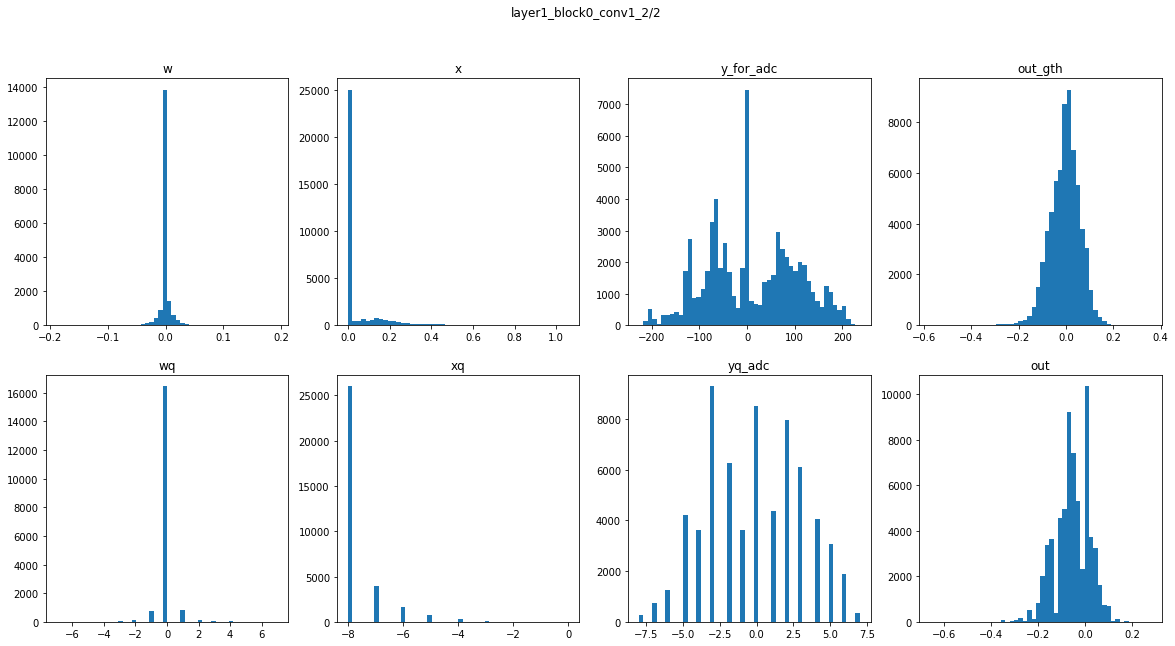

In [ ]:
draw_layer_stats(stats4, 'layer1_block0_conv1_2/2')

In [ ]:
stats4.keys()

dict_keys(['conv1_1/1', 'layer1_block0_conv1_1/2', 'layer1_block0_conv1_2/2', 'layer1_block0_conv2_1/2', 'layer1_block0_conv2_2/2', 'layer1_block1_conv1_1/2', 'layer1_block1_conv1_2/2', 'layer1_block1_conv2_1/2', 'layer1_block1_conv2_2/2', 'layer2_block0_conv1_1/2', 'layer2_block0_conv1_2/2', 'layer2_block0_conv2_1/4', 'layer2_block0_conv2_2/4', 'layer2_block0_conv2_3/4', 'layer2_block0_conv2_4/4', 'layer2_downsample_conv_1/1', 'layer2_block1_conv1_1/4', 'layer2_block1_conv1_2/4', 'layer2_block1_conv1_3/4', 'layer2_block1_conv1_4/4', 'layer2_block1_conv2_1/4', 'layer2_block1_conv2_2/4', 'layer2_block1_conv2_3/4', 'layer2_block1_conv2_4/4', 'layer3_block0_conv1_1/4', 'layer3_block0_conv1_2/4', 'layer3_block0_conv1_3/4', 'layer3_block0_conv1_4/4', 'layer3_block0_conv2_1/8', 'layer3_block0_conv2_2/8', 'layer3_block0_conv2_3/8', 'layer3_block0_conv2_4/8', 'layer3_block0_conv2_5/8', 'layer3_block0_conv2_6/8', 'layer3_block0_conv2_7/8', 'layer3_block0_conv2_8/8', 'layer3_downsample_conv_1/1'

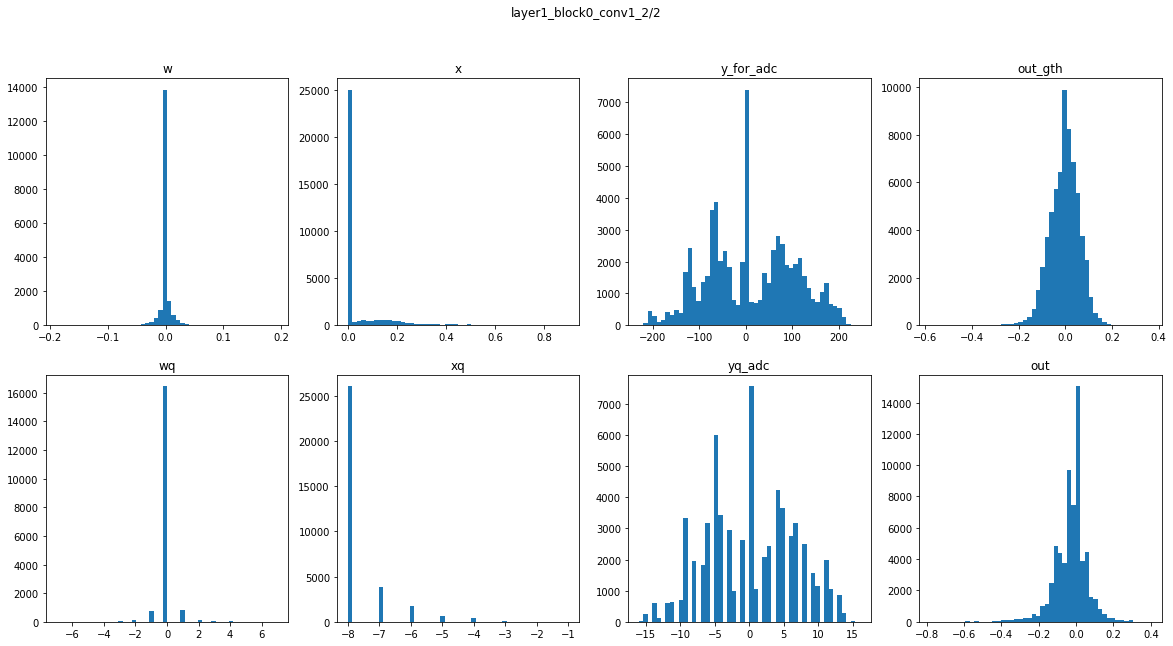

In [ ]:
draw_layer_stats(stats4, 'layer1_block0_conv1_2/2')

In [ ]:
abs(stats4['layer4_block0_conv2_12/16']['out'][0] - stats4['layer4_block0_conv2_12/16']['out_gth'][0]).mean()

tensor(0.0053)

In [ ]:
abs(stats4['layer4_block0_conv2_12/16']['out_gth'][0].flatten()).mean()

tensor(0.0011)

(array([1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 3.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 2.000e+00, 2.000e+00, 1.000e+00, 2.000e+00,
        7.000e+00, 0.000e+00, 6.000e+00, 8.000e+00, 5.000e+00, 1.000e+00,
        8.000e+00, 1.300e+01, 1.000e+01, 1.000e+01, 1.500e+01, 2.700e+01,
        3.600e+01, 8.100e+01, 1.060e+02, 1.450e+02, 1.880e+02, 3.070e+02,
        4.190e+02, 5.810e+02, 1.296e+03, 2.393e+03, 8.860e+02, 5.580e+02,
        3.430e+02, 2.690e+02, 1.810e+02, 1.220e+02, 7.200e+01, 3.200e+01,
        1.900e+01, 1.500e+01, 1.100e+01, 3.000e+00, 0.000e+00, 4.000e+00,
        0.000e+00, 1.000e+00]),
 array([-0.08102049, -0.07861945, -0.07621842, -0.07381738, -0.07141635,
        -0.06901531, -0.06661428, -0.06421324, -0.0618122 , -0.05941117,
        -0.05701013, -0.0546091 , -0.05220806, -0.04980703, -0.04740599,
        -0.04500496, -0.04260392, -0.04020288, -0.03780185, -0.03540081,
        -0.03299978, -0.03059874, -0.02819771, -0.02579667, -0.02339563,
        -0.

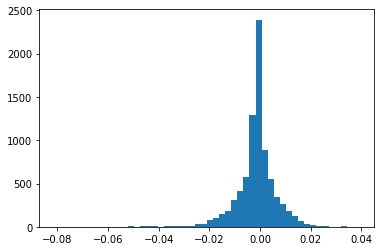

In [ ]:
plt.hist((stats4['layer4_block0_conv2_12/16']['out'][0] - stats4['layer4_block0_conv2_12/16']['out_gth'][0])[0].flatten(), bins=50)

In [ ]:
out = stats4['layer4_block0_conv2_12/16']['out'][0]
out_gth = stats4['layer4_block0_conv2_12/16']['out_gth'][0]
diff = torch.linalg.norm(out - out_gth).cpu().item()
gth_norm = torch.linalg.norm(out_gth).cpu().item()
diff / gth_norm

6.993059026911137

In [ ]:
res1 = torch.nn.functional.conv2d(xc, 
                                               wc, 
                                               bias=None, 
                                               stride=model_adc3.layer4[0].conv2.convs[11].stride, 
                                               padding=model_adc3.layer4[0].conv2.convs[11].padding, 
                                               dilation=model_adc3.layer4[0].conv2.convs[11].dilation, 
                                               groups=model_adc3.layer4[0].conv2.convs[11].groups)

In [ ]:
res1[0, 0, 0]

tensor([[ 0.0099, -0.0082, -0.0082, -0.0597],
        [-0.0167, -0.0573, -0.0573, -0.1085],
        [-0.0167, -0.0573, -0.0573, -0.1085],
        [-0.0315, -0.0630, -0.0630, -0.0853]], grad_fn=<SliceBackward0>)

In [ ]:
res2 = (wc.sum(axis=(1, 2, 3)))[None, :, None, None]

In [ ]:
res1.shape, res2.shape

(torch.Size([256, 512, 4, 4]), torch.Size([1, 512, 1, 1]))

In [ ]:
xc.shape

torch.Size([256, 32, 4, 4])

In [ ]:
model_adc3.layer4[0].conv2.convs[11].bias

In [ ]:
res2 = (wc.sum(axis=(1, 2, 3)))[None, :, None, None]

In [ ]:
xc = torch.ones_like(xc)

res1 = torch.nn.functional.conv2d(xc, 
                                               wc, 
                                               bias=None, 
                                               stride, 
                                               padding, 
                                               dilation, 
                                               groups)

In [ ]:
xc = torch.ones_like(xc)

res1 = torch.nn.functional.conv2d(xc, 
                                               wc, 
                                               bias=None, 
                                               stride=model_adc3.layer4[0].conv2.convs[11].stride, 
                                               padding=model_adc3.layer4[0].conv2.convs[11].padding, 
                                               dilation=model_adc3.layer4[0].conv2.convs[11].dilation, 
                                               groups=model_adc3.layer4[0].conv2.convs[11].groups)

In [ ]:
model_adc3.layer4[0].conv2.convs[11].groups

1

In [ ]:
model_adc3.device

AttributeError: 'ResNetCIFAR_ADC' object has no attribute 'device'

In [ ]:
wc.device

device(type='cpu')

In [ ]:
torch.ones_like()

tensor([[[[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]],

         [[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]],

         [[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]],

         ...,

         [[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]],

         [[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]],

         [[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]]],


        [[[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]],

         [[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]],

         [[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 

In [ ]:
xc.shape, wc.shape

(torch.Size([256, 32, 4, 4]), torch.Size([512, 32, 3, 3]))

In [ ]:
res1.shape, res2.shape

(torch.Size([256, 512, 4, 4]), torch.Size([1, 512, 1, 1]))

In [ ]:
res1[0, 0, :, 0]

tensor([ 0.0099, -0.0167, -0.0167, -0.0315], grad_fn=<SelectBackward0>)

In [ ]:
model_adc3.layer4[0].conv2.convs[11].weight

Parameter containing:
tensor([[[[-3.2885e-03, -2.0614e-03,  9.5128e-04],
          [-1.1949e-03,  3.0917e-04,  5.3733e-03],
          [-2.0203e-03,  1.1751e-03,  4.8793e-03]],

         [[-2.7079e-03, -1.6211e-03, -3.4707e-04],
          [ 1.1533e-03,  3.9365e-03,  5.6913e-03],
          [-2.5888e-03, -5.5292e-03,  1.5557e-03]],

         [[-3.8636e-03, -4.3526e-03,  3.0792e-03],
          [-3.7071e-03,  3.9351e-03,  1.1359e-02],
          [-3.5669e-03, -1.4943e-03,  1.8247e-03]],

         ...,

         [[ 4.9293e-03,  2.6004e-03,  3.1010e-03],
          [ 3.4306e-03,  4.4223e-03,  5.4837e-03],
          [-8.6099e-04, -4.1532e-03,  2.2523e-03]],

         [[ 1.0400e-03,  2.8157e-03,  4.9820e-03],
          [-3.0146e-03, -3.8337e-03, -1.0319e-03],
          [ 1.4510e-04, -3.3499e-03, -1.0073e-03]],

         [[-9.7044e-05, -2.7053e-03, -3.0516e-03],
          [-1.6620e-03, -7.3670e-04,  3.4900e-03],
          [-7.7204e-03,  5.1682e-05,  5.2861e-03]]],


        [[[-1.0908e-03, -2.1605

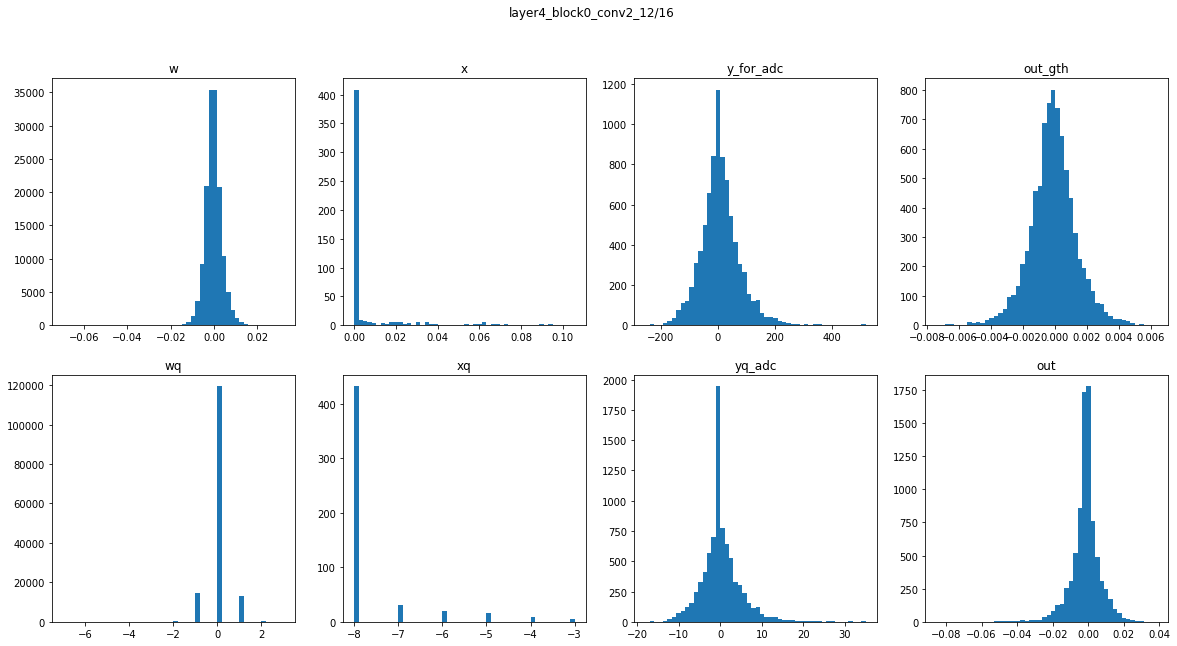

In [ ]:
draw_layer_stats(stats4, 'layer4_block0_conv2_12/16')

In [ ]:
model_adc1.logger.enabled = True


In [ ]:
stats['layer1_block0_conv1_1/2']['xq'][0].flatten().sample(10000)

AttributeError: 'Tensor' object has no attribute 'sample'

In [ ]:
stats['layer1_block0_conv1_1/2']['wq'][0].shape

torch.Size([64, 32, 3, 3])

In [ ]:
2 ** 4

16

In [ ]:
stats['layer1_block0_conv1_1/2']['wq'][0].min()

tensor(-7.)

In [ ]:
model_adc1.layer1[0].conv1.convs[0].weight.shape

torch.Size([64, 32, 3, 3])

In [ ]:
model_adc1.layer1[0].conv1.convs[0].weight.max()

tensor(0.2651, device='cuda:0', grad_fn=<MaxBackward1>)

In [ ]:
def draw_layer(data, gth_weights, ):
    fig, ax = plt.subplots((2, 2))
    ax[0][0].

(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 2.0000e+00, 7.0000e+00, 9.0000e+00,
        1.4000e+01, 1.9000e+01, 4.7000e+01, 8.3000e+01, 1.6400e+02,
        5.7800e+02, 2.2520e+03, 1.3898e+04, 8.9500e+02, 2.9400e+02,
        8.9000e+01, 3.2000e+01, 1.0000e+01, 1.3000e+01, 5.0000e+00,
        5.0000e+00, 2.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00,
        2.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-0.31377774, -0.3021994 , -0.290621  , -0.27904266, -0.26746428,
        -0.25588593, -0.24430755, -0.23272918, -0.22115082, -0.20957245,
        -0.19799408, -0.18641572, -0.17483735, -0.163259  , -0.15168063,
        -0.14010227, -0.1285239 , -0.11694553, -0.10536716, -0.0937888 ,
        -0.08221044, -0.07

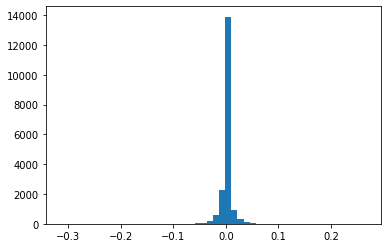

In [ ]:
plt.hist(model_adc1.layer1[0].conv1.convs[0].weight.flatten().cpu().detach(), bins=50)

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

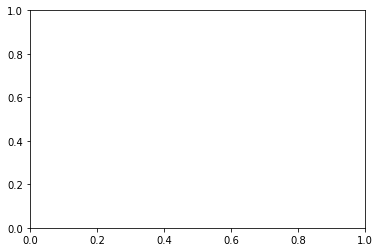

In [ ]:
plt.hist(model_adc1.layer1[0].conv1.convs[0].weight.flatten())
plt.hist(stats['layer1_block0_conv1_1/2']['wq'][0].flatten())

In [ ]:
stats['layer1_block0_conv1_1/2']['wq'][0].shape

torch.Size([64, 32, 3, 3])

(array([1.0000e+00, 1.0000e+00, 2.0000e+00, 4.6000e+01, 4.0900e+02,
        1.7471e+04, 4.9300e+02, 4.0000e+00, 3.0000e+00, 2.0000e+00]),
 array([-7. , -5.7, -4.4, -3.1, -1.8, -0.5,  0.8,  2.1,  3.4,  4.7,  6. ],
       dtype=float32),
 <BarContainer object of 10 artists>)

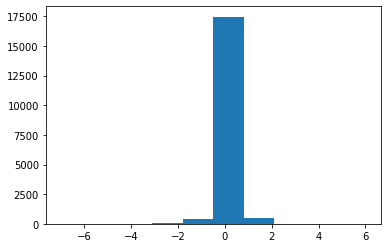

In [ ]:
plt.hist(stats['layer1_block0_conv1_1/2']['wq'][0].flatten())

In [ ]:
model_adc1.layer1[0].conv1.convs[0].adc_quantizer.delta

59.0625

(array([1.0000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 2.1183e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 4.4337e+04, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 6.0000e+00]),
 array([-0.6992622 , -0.67828435, -0.6573065 , -0.6363286 , -0.6153507 ,
        -0.59437287, -0.573395  , -0.55241716, -0.53143924, -0.5104614 ,
        -0.48948354, -0.46850568, -0.4475278 , -0.42654994, -0.4055721 ,
        -0.3845942 , -0.36361635, -0.3426385 , -0.3216606 , -0.30068275,
        -0.27970487, -0.25

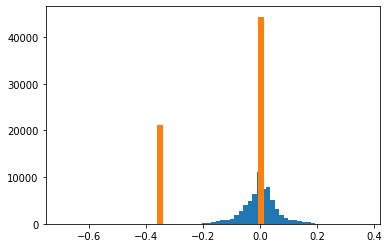

In [ ]:
plt.hist(stats['layer1_block0_conv1_1/2']['out_gth'][0][0].flatten(), bins=50)
plt.hist(stats['layer1_block0_conv1_1/2']['out'][0][0].flatten(), bins=50)

(array([1.1000e+01, 0.0000e+00, 0.0000e+00, 2.1176e+04, 0.0000e+00,
        0.0000e+00, 4.4344e+04, 0.0000e+00, 0.0000e+00, 5.0000e+00]),
 array([-2. , -1.7, -1.4, -1.1, -0.8, -0.5, -0.2,  0.1,  0.4,  0.7,  1. ],
       dtype=float32),
 <BarContainer object of 10 artists>)

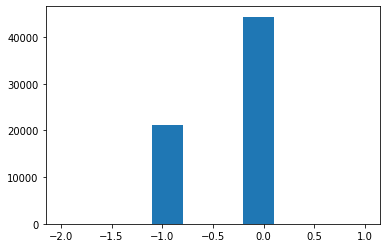

In [ ]:
plt.hist(stats['layer1_block0_conv1_1/2']['yq_adc'][0][0].flatten())

(array([2.5936e+04, 3.8920e+03, 1.3670e+03, 1.2870e+03, 0.0000e+00,
        1.2700e+02, 1.2700e+02, 2.8000e+01, 3.0000e+00, 1.0000e+00]),
 array([0. , 0.8, 1.6, 2.4, 3.2, 4. , 4.8, 5.6, 6.4, 7.2, 8. ],
       dtype=float32),
 <BarContainer object of 10 artists>)

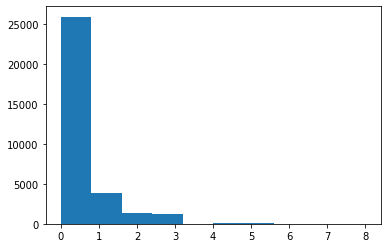

In [ ]:
plt.hist(stats['layer1_block0_conv1_1/2']['xq'][0][10].flatten())

KeyboardInterrupt: 

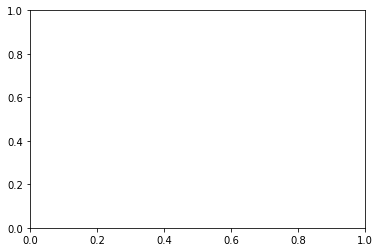

In [ ]:
plt.hist(stats['layer1_block0_conv1_1/2']['xq'][0].flatten())